# Análisis final

Definimos las rutas a los cuatro CSV de resultados.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path.cwd().parent 

SSGRADCAMPP_CSV = REPO_ROOT / "results" / "final" / "ssgradcampp" / "eval_metrics.csv"
DCRISP_CSV      = REPO_ROOT / "results" / "final" / "dcrisp" / "eval_metrics.csv"
TTA_CSV         = REPO_ROOT / "results" / "tta_uq" / "object_level.csv"
DIST_SIZE_CSV   = REPO_ROOT / "results" / "object_distance_size.csv"

def rel(path) -> str:
    """Renders a path relative to REPO_ROOT, POSIX-style, for printing in notebook
    output cells -- avoids leaking the local absolute filesystem path (which
    includes the OS username) into notebook outputs that get committed to GitHub."""
    return Path(path).relative_to(REPO_ROOT).as_posix()

Cargamos los cuatro CSV forzando `image_id` a tipo string (evita perder los ceros a la izquierda en los cuatro ficheros, no solo en uno) y verificamos que cada uno tiene las 8051 filas esperadas.

In [2]:
dtype_common = {"image_id": str}

df_ssgradcampp = pd.read_csv(SSGRADCAMPP_CSV, dtype=dtype_common)
df_dcrisp      = pd.read_csv(DCRISP_CSV, dtype=dtype_common)
df_tta         = pd.read_csv(TTA_CSV, dtype=dtype_common)
df_dist_size   = pd.read_csv(DIST_SIZE_CSV, dtype=dtype_common)

for name, df in [("ssgradcampp", df_ssgradcampp), ("dcrisp", df_dcrisp),
                  ("tta", df_tta), ("dist_size", df_dist_size)]:
    print(f"{name}: shape={df.shape}, image_id dtype={df['image_id'].dtype}, "
          f"sample id={df['image_id'].iloc[0]!r}")
    assert len(df) == 8051, f"{name}: expected 8051 rows, got {len(df)}"

ssgradcampp: shape=(8051, 31), image_id dtype=str, sample id='000013'
dcrisp: shape=(8051, 31), image_id dtype=str, sample id='000000'
tta: shape=(8051, 21), image_id dtype=str, sample id='000000'
dist_size: shape=(8051, 6), image_id dtype=str, sample id='000000'


Unificamos el nombre de la columna de objeto (`object_idx` → `obj_idx` en TTA) y comprobamos que la clave `(image_id, obj_idx)` es única dentro de cada fichero.

In [3]:
df_tta = df_tta.rename(columns={"object_idx": "obj_idx"})

for name, df in [("ssgradcampp", df_ssgradcampp), ("dcrisp", df_dcrisp),
                  ("tta", df_tta), ("dist_size", df_dist_size)]:
    key = df[["image_id", "obj_idx"]]
    n_dup = key.duplicated().sum()
    assert n_dup == 0, f"{name}: {n_dup} duplicated (image_id, obj_idx) keys"
    print(f"{name}: {df['image_id'].nunique()} unique images, {len(df)} unique (image_id, obj_idx) keys")

ssgradcampp: 1493 unique images, 8051 unique (image_id, obj_idx) keys
dcrisp: 1493 unique images, 8051 unique (image_id, obj_idx) keys
tta: 1493 unique images, 8051 unique (image_id, obj_idx) keys
dist_size: 1493 unique images, 8051 unique (image_id, obj_idx) keys


Antes de fusionar, verificamos que las columnas descriptivas compartidas (clase predicha, clase GT, IoU, corrección) coinciden fila a fila entre SSGrad-CAM++, D-CRISP y TTA, en vez de asumirlo.

In [4]:
shared_descriptive_cols = ["pred_class", "pred_class_name", "gt_class", "gt_class_name",
                            "gt_iou", "correctness"]

def compare_nan_safe(a: pd.Series, b: pd.Series, tol: float | None = None) -> int:
    """Returns the count of genuinely differing entries between two aligned Series,
    treating NaN==NaN as equal regardless of sign bit, and using a numeric tolerance
    when `tol` is given (for float columns like gt_iou)."""
    both_nan = a.isna() & b.isna()
    if tol is not None:
        close_enough = np.isclose(a.fillna(0), b.fillna(0), atol=tol, rtol=0)
        equal = both_nan | (close_enough & ~a.isna() & ~b.isna())
    else:
        equal = both_nan | (a == b)
    return int((~equal).sum())

base = df_ssgradcampp.set_index(["image_id", "obj_idx"])[shared_descriptive_cols]

for name, df in [("dcrisp", df_dcrisp), ("tta", df_tta)]:
    other = df.set_index(["image_id", "obj_idx"])[shared_descriptive_cols]
    aligned_base, aligned_other = base.align(other, join="inner")
    mismatches = {}
    for col in shared_descriptive_cols:
        tol = 1e-4 if col == "gt_iou" else None  # floating-point noise tolerance, see previous check
        n_mismatch = compare_nan_safe(aligned_base[col], aligned_other[col], tol=tol)
        if n_mismatch:
            mismatches[col] = n_mismatch
    print(f"ssgradcampp vs {name}: {len(aligned_base)} rows compared, mismatches={mismatches or 'none'}")

ssgradcampp vs dcrisp: 8051 rows compared, mismatches=none
ssgradcampp vs tta: 8051 rows compared, mismatches=none


Construimos el DataFrame maestro: prefijamos las métricas propias de cada método XAI para evitar colisión de nombres y fusionamos las cuatro fuentes por `(image_id, obj_idx)`.

In [5]:
metric_cols = [
    "pointing_game", "ebpg", "relevance_rank_accuracy", "sparseness",
    "in_faithfulness_sample", "deletion_auc", "insertion_auc", "minimal_subset",
    "min_subset_k_pixels_exact", "rank_accuracy_at_min_subset", "rank_accuracy_precision",
    "outside_box_deletion_auc", "outside_box_confidence_drop", "in_stability_sample",
    "stability_n_valid", "stability_n_rejected_gate", "stability_n_rejected_explain",
    "stability_max_sensitivity", "stability_ris", "stability_ros", "stability_rrs",
    "stability_n_valid_rrs", "stability_n_rejected_representation",
]
key_cols = ["image_id", "obj_idx"]

ssgradcampp_part = df_ssgradcampp[key_cols + shared_descriptive_cols + metric_cols].rename(
    columns={c: f"ssgradcampp_{c}" for c in metric_cols}
)
dcrisp_part = df_dcrisp[key_cols + metric_cols].rename(
    columns={c: f"dcrisp_{c}" for c in metric_cols}
)
tta_part = df_tta.drop(columns=shared_descriptive_cols)  # keep box coords + uncertainty, drop duplicates
dist_size_part = df_dist_size  # no name collisions, used as-is

master = ssgradcampp_part.merge(dcrisp_part, on=key_cols, how="inner", validate="one_to_one")
master = master.merge(tta_part, on=key_cols, how="inner", validate="one_to_one")
master = master.merge(dist_size_part, on=key_cols, how="inner", validate="one_to_one")

print(master.shape)

(8051, 71)


Verificamos de forma dura que el cruce no ha perdido ni duplicado filas y que no se han introducido nulos inesperados.

In [6]:
assert len(master) == 8051, f"Expected 8051 rows after merge, got {len(master)}"
assert master["image_id"].nunique() == 1493, f"Expected 1493 unique images, got {master['image_id'].nunique()}"
assert master[key_cols].duplicated().sum() == 0, "Duplicated (image_id, obj_idx) after merge"

unexpected_nulls = master[["ssgradcampp_pointing_game", "dcrisp_pointing_game",
                            "pixel_Ue_mean", "size_classify"]].isnull().sum()
print("Null check (should all be 0):")
print(unexpected_nulls)
assert unexpected_nulls.sum() == 0

print(f"Master dataframe OK: {master.shape[0]} rows, {master.shape[1]} columns, "
      f"{master['image_id'].nunique()} unique images.")

Null check (should all be 0):
ssgradcampp_pointing_game    0
dcrisp_pointing_game         0
pixel_Ue_mean                0
size_classify                0
dtype: int64
Master dataframe OK: 8051 rows, 71 columns, 1493 unique images.


Guardamos el DataFrame maestro en CSV, base para todo el análisis estratificado de los pasos siguientes.

In [7]:
OUT_PATH = REPO_ROOT / "results" / "final" / "master_dataset.csv"
master.to_csv(OUT_PATH, index=False)
print(f"Saved -> {rel(OUT_PATH)}")
print(master.columns.tolist())

Saved -> results/final/master_dataset.csv
['image_id', 'obj_idx', 'pred_class', 'pred_class_name', 'gt_class', 'gt_class_name', 'gt_iou', 'correctness', 'ssgradcampp_pointing_game', 'ssgradcampp_ebpg', 'ssgradcampp_relevance_rank_accuracy', 'ssgradcampp_sparseness', 'ssgradcampp_in_faithfulness_sample', 'ssgradcampp_deletion_auc', 'ssgradcampp_insertion_auc', 'ssgradcampp_minimal_subset', 'ssgradcampp_min_subset_k_pixels_exact', 'ssgradcampp_rank_accuracy_at_min_subset', 'ssgradcampp_rank_accuracy_precision', 'ssgradcampp_outside_box_deletion_auc', 'ssgradcampp_outside_box_confidence_drop', 'ssgradcampp_in_stability_sample', 'ssgradcampp_stability_n_valid', 'ssgradcampp_stability_n_rejected_gate', 'ssgradcampp_stability_n_rejected_explain', 'ssgradcampp_stability_max_sensitivity', 'ssgradcampp_stability_ris', 'ssgradcampp_stability_ros', 'ssgradcampp_stability_rrs', 'ssgradcampp_stability_n_valid_rrs', 'ssgradcampp_stability_n_rejected_representation', 'dcrisp_pointing_game', 'dcrisp_e

Reutilizamos `classify_with_kmeans` de `scripts/classify_distance_size.py` (mismo criterio K-Means k=3 ya usado para distancia y tamaño) para agrupar `pixel_Ue_mean` en tres niveles de incertidumbre epistémica.

In [8]:
import sys
sys.path.insert(0, str(REPO_ROOT / "scripts"))
from classify_distance_size import classify_with_kmeans

master["uncertainty_classify"] = classify_with_kmeans(master["pixel_Ue_mean"], ["low", "medium", "high"])

assert master["uncertainty_classify"].isna().sum() == 0, "pixel_Ue_mean has no nulls -- every row should get a group"
print(master["uncertainty_classify"].value_counts())

uncertainty_classify
high      3198
low       2902
medium    1951
Name: count, dtype: int64


Antes de dar la agrupación por buena, comparamos media, mediana, desviación típica y rango de `pixel_Ue_mean` dentro de cada grupo frente a la dispersión global, para valorar si los tres grupos están realmente separados o si la división aporta poco.

In [9]:
uncertainty_summary = master.groupby("uncertainty_classify")["pixel_Ue_mean"].agg(
    n="count", mean="mean", median="median", std="std", min="min", max="max"
).reindex(["low", "medium", "high"])

print(uncertainty_summary)
print(f"\nOverall pixel_Ue_mean std (for comparison): {master['pixel_Ue_mean'].std():.4f}")

                         n      mean    median       std           min  \
uncertainty_classify                                                     
low                   2902  0.070378  0.072625  0.051812  1.387779e-17   
medium                1951  0.363952  0.367046  0.059358  2.315406e-01   
high                  3198  0.583028  0.576562  0.079837  4.734884e-01   

                           max  
uncertainty_classify            
low                   0.213761  
medium                0.473210  
high                  1.106833  

Overall pixel_Ue_mean std (for comparison): 0.2327


La agrupación por K-Means sí está justificada: la desviación típica dentro de cada grupo (0.052 / 0.059 / 0.080) es entre 3 y 4,5 veces menor que la desviación típica global (0.2327), y las medias quedan claramente separadas y ordenadas (0.070 → 0.364 → 0.583), con huecos entre grupos (~0.29 y ~0.22) muy superiores a su dispersión interna. Los tres grupos no se solapan y tienen tamaños amplios y comparables (2902 / 1951 / 3198), sin ningún grupo residual casi vacío. La diferenciación en tres niveles de incertidumbre epistémica no es arbitraria: captura una separación real de la variable, no ruido.

Repetimos la misma comprobación de homogeneidad/separación para `dist_classify` y `size_classify` (ya calculados con K-Means en `object_distance_size.csv`, mismo criterio que la incertidumbre) frente a sus variables continuas subyacentes (`distance_m`, `size_bin`). Para la distancia, informamos también de los objetos sin dato ("sin dato"), sin descartarlos en silencio.

In [10]:
for col_classify, col_value, order in [
    ("dist_classify", "distance_m", ["near", "medium", "far"]),
    ("size_classify", "size_bin", ["small", "medium", "large"]),
]:
    n_missing = master[col_value].isna().sum()
    summary = master.groupby(col_classify)[col_value].agg(
        n="count", mean="mean", median="median", std="std", min="min", max="max"
    ).reindex(order)

    print(f"=== {col_classify} (based on {col_value}) ===")
    print(summary)
    print(f"Overall {col_value} std (for comparison): {master[col_value].std():.4f}")
    print(f"Rows with no {col_value} ('sin dato', unclassified): {n_missing}")
    print()

=== dist_classify (based on distance_m) ===
                  n       mean  median        std    min     max
dist_classify                                                   
near           3302  12.846517  12.895   5.428399  -0.16   22.20
medium         2567  31.590534  30.860   6.160449  22.21   43.97
far            1144  56.457273  53.185  11.188564  44.01  140.09
Overall distance_m std (for comparison): 17.0807
Rows with no distance_m ('sin dato', unclassified): 1038

=== size_classify (based on size_bin) ===
                  n          mean        median           std           min  \
size_classify                                                                 
small          6742   4367.588008   2587.287945   4382.963930    123.665676   
medium          965  33667.632434  31593.717629  10606.878739  19101.417532   
large           344  79168.052878  70294.376116  25936.535710  56613.629641   

                         max  
size_classify                 
small           19000.60

**Distancia**: la separación está justificada, medias muy distanciadas (12.85 → 31.59 → 56.46 m, huecos de ~18.7 y ~24.9 m) y desviaciones internas (5.43 / 6.16 / 11.19) claramente por debajo de la global (17.08). El grupo `far` es el más disperso de los tres (cola hasta 140 m), coherente con que la incertidumbre de distancia monocular crece con la propia distancia. Nota aparte: el mínimo de `near` es -0.16 m, físicamente imposible; es ruido de anotación de KITTI cerca de la cámara, no afecta a esta conclusión.

**Tamaño**: más matizado. Las medias también están muy separadas (4367.6 → 33667.6 → 79168.1 px², huecos muy superiores a cualquier desviación interna), pero el grupo `large` tiene una desviación típica (25936.5) que **supera** a la desviación global (18847.5) — es un grupo heterogéneo, no compacto, esperable porque el área de una caja crece cuadráticamente con el tamaño del objeto. La discretización en tres niveles sigue aportando valor para comparar medias entre grupos, pero hay que declarar explícitamente que `large` no es internamente homogéneo, a diferencia de `small`/`medium` y de los tres niveles de distancia/incertidumbre.

Configuración: familias de métricas, criterios de desglose, y una tabla explícita de dirección por métrica (mayor-es-mejor / menor-es-mejor / ambigua-no-se-resalta).

In [11]:
METHOD_PREFIXES = {"SSGrad-CAM++": "ssgradcampp", "D-CRISP": "dcrisp"}
METHODS_WITH_BASELINE = {**METHOD_PREFIXES, "Baseline (noise)": "baseline"}
N_SAMPLES = {"ssgradcampp": 20, "dcrisp": 5}

FAMILIES = {
    "Localization": ["pointing_game", "ebpg", "relevance_rank_accuracy",
                      "rank_accuracy_at_min_subset", "rank_accuracy_precision"],
    "Fidelity": ["deletion_auc", "insertion_auc", "minimal_subset", "min_subset_k_pixels_exact",
                 "outside_box_deletion_auc", "outside_box_confidence_drop"],
    "Complexity": ["sparseness"],
    "Robustness": ["stability_max_sensitivity", "stability_ris", "stability_ros", "stability_rrs"],
}
COVERAGE_METRICS = ["stability_n_valid", "stability_n_rejected_gate", "stability_n_rejected_explain"]

BREAKDOWNS = {
    "Global": (None, None),
    "Size": ("size_classify", ["small", "medium", "large"]),
    "Distance": ("dist_classify_display", ["near", "medium", "far", "missing (false_positive)", "missing (other)"]),
    "Correctness": ("correctness", ["correct", "false_positive", "wrong_class"]),
    "Uncertainty": ("uncertainty_classify", ["low", "medium", "high"]),
    "Class": ("pred_class_name", None),
}

BASELINE_STABILITY_MAP = {
    "ssgradcampp": {"stability_max_sensitivity": "stability_max_sensitivity",
                    "stability_ris": "stability_ris", "stability_ros": "stability_ros",
                    "stability_rrs": "stability_rrs"},
    "dcrisp": {"stability_max_sensitivity": "stability_max_sensitivity_n5",
               "stability_ris": "stability_ris_n5", "stability_ros": "stability_ros_n5",
               "stability_rrs": None},  
}
BASELINE_COVERAGE_MAP = {
    "ssgradcampp": {"stability_n_valid": "stability_n_valid",
                    "stability_n_rejected_gate": "stability_n_rejected_gate",
                    "stability_n_rejected_explain": "stability_n_rejected_explain"},
    "dcrisp": {"stability_n_valid": "stability_n_valid_n5",
               "stability_n_rejected_gate": "stability_n_rejected_gate_n5",
               "stability_n_rejected_explain": None},  
}

# True = higher is better, False = lower is better, None = ambiguous, not auto-highlighted.
METRIC_DIRECTION = {
    "pointing_game": True, "ebpg": True, "relevance_rank_accuracy": True,
    "rank_accuracy_at_min_subset": True, 
    "rank_accuracy_precision": True,
    "sparseness": True,
    "deletion_auc": False,   # faster confidence drop when removing important pixels = better
    "insertion_auc": True,   # faster confidence rise when re-inserting important pixels = better
    "minimal_subset": False, "min_subset_k_pixels_exact": False,
    "outside_box_deletion_auc": None,     # only meaningful relative to deletion_auc
    "outside_box_confidence_drop": None,  # identical between methods by construction
    "stability_max_sensitivity": False, "stability_ris": False,
    "stability_ros": False, "stability_rrs": False,
}

Para el desglose por distancia, separamos el grupo sin dato en dos categorías según `correctness`, en vez de una etiqueta genérica "missing".

In [12]:
missing_mask = master["dist_classify"].isna()
master["dist_classify_display"] = master["dist_classify"]
master.loc[missing_mask & (master["correctness"] == "false_positive"), "dist_classify_display"] = "missing (false_positive)"
master.loc[missing_mask & (master["correctness"] != "false_positive"), "dist_classify_display"] = "missing (other)"

print(master["dist_classify_display"].value_counts(dropna=False))

dist_classify_display
near                        3302
medium                      2567
far                         1144
missing (false_positive)     995
missing (other)               43
Name: count, dtype: int64


Funciones auxiliares: dividir en subconjuntos por criterio de desglose, y tres constructores de tabla en formato largo ordenado por métrica — uno simple con baseline único, uno con baseline emparejado por `n_samples` (Robustez), y uno de cobertura (%).

In [13]:
def _build_subsets(df: pd.DataFrame, group_col, group_order):
    """Splits df into (label, sub_df) pairs: the whole dataset if group_col is None,
    or one per category in group_order otherwise (None means 'missing value')."""
    if group_col is None:
        return [("global", df)]
    order = group_order if group_order is not None else sorted(df[group_col].dropna().unique())
    subsets = []
    for g in order:
        sub_df = df[df[group_col].isna()] if g is None else df[df[group_col] == g]
        subsets.append(("missing" if g is None else g, sub_df))
    return subsets


def _metric_major_simple(df, metrics, group_col, group_order):
    """Metric-major table with a single baseline value per metric (valid for
    Localization/Fidelity/Complexity, which do not depend on n_samples)."""
    rows = []
    for group_label, sub_df in _build_subsets(df, group_col, group_order):
        for metric in metrics:
            for method_label, prefix in METHODS_WITH_BASELINE.items():
                values = sub_df[f"{prefix}_{metric}"]
                rows.append({"group": group_label, "metric": metric, "method": method_label,
                             "N": int(values.count()), "mean": values.mean(),
                             "median": values.median(), "std": values.std()})
    return pd.DataFrame(rows)


def _metric_major_matched_baseline(df, metrics, baseline_map, group_col, group_order):
    """Metric-major table where the baseline column depends on which real method it is
    being compared against (Robustness: n=20 vs SSGrad-CAM++, n=5 vs D-CRISP)."""
    rows = []
    for group_label, sub_df in _build_subsets(df, group_col, group_order):
        for metric in metrics:
            for method_label, prefix in METHOD_PREFIXES.items():
                values = sub_df[f"{prefix}_{metric}"]
                rows.append({"group": group_label, "metric": metric, "method": method_label,
                             "N": int(values.count()), "mean": values.mean(),
                             "median": values.median(), "std": values.std()})
                baseline_col = baseline_map[prefix][metric]
                baseline_label = f"Baseline (vs {method_label})"
                if baseline_col is None:
                    rows.append({"group": group_label, "metric": metric, "method": baseline_label,
                                 "N": 0, "mean": np.nan, "median": np.nan, "std": np.nan})
                else:
                    bvalues = sub_df[f"baseline_{baseline_col}"]
                    rows.append({"group": group_label, "metric": metric, "method": baseline_label,
                                 "N": int(bvalues.count()), "mean": bvalues.mean(),
                                 "median": bvalues.median(), "std": bvalues.std()})
    return pd.DataFrame(rows)


def _coverage_metric_major(df, group_col, group_order):
    """Metric-major coverage table, values as % of each method's own n_samples."""
    rows = []
    for group_label, sub_df in _build_subsets(df, group_col, group_order):
        for metric in COVERAGE_METRICS:
            for method_label, prefix in METHOD_PREFIXES.items():
                n_samples = N_SAMPLES[prefix]
                pct = sub_df[f"{prefix}_{metric}"] / n_samples * 100
                rows.append({"group": group_label, "metric": metric, "method": method_label,
                             "N": int(pct.count()), "mean": pct.mean(),
                             "median": pct.median(), "std": pct.std()})
                baseline_col = BASELINE_COVERAGE_MAP[prefix][metric]
                baseline_label = f"Baseline (vs {method_label})"
                if baseline_col is None:
                    rows.append({"group": group_label, "metric": metric, "method": baseline_label,
                                 "N": 0, "mean": np.nan, "median": np.nan, "std": np.nan})
                else:
                    bpct = sub_df[f"baseline_{baseline_col}"] / n_samples * 100
                    rows.append({"group": group_label, "metric": metric, "method": baseline_label,
                                 "N": int(bpct.count()), "mean": bpct.mean(),
                                 "median": bpct.median(), "std": bpct.std()})
    return pd.DataFrame(rows)

Cargamos el baseline de ruido y añadimos a `master` sus métricas no dependientes de `n_samples` (Localización/Fidelidad/Complejidad, un único valor válido frente a ambos métodos) y sus dos pasadas de estabilidad (`n=20`, comparable a SSGrad-CAM++; `n=5`, comparable a D-CRISP) por separado, sin mezclarlas. 

In [14]:
BASELINE_CSV = REPO_ROOT / "results" / "final" / "random_baseline" / "eval_metrics.csv"
assert BASELINE_CSV.exists(), f"Missing file: {BASELINE_CSV}"

df_baseline = pd.read_csv(BASELINE_CSV, dtype={"image_id": str})
assert len(df_baseline) == 8051, f"Expected 8051 rows, got {len(df_baseline)}"

NON_STABILITY_METRICS = FAMILIES["Localization"] + FAMILIES["Fidelity"] + FAMILIES["Complexity"]
STABILITY_METRICS_STANDARD = ["stability_max_sensitivity", "stability_ris", "stability_ros", "stability_rrs"] + COVERAGE_METRICS
STABILITY_METRICS_N5 = ["stability_max_sensitivity_n5", "stability_ris_n5", "stability_ros_n5",
                        "stability_n_valid_n5", "stability_n_rejected_gate_n5"]  # no rrs_n5, no n_rejected_explain_n5

baseline_cols_to_load = NON_STABILITY_METRICS + STABILITY_METRICS_STANDARD + STABILITY_METRICS_N5
baseline_part = df_baseline[["image_id", "obj_idx"] + baseline_cols_to_load].rename(
    columns={c: f"baseline_{c}" for c in baseline_cols_to_load}
)

existing_baseline_cols = [c for c in master.columns if c.startswith("baseline_")]
if existing_baseline_cols:
    master = master.drop(columns=existing_baseline_cols)

master = master.merge(baseline_part, on=["image_id", "obj_idx"], how="left", validate="one_to_one")

non_stability_baseline_cols = [f"baseline_{c}" for c in NON_STABILITY_METRICS]
assert master[non_stability_baseline_cols].isnull().sum().sum() == 0, "Unexpected nulls in baseline non-stability metrics"
print(f"Master shape after adding baseline columns: {master.shape}")

Master shape after adding baseline columns: (8051, 97)


Por cada bloque `(group, metric)`, colorea la celda `mean` del método real (nunca el baseline) que gana según `METRIC_DIRECTION`; si la dirección es `None`, no se resalta nada en esa métrica. `render_family_table` es el único punto de entrada que usarán todas las celdas siguientes.

In [ ]:
TABLES_DIR = REPO_ROOT / "results" / "final" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = REPO_ROOT / "results" / "final" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

WINNER_COLOR = "background-color: #2e7d32; color: white; font-weight: bold"

def _highlight_winner(table: pd.DataFrame) -> pd.DataFrame:
    styles = pd.DataFrame("", index=table.index, columns=table.columns)
    for (_, _), block in table.groupby(["group", "metric"], sort=False):
        direction = METRIC_DIRECTION.get(block["metric"].iloc[0])
        if direction is None:
            continue
        candidates = block[block["method"].isin(METHOD_PREFIXES.keys())].dropna(subset=["mean"])
        if candidates.empty:
            continue
        winner_idx = candidates["mean"].idxmax() if direction else candidates["mean"].idxmin()
        styles.loc[winner_idx, "mean"] = WINNER_COLOR
    return styles

def add_improvement_column(long_df: pd.DataFrame) -> pd.DataFrame:
    """Adds 'improvement_vs_baseline_pct': how much better (positive) or worse (negative)
    each real method's mean is versus its own baseline reference, oriented by
    METRIC_DIRECTION so positive always means 'better than baseline'. NaN when the
    metric's direction is ambiguous, when no matching baseline row exists, or when the
    baseline mean is exactly zero (division guard)."""
    long_df = long_df.copy()
    long_df["improvement_vs_baseline_pct"] = np.nan

    for (_, metric), block in long_df.groupby(["group", "metric"], sort=False):
        direction = METRIC_DIRECTION.get(metric)
        if direction is None:
            continue
        for idx, row in block.iterrows():
            if row["method"] not in METHOD_PREFIXES:
                continue  # skip baseline rows themselves
            baseline_row = block[block["method"].isin(
                [f"Baseline (vs {row['method']})", "Baseline (noise)"]
            )]
            if baseline_row.empty or pd.isna(baseline_row["mean"].iloc[0]):
                continue
            baseline_mean = baseline_row["mean"].iloc[0]
            if baseline_mean == 0:
                continue
            if direction:
                pct = (row["mean"] - baseline_mean) / abs(baseline_mean) * 100
            else:
                pct = (baseline_mean - row["mean"]) / abs(baseline_mean) * 100
            long_df.loc[idx, "improvement_vs_baseline_pct"] = pct
    return long_df


# ---------------------------------------------------------------------------
# Bubble-scatter summary plotted below every table: x = metric value, y = method,
# bubble size = breakdown category, bubble color = metric.
# ---------------------------------------------------------------------------

METHOD_ORDER_SIMPLE = ["SSGrad-CAM++", "D-CRISP", "Baseline (noise)"]
METHOD_ORDER_MATCHED = ["SSGrad-CAM++", "Baseline (vs SSGrad-CAM++)", "D-CRISP", "Baseline (vs D-CRISP)"]
UNIT_INTERVAL_FAMILIES = {"Localization", "Fidelity", "Complexity"}  # metrics bounded in [0, 1]

# Explicit ordinal size levels for breakdowns with a natural "easy -> hard" order.
# First entry = smallest bubble, last entry = largest bubble.
SIZE_LEVELS = {
    "Global": ["global"],
    "Size": ["small", "medium", "large"],
    "Distance": ["near", "medium", "far"],  # "missing" categories excluded from the chart
    "Uncertainty": ["low", "medium", "high"],
}

# Categories kept in the table/CSV but deliberately left out of the summary chart:
# false_positive is already analyzed in full under the Correctness breakdown, and
# "missing (other)" has too few objects (N=43) to plot a reliable bubble position.
CHART_EXCLUDED_GROUPS = {
    "Distance": {"missing (false_positive)", "missing (other)"},
}

# Correctness and Class have no natural order: bubble size is set inversely
# proportional (log scale) to each group's own N instead -- rarer category = bigger bubble.
FREQUENCY_SIZED_BREAKDOWNS = {"Correctness", "Class"}
BUBBLE_SIZE_RANGE = (60, 500)  # matplotlib scatter `s` (points^2), min/max


def _bubble_sizes(long_df: pd.DataFrame, breakdown: str) -> pd.Series:
    """One bubble size per row of long_df, encoding that row's 'group' category."""
    lo, hi = BUBBLE_SIZE_RANGE
    if breakdown in SIZE_LEVELS:
        order = SIZE_LEVELS[breakdown]
        if len(order) == 1:
            return pd.Series(np.mean(BUBBLE_SIZE_RANGE), index=long_df.index)
        rank = long_df["group"].map({g: i for i, g in enumerate(order)}).astype(float)
        frac = rank / (len(order) - 1)
    else:
        assert breakdown in FREQUENCY_SIZED_BREAKDOWNS, f"No bubble-size rule for '{breakdown}'"
        group_n = long_df.groupby("group")["N"].transform("max").astype(float)
        inv = np.log(group_n.max() / group_n)
        frac = inv / inv.max() if inv.max() > 0 else pd.Series(0.0, index=long_df.index)
    return lo + frac * (hi - lo)


def _metric_colors(metrics: list) -> dict:
    cmap = plt.get_cmap("tab10")
    return {m: cmap(i % 10) for i, m in enumerate(metrics)}


def _scatter_metric(ax, sub, value_col, color, y_pos, bubble_col="_bubble_size"):
    sub = sub.dropna(subset=[value_col])
    if sub.empty:
        return
    y = sub["method"].map(y_pos)
    ax.scatter(sub[value_col], y, s=sub[bubble_col], color=color,
               alpha=0.55, edgecolor="black", linewidth=0.6)


LEGEND_MARGIN = 0.78 

def _add_family_legends(fig, metrics, colors, cats, ref_sizes):
    """Figure-level legends (color -> metric, size -> category), placed in the margin
    reserved by fig.subplots_adjust(right=LEGEND_MARGIN). Figure-level legends are
    independent artists tracked by the Figure itself, so -- unlike an axes-level legend
    anchored via bbox_to_anchor -- they are never dropped by a later layout pass and
    always appear in both the inline notebook render and the saved PNG."""
    color_handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=colors[m],
                                 markeredgecolor="black", markersize=8, label=m) for m in metrics]
    fig.legend(handles=color_handles, title="Metric", loc="upper left",
               bbox_to_anchor=(LEGEND_MARGIN + 0.01, 0.92), fontsize=8, title_fontsize=8)

    if cats is not None and len(cats) > 1:
        # Dummy empty-data points, only used to generate legend markers of the right size.
        size_handles = [fig.axes[0].scatter([], [], s=s, color="grey", alpha=0.55,
                                             edgecolor="black", label=g) for g, s in zip(cats, ref_sizes)]
        fig.legend(handles=size_handles, title="Category (size)", loc="lower left",
                   bbox_to_anchor=(LEGEND_MARGIN + 0.01, 0.05), fontsize=8, title_fontsize=8)


def _plot_robustness_facets(long_df: pd.DataFrame, breakdown: str, metrics: list, colors: dict, value_col: str):
    """One figure for Robustness: a panel per metric, method on the y-axis, `value_col`
    (mean or median) on a log-scale x-axis, bubble size = breakdown category. Called
    twice (mean, median) so the eps_min-floor artifact documented throughout this
    notebook (D-CRISP's RIS/ROS mean inflated by rare near-zero-denominator outliers)
    is directly visible next to the trustworthy statistic (median)."""
    method_order = METHOD_ORDER_MATCHED
    y_pos = {m: i for i, m in enumerate(method_order)}
    fig, axes_row = plt.subplots(1, len(metrics), figsize=(4.3 * len(metrics) + 2.5, 3.8), squeeze=False)
    axes = list(axes_row[0])
    for i, (ax, metric) in enumerate(zip(axes, metrics)):
        sub = long_df[long_df["metric"] == metric]
        _scatter_metric(ax, sub, value_col, colors[metric], y_pos)
        ax.set_xscale("log")
        ax.set_title(metric, fontsize=10)
        ax.set_yticks(range(len(method_order)))
        if i == 0:
            ax.set_yticklabels(method_order, fontsize=8)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)
        ax.set_xlabel(f"{value_col} (log scale)", fontsize=8)
    fig.suptitle(f"Robustness — {breakdown} ({value_col})", fontsize=11)

    cats = sorted(long_df["group"].unique(),
                  key=lambda g: long_df.loc[long_df["group"] == g, "_bubble_size"].iloc[0])
    ref_sizes = None
    if len(cats) > 1:
        ref_n = [long_df.loc[long_df["group"] == g, "N"].max() for g in cats]
        ref_sizes = _bubble_sizes(pd.DataFrame({"group": cats, "N": ref_n}), breakdown)
    _add_family_legends(fig, metrics, colors, cats, ref_sizes)

    fig.subplots_adjust(right=LEGEND_MARGIN, wspace=0.15)
    fig_path = FIGURES_DIR / f"Robustness_{breakdown}_{value_col}.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved -> {rel(fig_path)}")


def _plot_single_panel(long_df: pd.DataFrame, family: str, breakdown: str, metrics: list, colors: dict):
    """One figure for every family except Robustness: a single panel, mean on a
    linear x-axis, method on the y-axis, bubble size = breakdown category."""
    method_order = METHOD_ORDER_MATCHED if family == "Coverage" else METHOD_ORDER_SIMPLE
    value_col = "mean"
    y_pos = {m: i for i, m in enumerate(method_order)}
    fig, ax = plt.subplots(figsize=(10.5, 0.9 * len(method_order) + 1.8))
    for metric in metrics:
        sub = long_df[long_df["metric"] == metric]
        _scatter_metric(ax, sub, value_col, colors[metric], y_pos)

    if family in UNIT_INTERVAL_FAMILIES:
        ax.set_xlim(0, 1)

    ax.set_yticks(range(len(method_order)))
    ax.set_yticklabels(method_order, fontsize=9)
    ax.set_xlabel("mean" + (" (%)" if family == "Coverage" else ""), fontsize=9)
    ax.set_title(f"{family} — {breakdown}", fontsize=11)

    cats = sorted(long_df["group"].unique(),
                  key=lambda g: long_df.loc[long_df["group"] == g, "_bubble_size"].iloc[0])
    ref_sizes = None
    if len(cats) > 1:
        ref_n = [long_df.loc[long_df["group"] == g, "N"].max() for g in cats]
        ref_sizes = _bubble_sizes(pd.DataFrame({"group": cats, "N": ref_n}), breakdown)
    _add_family_legends(fig, metrics, colors, cats, ref_sizes)

    fig.subplots_adjust(right=LEGEND_MARGIN)
    fig_path = FIGURES_DIR / f"{family}_{breakdown}.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved -> {rel(fig_path)}")


MAX_CATEGORIES_FOR_SINGLE_PANEL = 4  


def _plot_faceted_by_category(long_df: pd.DataFrame, family: str, breakdown: str, metrics: list, colors: dict):
    """Used when a breakdown has more categories than a single panel can show legibly
    (currently only Class, with 8 nominal, unordered categories): one small subplot per
    category (most frequent first), color = metric as usual. Bubble size is uniform here
    -- the category is already conveyed by each facet's title (with its own N), so
    encoding it again via size, on top of 8 categories x up to 5 metrics, was the main
    source of clutter in the single-panel version."""
    method_order = METHOD_ORDER_MATCHED if family == "Coverage" else METHOD_ORDER_SIMPLE
    value_col = "mean"
    y_pos = {m: i for i, m in enumerate(method_order)}

    cats = sorted(long_df["group"].unique(),
                  key=lambda g: -long_df.loc[long_df["group"] == g, "N"].max())
    ncols = min(4, len(cats))
    nrows = int(np.ceil(len(cats) / ncols))
    fig, axes_grid = plt.subplots(nrows, ncols, figsize=(3.4 * ncols + 2.2, 2.6 * nrows),
                                   squeeze=False, sharex=(family in UNIT_INTERVAL_FAMILIES))

    uniform_size = np.mean(BUBBLE_SIZE_RANGE)
    for idx, cat in enumerate(cats):
        r, c = divmod(idx, ncols)
        ax = axes_grid[r][c]
        cat_n = int(long_df.loc[long_df["group"] == cat, "N"].max())
        for metric in metrics:
            sub = long_df[(long_df["group"] == cat) & (long_df["metric"] == metric)].copy()
            sub["_bubble_size"] = uniform_size
            _scatter_metric(ax, sub, value_col, colors[metric], y_pos)
        if family in UNIT_INTERVAL_FAMILIES:
            ax.set_xlim(0, 1)
        ax.set_title(f"{cat} (N={cat_n})", fontsize=9)
        ax.set_yticks(range(len(method_order)))
        if c == 0:
            ax.set_yticklabels(method_order, fontsize=8)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(axis="x", labelsize=7)

    for idx in range(len(cats), nrows * ncols): 
        r, c = divmod(idx, ncols)
        axes_grid[r][c].axis("off")

    fig.suptitle(f"{family} — {breakdown}", fontsize=12)
    color_handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=colors[m],
                                 markeredgecolor="black", markersize=8, label=m) for m in metrics]
    fig.legend(handles=color_handles, title="Metric", loc="center left",
               bbox_to_anchor=(1.0, 0.5), fontsize=8, title_fontsize=8)

    fig.tight_layout(rect=[0, 0, 0.86, 0.94])
    fig_path = FIGURES_DIR / f"{family}_{breakdown}.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved -> {rel(fig_path)}")


def _plot_family_bubbles(long_df: pd.DataFrame, family: str, breakdown: str):
    all_metrics = FAMILIES.get(family, COVERAGE_METRICS)
    metrics = [m for m in all_metrics if m != "min_subset_k_pixels_exact"]
    if not metrics:
        return

    excluded_groups = CHART_EXCLUDED_GROUPS.get(breakdown)
    if excluded_groups:
        long_df = long_df[~long_df["group"].isin(excluded_groups)]

    colors = _metric_colors(metrics)

    if family == "Robustness":
        long_df = long_df.assign(_bubble_size=_bubble_sizes(long_df, breakdown))
        long_df = long_df[long_df["metric"].isin(metrics)]
        _plot_robustness_facets(long_df, breakdown, metrics, colors, value_col="mean")
        _plot_robustness_facets(long_df, breakdown, metrics, colors, value_col="median")
        return

    long_df = long_df[long_df["metric"].isin(metrics)]
    if long_df["group"].nunique() > MAX_CATEGORIES_FOR_SINGLE_PANEL:
        _plot_faceted_by_category(long_df, family, breakdown, metrics, colors)
    else:
        long_df = long_df.assign(_bubble_size=_bubble_sizes(long_df, breakdown))
        _plot_single_panel(long_df, family, breakdown, metrics, colors)


def render_family_table(df, family: str, breakdown: str):
    group_col, group_order = BREAKDOWNS[breakdown]

    if family == "Robustness":
        long_df = _metric_major_matched_baseline(df, FAMILIES["Robustness"], BASELINE_STABILITY_MAP, group_col, group_order)
        highlight = True
    elif family == "Coverage":
        long_df = _coverage_metric_major(df, group_col, group_order)
        highlight = False
    else:
        long_df = _metric_major_simple(df, FAMILIES[family], group_col, group_order)
        highlight = True

    if family != "Coverage":
        long_df = add_improvement_column(long_df)

    csv_path = TABLES_DIR / f"{family}_{breakdown}.csv"
    long_df.to_csv(csv_path, index=False)
    print(f"Saved -> {rel(csv_path)}")

    fmt = {"mean": "{:.4f}", "median": "{:.4f}", "std": "{:.4f}"}
    if "improvement_vs_baseline_pct" in long_df.columns:
        fmt["improvement_vs_baseline_pct"] = "{:+.1f}%"
    styler = long_df.style.format(fmt, na_rep="—")
    if highlight:
        styler = styler.apply(_highlight_winner, axis=None)
    display(styler.hide(axis="index"))

    _plot_family_bubbles(long_df, family, breakdown)

### Solapamiento entre los desgloses (tamaño, distancia, corrección, incertidumbre, clase)

Antes de analizar cada métrica por separado en los cinco desgloses que siguen (Tamaño,
Distancia, Corrección, Incertidumbre, Clase), conviene comprobar cuánto se solapan esos
desgloses entre sí. Si, por ejemplo, los objetos pequeños fueran casi siempre los mismos que
los objetos lejanos, un hallazgo en el desglose por Tamaño y uno en el desglose por Distancia
no serían dos confirmaciones independientes de un mismo efecto, sino la misma señal vista dos
veces con otro nombre.

Esta celda cuantifica ese solapamiento para cada par de desgloses con la **tabla de
contingencia** (cuántos objetos caen en cada combinación de categorías) y el **V de Cramér**,
una medida de asociación entre 0 (independencia total) y 1 (coincidencia perfecta) que no
depende de las unidades ni del tamaño de cada grupo. Como guía muy aproximada, V≈0.1 se
considera una asociación débil, V≈0.3 moderada y V≥0.5 fuerte — pero el propio V puede ocultar
patrones importantes en subgrupos minoritarios, así que la tabla de porcentajes por fila que se muestra junto a
cada V es, en la práctica, más informativa que el número único.

**Aviso de interpretación:** el cruce Distancia×Corrección tendrá un V artificialmente alto
porque la categorías `missing (false_positive)` de Distancia está
definida a partir de la propia corrección de la detección (ver la celda de
construcción de `dist_classify_display`).

In [16]:
from itertools import combinations
from scipy.stats.contingency import association

breakdown_columns = {name: col for name, (col, _) in BREAKDOWNS.items() if col is not None}

association_summary = []
for (name_a, col_a), (name_b, col_b) in combinations(breakdown_columns.items(), 2):
    crosstab = pd.crosstab(master[col_a], master[col_b])
    order_a, order_b = BREAKDOWNS[name_a][1], BREAKDOWNS[name_b][1]
    if order_a:
        crosstab = crosstab.reindex(index=[g for g in order_a if g in crosstab.index])
    if order_b:
        crosstab = crosstab.reindex(columns=[g for g in order_b if g in crosstab.columns])
    v = association(crosstab.to_numpy(), method="cramer", correction=True)
    association_summary.append({"axis_A": name_a, "axis_B": name_b, "cramers_v": round(v, 3)})

    print(f"\n=== {name_a} x {name_b}  (Cramer's V = {v:.3f}) ===")
    row_pct = (crosstab.div(crosstab.sum(axis=1), axis=0) * 100).round(1)
    display(row_pct)

association_summary_df = pd.DataFrame(association_summary).sort_values("cramers_v", ascending=False)
print("\nOverlap strength between every pair of breakdowns, strongest first:")
display(association_summary_df)


=== Size x Distance  (Cramer's V = 0.339) ===


dist_classify_display,near,medium,far,missing (false_positive),missing (other)
size_classify,,,,,
small,30.7,37.6,17.0,14.1,0.6
medium,93.2,3.2,0.0,3.6,0.0
large,97.7,0.0,0.0,2.3,0.0



=== Size x Correctness  (Cramer's V = 0.091) ===


correctness,correct,false_positive,wrong_class
size_classify,,,
small,84.3,15.0,0.7
medium,95.4,3.6,0.9
large,96.8,2.3,0.9



=== Size x Uncertainty  (Cramer's V = 0.208) ===


...

pred_class_name,car,cyclist,misc,pedestrian,person_sitting,tram,truck,van
correctness,,,,,,,,
correct,73.3,3.8,2.5,8.7,0.3,1.6,3.0,6.7
false_positive,71.3,4.7,2.2,14.7,0.3,1.0,1.0,4.7
wrong_class,31.1,8.2,9.8,8.2,0.0,1.6,3.3,37.7



=== Uncertainty x Class  (Cramer's V = 0.144) ===


pred_class_name,car,cyclist,misc,pedestrian,person_sitting,tram,truck,van
uncertainty_classify,,,,,,,,
low,83.7,2.1,1.1,6.6,0.1,0.8,2.2,3.4
medium,69.6,5.7,3.0,11.0,0.5,1.6,2.2,6.5
high,64.7,4.5,3.6,11.2,0.4,2.2,3.7,9.8



Overlap strength between every pair of breakdowns, strongest first:


,axis_A,axis_B,cramers_v
4,Distance,Correctness,0.684
0,Size,Distance,0.339
5,Distance,Uncertainty,0.235
2,Size,Uncertainty,0.208
6,Distance,Class,0.191
9,Uncertainty,Class,0.144
8,Correctness,Class,0.105
3,Size,Class,0.104
1,Size,Correctness,0.091
7,Correctness,Uncertainty,0.082


### Resultados del solapamiento entre desgloses 

**Fuerza de asociación (V de Cramér), de mayor a menor:**

| Par | V | Lectura |
|---|---|---|
| Distancia–Corrección | 0.684 | **Artefacto de etiquetado, no un hallazgo** |
| Tamaño–Distancia | 0.339 | Moderada-fuerte, pero asimétrica |
| Distancia–Incertidumbre | 0.235 | Débil-moderada |
| Tamaño–Incertidumbre | 0.208 | Débil-moderada |
| Distancia–Clase | 0.191 | Débil-moderada |
| Incertidumbre–Clase | 0.144 | Débil |
| Corrección–Clase | 0.105 | Débil |
| Tamaño–Clase | 0.104 | Débil |
| Tamaño–Corrección | 0.091 | Débil en conjunto, pero con señal real en la minoría `false_positive` |
| Corrección–Incertidumbre | 0.082 | Débil en conjunto, pero con dos patrones opuestos relevantes dentro |

**Aviso de interpretación, válido para todo lo que sigue:** el 0.684 de Distancia–Corrección no debe citarse como una asociación real. Las categoría `missing (false_positive)` de Distancia está definida, a partir de la propia corrección de la detección (`missing (false_positive)` es, por construcción, 100% `false_positive`; es un artefacto de cómo se etiquetaron los datos, no información nueva.

**1. Tamaño ↔ Distancia: la correspondencia "cercano≈grande / lejano≈pequeño" es real pero solo en un sentido**

Ningún objeto `medium` o `large` cae nunca en `far` (0.0% en ambos) — el 100% de los objetos lejanos son, por tanto, pequeños. Pero el recíproco no se sostiene: solo el 17.0% de los objetos `small` son `far`; la mayoría (30.7% `near` + 37.6% `medium`) son en realidad de distancia próxima o media. **Implicación:** "far → small" es una certeza; "small → far" no lo es. Cualquier frase del tipo "bajo la correspondencia near≈grande/far≈pequeño" debe entenderse como válida en la dirección grande/medio→cercano y lejano→pequeño, pero no como que "pequeño" sea sinónimo de "lejano".

**2. Tamaño e Incertidumbre son proxies débiles entre sí — y Distancia es un proxy de incertidumbre ligeramente mejor que Tamaño**

`small`: 43.7% alta incertidumbre, 29.9% baja. `large`: 15.7% alta, 74.4% baja. Hay tendencia real, pero casi un tercio de los objetos pequeños siguen siendo de baja incertidumbre. En Distancia el contraste es algo más marcado: `far` llega a 57.9% de alta incertidumbre (frente al 39.7% de base en toda la población). Ninguno de los dos es una correspondencia fuerte; no deben tratarse como intercambiables en general.

**3. Tamaño y Corrección: la tasa de `false_positive` cae con claridad al aumentar el tamaño, aunque el V global sea bajo**

`false_positive`: 15.0% (small) → 3.6% (medium) → 2.3% (large). El V=0.091 es bajo porque `correct` domina el 84-97% de las tres categorías de tamaño; no hay que descartar el efecto solo por el V agregado. `wrong_class` tiene demasiado pocos casos por tamaño (49/9/3) para leer nada fiable ahí.

**4. Corrección ↔ Incertidumbre: `false_positive` y `wrong_class` se relacionan con la incertidumbre de formas opuestas**

Dos lecturas complementarias de la misma tabla:
- *Dentro de cada nivel de incertidumbre* (la agrupación que usan los CSV "por Incertidumbre"): la tasa de `false_positive` tiene su pico en `medium` y es la más baja en `high`, un patrón en U, no monótono. La tasa de `wrong_class`, en cambio, sí crece monótonamente con la incertidumbre (0.3%→0.7%→1.3%), aunque sigue siendo minoritaria en términos absolutos.
- *Dentro de cada categoría de corrección* (la tabla tal cual se guardó): `wrong_class` está fuertemente concentrado en incertidumbre alta (65.6% de los 61 casos), mientras que `false_positive` está bastante repartido (34.9%/35.3%/29.9%) y `correct` también (36.4%/22.6%/41.0%).

**5. Distancia ↔ Clase: `far` está muy sesgada hacia vehículos grandes (truck/van), no es una muestra representativa de todas las clases**

`far`: truck=10.0%, van=12.2% (frente a near: truck=1.0%, van=4.9%). Es coherente con la geometría del problema: un camión o furgoneta, al ser físicamente grande, sigue siendo detectable y emparejable con el GT a mayor distancia real que un coche o un peatón, aunque su caja en píxeles siga clasificándose como "small". Cualquier hallazgo específico de `far` en los CSV de Distancia podría estar parcialmente impulsado por esta composición de clase, no solo por la distancia en sí. Además, `missing (other)` (N=43) es casi exclusivamente cyclist (41.9%) y pedestrian (39.5%), con 0% de las demás clases salvo car (18.6%), un grupo aún menos representativo de lo que su tamaño ya sugería, probablemente un artefacto de anotación de profundidad en objetos delgados/no vehiculares.

**6. Tamaño ↔ Clase: mismo sesgo geométrico, más suave**

`large`: truck=4.9%, van=11.3%, pedestrian=0.3%, person_sitting=0.0%. Refleja simplemente que los vehículos grandes ocupan más píxeles incluso a distancias moderadas, y que un peatón casi nunca llega a clasificarse como "large" en este dataset.

**7. Corrección ↔ Clase: los errores de `wrong_class` se concentran de forma llamativa en `van`**

`wrong_class`: 37.7% van, 31.1% car (frente a `correct`: 73.3% car, 6.7% van). En términos absolutos son solo ~23 de los 61 objetos `wrong_class`, así que no hay que sobredimensionarlo, pero es un patrón real y coherente con que van/car/truck son siluetas de vehículo visualmente similares y propensas a confundirse entre sí.

**8. Incertidumbre ↔ Clase: la incertidumbre alta está sesgada hacia las clases minoritarias, no solo hacia objetos pequeños/lejanos**

`car` (72.7% de toda la población) pasa de ser el 83.7% de las detecciones de baja incertidumbre a solo el 64.7% de las de alta incertidumbre; casi todas las clases minoritarias crecen su representación al subir la incertidumbre (van: 3.4%→6.5%→9.8%, prácticamente se triplica; tram, misc y pedestrian siguen la misma dirección, más suave). **Implicación:** el grupo "alta incertidumbre" no es solo "objetos pequeños/lejanos con más incertidumbre", sino quw está también sesgado hacia clases con menos ejemplos de entrenamiento. 

**Resumen operativo para las celdas que siguen:** ninguna de las cinco variables de agrupación (Tamaño, Distancia, Corrección, Incertidumbre, Clase) es un proxy fuerte y fiable de otra, salvo el caso tautológico de Distancia–Corrección; los solapamientos reales son todos de fuerza débil a moderada (V entre 0.08 y 0.34) y, en varios casos, marcadamente asimétricos (far→small sí, small→far no) o concentrados en subgrupos minoritarios que el V global no refleja bien (false_positive en Tamaño, wrong_class en Clase e Incertidumbre). Al proponer una explicación de tipo "esto ocurre porque el grupo X está compuesto de objetos más pequeños/lejanos/incompletos", conviene citar el porcentaje concreto de esta tabla en lugar de la fórmula genérica "bajo la correspondencia razonable de que...".

## Guía de interpretación de métricas

Antes de leer las tablas, dos advertencias estructurales:

1. **Cobertura muestral distinta por familia y por método.** Localización (pointing_game, ebpg,
   relevance_rank_accuracy) y Complejidad (sparseness) se calculan sobre las 8051 filas completas
   para ambos métodos. Fidelidad (deletion_auc, insertion_auc, minimal_subset,
   min_subset_k_pixels_exact, rank_accuracy_*, outside_box_*) también se calcula sobre
   la población completa en ambos métodos.
    **Robustez y Cobertura sí son asimétricas de verdad**: SSGrad-CAM++ las calcula sobre
   todas las imágenes, pero D-CRISP solo sobre una
   muestra de 300 de las 1493 imágenes (~20%), decisión de coste computacional. 
   El "n" real detrás de cada media de Robustez/Cobertura de D-CRISP en las
   tablas es mucho menor que el de SSGrad-CAM++, esto influye al leer la dispersión.
2. **`n_samples` también difiere por método** (D-CRISP=5, SSGrad-CAM++ y baseline estándar=20, con
   una pasada `_n5` del baseline para comparar contra D-CRISP).

### Localización

**pointing_game** — ¿el píxel de máxima atribución del heatmap cae dentro de la caja del objeto?
Binario por objeto (0/1); la tabla reporta la media (∈[0,1]), interpretable como proporción de
aciertos. Se calcula localizando el argmax del heatmap normalizado (si el heatmap es constante,
se sustituye por ruido para evitar indefinición) y comprobando si cae dentro de `box_mask`. Cuanto
más alto, mejor: exige acertar con un único píxel, sensible a empates o a
un pico de ruido puntual fuera de la caja aunque el resto del heatmap esté bien concentrado dentro.

**ebpg (Energy-Based Pointing Game)** — fracción de la energía total de atribución (suma de todos
los valores del heatmap, ya no-negativos en este proyecto) que cae dentro de la caja. Rango [0,1].
Fórmula: Σ atribución dentro de la caja / Σ atribución total (`quantus.AttributionLocalisation`).
Cuanto más alto, mejor, pero con una advertencia específica y verificada en `notebooks/dcrisp_test.ipynb`: 
EBPG **no es fiable para métodos de máscaras
aleatorias como D-CRISP**. El mecanismo, confirmado con 2718 objetos reales: prácticamente todo el
fotograma acumula algo de atribución no-cero (>98.9% de los píxeles), y esa atribución de fondo
lejana al objeto crece específicamente al aumentar la proporción de máscaras tipo RISE (+23.9% por
píxel de alpha=0.25 a 0.75) mientras la intensidad sobre el propio objeto permanece estable
(-0.8%) — como EBPG es `suma dentro / suma total`, ese ruido de fondo infla mecánicamente el
denominador sin que la localización real empeore. A nivel de objeto, EBPG y relevance_rank_accuracy
están en general correlacionadas positivamente, pero EBPG penaliza sistemáticamente
las configuraciones con más ruido disperso de baja intensidad — precisamente el motivo por el que
se adoptó relevance_rank_accuracy como métrica de localización más robusta para D-CRISP.

**relevance_rank_accuracy** — de los k píxeles de mayor atribución, con k = tamaño de la caja, qué
fracción cae dentro de ella. Rango [0,1]. Fórmula: |top-k ∩ box_mask| / k, k=|box_mask|
(`quantus.RelevanceRankAccuracy`, k adaptado al tamaño de cada objeto, a diferencia del k global
fijo de `quantus.TopKIntersection`). Cuanto más alto, mejor. Es puramente de orden (solo importa el
ranking, no la magnitud), por lo que no se diluye por energía de baja intensidad fuera de la caja
como sí le ocurre a EBPG — verificado invirtiendo el ranking de configuraciones frente a EBPG en la
validación de la Sección 6.16.

**rank_accuracy_at_min_subset** (`rank_accuracy_box` en el código, recall: `hits/|box|`, con
`hits` = número de píxeles del top-k que caen dentro de la caja y k = `min_subset_k_pixels_exact`,
ver Fidelidad) — cuanto más alto, mejor, pero **sola no permite distinguir una explicación
genuinamente bien localizada de una que simplemente usa un k grande**: como `hits ≤ k`, un k mayor
eleva mecánicamente el techo de `hits` (y por tanto de esta métrica), con independencia de si el
ranking interno del subconjunto causal es bueno. Verificado en una muestra piloto (n=27,
`metrics_test.ipynb`): con un k que llega a cubrir el 41% del frame,
un método puede cubrir una caja pequeña casi por fuerza bruta, lo que igualaba artificialmente los
valores entre métodos con k de escalas muy distintas (D-CRISP y SSGrad-CAM++ salían casi empatados
pese a que el k de D-CRISP es ~10 veces menor). Los valores concretos de esa muestra piloto son
preliminares y deben contrastarse contra la tabla de este notebook sobre la población completa; el
mecanismo que la hace engañosa es estructural y no depende del tamaño de muestra. Solo es
interpretable junto con `min_subset_k_pixels_exact` (ver "relación exacta" más abajo) y con
`rank_accuracy_precision`.

**rank_accuracy_precision** (precisión: `hits/k`) — extensión propia del proyecto sobre el mismo
top-k, normalizando por k en vez de por el tamaño de la caja. Rango [0,1]. Cuanto más alto, mejor,
y es la variante pensada para comparar métodos con k de escalas muy distintas, pero **tampoco es,
por sí sola, evidencia independiente de mejor ranking**, por una razón simétrica a la de
`rank_accuracy_box`: su techo alcanzable no es 1, sino `min(1, |box|/k)`. Si un método tiene un k
más pequeño (mejor Fidelidad, ya visible en `min_subset_k_pixels_exact`/`deletion_auc`), su
precisión bruta parte con ventaja mecánica frente a un método con k mayor, incluso si ambos ordenan
sus píxeles con la misma calidad relativa. Verificado en la muestra piloto (n=27) que esta métrica
está fuertemente acoplada a k en SSGrad-CAM++ (r=−0.915 con el tamaño del subconjunto causal, casi
redundante con Deletion) y mucho menos en D-CRISP (r=−0.244). Antes de leer una diferencia de
`rank_accuracy_precision` entre métodos como "mejor ranking", comprobar primero si esos mismos
métodos ya difieren en `min_subset_k_pixels_exact`: si es así, parte de la diferencia en precisión
puede ser el mismo hallazgo de Fidelidad repetido con otro nombre, no una señal nueva.

**Relación exacta entre `rank_accuracy_box`, `rank_accuracy_precision` y `min_subset_k_pixels_exact`.** 
De las propias definiciones se deduce, para cualquier objeto
con `hits>0`: `|box|/k = rank_accuracy_precision / rank_accuracy_box`. Es una identidad algebraica
exacta y útil para entender *por qué* `rank_accuracy_box` y `rank_accuracy_precision` se mueven de
forma acoplada con k. Por lo tanto, se debe hacer una lectura conjunta de localización de subconjunto
mínimo + fidelidad, de forma que si dos métodos
difieren en `min_subset_k_pixels_exact`, tratar cualquier diferencia en `rank_accuracy_precision`
(o en `rank_accuracy_box`) con cautela, ya que parte de ella es aritméticamente esperable por esa
diferencia de k, no necesariamente evidencia independiente de mejor o peor ranking dentro del
subconjunto causal.

### Fidelidad

**deletion_auc** — área bajo la curva de confianza al ir borrando bloques
sucesivos de píxeles del heatmap por orden decreciente de atribución. Rango práctico [0,1].
Fórmula: AUC normalizada por trapecios = (Σscores − score₀/2 − score_last/2)/n_steps, con
`step=5000` píxeles borrados por iteración (≈29 pasos sobre los ≈143.360 píxeles del tensor
letterboxed; decisión explícita por limitaciones de hardware — con más cómputo, un `step` más 
fino daría una curva más precisa sin cambiar la fórmula). 
Cuanto más bajo, mejor: un heatmap fiel debería hundir la confianza deprisa. 
**Nomenclatura precisa**: lo que esta columna guarda es, en la terminología formal de Andres et al. 2024 (Ec. 12), **D-Deletion**,
no Deletion "plana" — incluye el gate de clase (argmax) + solapamiento IoU>0 con la caja objetivo
(γ=0, la instanciación más permisiva de la ecuación, decisión propia del proyecto no fijada por el
paper). 
**Advertencia importante de lectura conjunta**: `deletion_auc` correlaciona +0.376
(Pearson, 8051 objetos) con la confianza basal de la detección (`confidence`); `insertion_auc`
correlaciona +0.611. Esto puede producir contradicciones aparentes al comparar grupos con distinta
confianza media (p. ej. `correct` vs. `false_positive`): en una exploración real del proyecto,
Deletion en crudo favorecía a `false_positive` sobre `correct` mientras Insertion favorecía lo
contrario, y tras normalizar por la confianza basal buena parte (no toda) de esa contradicción
desaparecía. Al comparar `deletion_auc`/`insertion_auc` entre grupos con confianza basal muy
distinta, tener presente que parte de la diferencia observada puede deberse a esa confianza y no
solo a la calidad de la explicación.

**insertion_auc** — análogo inverso: se parte de un lienzo baseline ("blur", kernel gaussiano) y se
van insertando los píxeles de mayor atribución. Rango [0,1]. Misma fórmula de AUC normalizada
(mismo `step=5000`), partiendo del lienzo ocluido y revelando píxeles hasta la imagen original.
Cuanto más alto, mejor: un heatmap fiel debería recuperar la confianza con pocos píxeles clave. Es,
igual que deletion_auc, técnicamente una extensión de D-Insertion (el paper de Andres et al. 2024
no formaliza explícitamente una versión de Insertion, pero el mismo gate de clase+IoU se extiende
por simetría). 
**Lectura conjunta recomendada**: una buena
explicación combina `deletion_auc` bajo con `insertion_auc` alto — una brecha grande entre ambas es
evidencia de que el heatmap señala evidencia visual que el modelo usa de verdad, en ambas
direcciones; sujeto a la misma advertencia de anclaje a la confianza basal del punto anterior.

**minimal_subset** — fracción de los pasos de la curva de Deletion (con el mismo `step=5000`)
necesarios para que la confianza caiga por primera vez bajo `conf_thres` (0.25). Rango [0,1] (0 si
ya empieza por debajo, 1 si nunca baja). Fórmula: índice del primer paso con score<conf_thres,
dividido por (n_steps−1). Cuanto más bajo, mejor. 
**Correspondencia formal precisa**: no reimplementa literalmente el Min-Subset/D-Min-Subset de Andres et al. 2024
(Ecs. 10/13), que comparan contra un cambio discreto de clase — es, con `k_threshold=conf_thres`,
un refinamiento suyo: dado que el clasificador ya aplica el mismo gate de clase+IoU de D-Deletion
antes de evaluar la confianza, `minimal_subset` dispara en el mismo paso o antes que D-Min-Subset
"puro", nunca después, y coincide exactamente con él cuando el gate de clase/IoU falla antes que el
de confianza.

**min_subset_k_pixels_exact** — el mismo concepto que minimal_subset, refinado por bisección a
precisión de píxel exacto (no a la resolución gruesa de 5000 píxeles) y expresado en número
absoluto de píxeles. Rango: entero en [0, H×W] (H×W ≈ 143.360 píxeles, resolución letterboxed).
Fórmula: bisección sobre g(k)=confianza(k)−conf_thres partiendo del intervalo grueso ya acotado por
minimal_subset, hasta bracket ≤1 píxel (~13 pasadas extra del modelo por objeto). Cuanto más bajo,
mejor. Es el k que alimenta rank_accuracy_at_min_subset/precision — **ver la relación exacta y la
regla práctica de lectura conjunta ya explicadas en Localización**, no repetidas aquí. En una
muestra piloto (n=27), D-CRISP necesitó ~10 veces menos píxeles que SSGrad-CAM++ para el mismo
efecto; cifra preliminar (n=27), a contrastar contra la tabla de este notebook sobre
la población completa.

**outside_box_deletion_auc** — variante de deletion_auc restringida a píxeles FUERA de la caja
(los de dentro nunca se tocan). Rango [0,1]. Misma AUC normalizada, orden y perturbación
restringidos a fuera de `box_mask`. **No es "mejor/peor", es diagnóstica**: no evalúa la calidad
de una explicación (no hay un valor "correcto" que el heatmap deba acertar, como en
`deletion_auc`), sino una propiedad del detector — ¿depende su confianza del contexto exterior a
la caja? Un valor bajo es indicio de que sí (borrar los píxeles exteriores más atribuidos hunde la
confianza rápido), un valor alto de que no (la confianza aguanta casi todo el trayecto). **Por qué
no basta con el valor absoluto, solo con la ratio frente a `deletion_auc`** (`outside_box_deletion_auc
/ deletion_auc`): dos confusiones que el valor crudo no permite separar. 
(1) Confunde "el modelo depende del contexto" con "el heatmap ordena bien/mal los píxeles exteriores": 
un AUC alto puede deberse a independencia real, o
a que el heatmap ordena mal fuera de la caja y dejó los píxeles realmente influyentes para el
final. Como `deletion_auc` usa el mismo heatmap y mecanismo de ranking dentro de la caja, comparar
contra él calibra, aunque sea parcialmente, la calidad de ranking de ese heatmap en concreto. 
(2) Probable anclaje a la confianza basal del objeto, por la misma mecánica de AUC normalizada que ya
se verificó para `deletion_auc`/`insertion_auc`. Ambos confusiones comparten
el mismo `score₀`/heatmap con `deletion_auc`, así que la ratio las atenúa parcialmente sin
eliminarlas del todo. 
Motivada por Petsiuk et al. 2021 (D-RISE) y Divvala et al. 2009; con la
salvedad documentada de que un descenso de confianza también puede deberse a que la imagen
perturbada queda fuera de la distribución de entrenamiento (Hooker et al. 2019, ROAR; Rong et al.
2022, ROAD) — evidencia causal sugerente, no concluyente, y este riesgo afecta igual al valor
crudo y a la ratio.

**outside_box_confidence_drop** — caída de confianza entre el paso 0 (imagen íntegra) y el último
paso (todo lo externo a la caja borrado). Rango teórico [-1,1], en la práctica casi siempre
positivo. Fórmula: score(paso 0) − score(último paso). 
**Dirección**: un valor cercano a 0
significa que borrar TODO el contexto exterior apenas cambia la confianza — el modelo casi no
depende del contexto, la confianza vive en el contenido de la propia caja. Un valor alto significa
que borrar el contexto sí hunde la confianza — el modelo depende fuertemente de él. **Es idéntica,
dígito a dígito, entre D-CRISP y SSGrad-CAM++ para cada objeto por construcción matemática**
(ambos extremos de la curva — imagen íntegra, y con exactamente el mismo conjunto de píxeles
externos borrados — dependen solo de la caja y del clasificador, no del heatmap; igualdad
estructural, reproducible en cualquier muestra). Por tanto **no compara métodos de explicación**;
es más bien una prueba de ablación total del contexto sobre el propio detector, agnóstica del
método XAI que aporta el heatmap — no un método de explicabilidad en sí, sino un diagnóstico del
modelo. **Lectura conjunta con `outside_box_deletion_auc`**: la combinación que refuerza "el
modelo depende del contexto" es `outside_box_deletion_auc` **bajo** junto con
`outside_box_confidence_drop` **alto**. Si la curva pasa la mayor parte del
trayecto en valores bajos (AUC bajo), lo esperable es que el último paso también lo esté, lo que
hace grande la caída, no pequeña; que ambas salieran bajas a la vez exigiría un patrón atípico de
recuperación de confianza justo en el último paso, no la lectura conjunta por defecto.

**Limitación de las métricas de fidelidad basadas en borrado (deletion_auc, minimal_subset,
min_subset_k_pixels_exact) al comparar entre categorías de tamaño o distancia.**
Estas tres métricas borran píxeles sobre el fotograma completo, cuyo tamaño es siempre el
mismo, con independencia de si el objeto es grande o pequeño. Esto significa que parte de
cualquier diferencia que observemos entre categorías de tamaño o distancia puede deberse
simplemente a que el objeto ocupa una porción distinta de ese fotograma fijo, y no a que el
método explique mejor o peor. Esta limitación se ilustra con datos concretos en el bloque de
Fidelidad por Tamaño, justo después de la gráfica correspondiente. No afecta a las
comparaciones dentro de una misma categoría (p. ej., D-CRISP frente a SSGrad-CAM++ frente al
baseline, todos evaluados sobre "large"), que siguen siendo plenamente válidas porque los tres
se calculan sobre el mismo fotograma. `rank_accuracy_at_min_subset` y `rank_accuracy_precision`
heredan esta misma limitación, porque usan k = min_subset_k_pixels_exact. `relevance_rank_accuracy`
no la sufre, porque su k se ajusta automáticamente al tamaño de la caja de cada objeto; tampoco
las métricas de robustez, que no se basan en un presupuesto de borrado.

### Complejidad

**sparseness** — mide la complejidad de la explicación, no su localización: cuantos menos
píxeles concentran la atribución, más fácil es para una persona ver "qué importó" de un
vistazo (explicación simple); si la atribución se reparte por toda la imagen, no hay un
subconjunto pequeño que resuma la decisión (explicación compleja, poco interpretable). 
Fórmula: índice de Gini del heatmap aplanado y ordenado, calculado sobre la imagen original completa,
no recortado a la caja (`quantus.Sparseness`). Rango [0,1]: 0 = atribución uniforme (máxima
complejidad), 1 = concentrada en un solo píxel (mínima complejidad).

### Robustez

Todas se calculan solo sobre `in_stability_sample=True`, con `n_samples` distinto por método
(D-CRISP=5, SSGrad-CAM++/baseline estándar=20) y cobertura de imágenes distinta (D-CRISP: ~300/1493
imágenes; SSGrad-CAM++: todas — ver advertencia general al inicio de esta guía). Gate
compartido de "predicción sin cambios": tras perturbar la imagen con ruido uniforme aditivo en
[-radius, radius] sobre la escala [0,1] (`radius=0.1`, **verificado directamente contra el
Apéndice B.1 de Yeh et al. 2019** — "the value of the maximum perturbation r is set to 0.1 for all
datasets"; el paper original usa 50 muestras Monte Carlo, aquí se usan 5/20 por coste
computacional), ¿sigue existiendo una detección de la misma clase con IoU≥0.5 frente a la caja
objetivo? Solo las repeticiones que superan el gate entran en el cálculo.

**ADVERTENCIA MÁS IMPORTANTE DE ESTA SECCIÓN**: las cuatro métricas siguientes son, cada una, un **máximo**
sobre las `n_samples` muestras válidas. El máximo de una variable aleatoria sobre k muestras i.i.d.
es, en expectación, monótonamente no decreciente en k (estadística de orden básica). Con
`n_samples=20` para SSGrad-CAM++ frente a `n_samples=5` para D-CRISP, la estimación de
SSGrad-CAM++ tiene sistemáticamente más oportunidades de acercarse al verdadero supremo que la de
D-CRISP, incluso si ambos métodos fueran igual de inestables en la realidad. Cualquier
diferencia observada entre métodos en Max-Sensitivity/RIS/ROS debe leerse con esta asimetría de
muestreo en mente — no es evidencia, por sí sola, de que un método sea más o menos robusto que el
otro.

**stability_max_sensitivity** — máxima diferencia (norma de Frobenius) entre el heatmap original y
cada heatmap perturbado válido. Rango ≥0, débilmente acotado por √(H×W) dado que los heatmaps están
en [0,1]. Fórmula: max_i ‖heatmap − heatmap'_i‖_F.
Cuanto más bajo, mejor. 
**Patrón mecanístico verificado y distinto por método**: SSGrad-CAM++
muestra un patrón marcadamente bimodal (verificado rastreando la celda-ancla `(scale_idx, row,
col)` de cada muestra): si la perturbación no desplaza la detección a otra celda-ancla, el heatmap
apenas cambia; si la desplaza, el cambio es abrupto y grande —
basta que UNA sola muestra cruce el límite de celda para que el máximo del objeto sea alto, aunque
el resto no cambie nada. D-CRISP, en cambio, muestra variación continua y contenida entre objetos
(sin ceros ni saltos discretos), coherente con un heatmap agregado sobre `n_masks` máscaras
aleatorias. Esto significa que la forma de la distribución (no solo la media) difiere
estructuralmente entre métodos por razones de diseño, no solo de robustez real.

**stability_ris (Relative Input Stability)** — igual que max_sensitivity pero normalizando por el
cambio relativo en la imagen de entrada. Rango ≥0, sin cota superior (razón con un suelo impuesto
por `eps_min=1e-6` contra división por cero). Fórmula: max_i [‖(heatmap−heatmap'_i)/heatmap‖₂ /
max(‖(img−img'_i)/img‖₂, eps_min)] (Agarwal et al. 2022, Ec. 2). Cuanto más bajo, mejor.

**stability_ros (Relative Output Stability)** — igual que RIS pero normalizando por el cambio
relativo en la confianza de salida en vez de en la entrada. Rango ≥0, sin cota superior. Fórmula:
max_i [‖(heatmap−heatmap'_i)/heatmap‖₂ / max(|conf−conf'_i|, eps_min)] (Agarwal et al. 2022, Ec. 5). 
Cuanto más bajo, mejor. Es la
alternativa que Agarwal et al. recomiendan para modelos de caja negra, por eso se calcula para
ambos métodos, a diferencia de RRS. **Nota de independencia parcial**: RIS y ROS comparten
exactamente el mismo numerador (`_relative_change_norm`); su correlación es muy alta tanto en D-CRISP como en SSGrad-CAM++ — 
sus valores extremos están dominados en gran medida por ese numerador compartido, no por dos señales de inestabilidad
totalmente independientes.

**stability_rrs (Relative Representation Stability)** — igual que RIS/ROS pero normalizando por el
cambio relativo en una representación interna (activación en la celda ancla que reproduce la
detección, Ec. 3 de Agarwal et al. 2022). Rango ≥0, sin cota superior. Fórmula: max_i
[‖(heatmap−heatmap'_i)/heatmap‖₂ / max(‖(L(x)−L(x'_i))/L(x)‖₂, eps_min)]. **Solo existe para
SSGrad-CAM++ y para el baseline** (que reutiliza el mecanismo de anclaje de SSGrad-CAM++ para
obtener L(x) también sobre ruido aleatorio) — D-CRISP es caja negra genuina, sin hook a
activaciones internas, y los propios autores recomiendan ROS como sustituto en ese caso. En las
tablas, la celda de D-CRISP para esta métrica es NaN por diseño, no por fallo de cómputo. Comparte
el mismo mecanismo de bimodalidad de celda-ancla que max_sensitivity/RIS/ROS para SSGrad-CAM++.

### Cobertura

No evalúan la calidad de la explicación, sino cuántas de las `n_samples` perturbaciones llegaron a
producir una comparación válida — complemento necesario para leer con rigor las métricas de
Robustez (un máximo sobre 2 de 20 repeticiones válidas es mucho menos fiable que sobre 19 de 20).

**stability_n_valid** — número de perturbaciones que superaron el gate de detección y, si aplica,
la propia explicación, entrando en el cálculo de Robustez. Rango: entero en [0, n_samples]. Fórmula:
n_samples − n_rejected_gate − n_rejected_explain. Cuanto más alto (cercano a n_samples), mejor.

**stability_n_rejected_gate** — perturbaciones descartadas porque, tras el ruido, ya no existe
ninguna detección de la misma clase con IoU≥0.5 frente a la caja objetivo. Rango: entero en
[0, n_samples]. Cuanto más bajo, mejor. Es fragilidad del DETECTOR ante ruido para ese objeto, no
del método de explicación — más informativo compararlo entre métodos sobre los mismos objetos que
en términos absolutos.

**stability_n_rejected_explain** — perturbaciones que superaron el gate de detección pero en las
que el propio proceso de explicación falló (excepción) antes de generar heatmap. Rango: entero en
[0, n_samples−n_rejected_gate]. Para SSGrad-CAM++, el gate de anclaje `iou_match_thres=0.90`
(calibrado específicamente para el régimen de perturbación — con el `0.999` de producción, el
100% de las muestras se rechazaban). Cuanto más bajo, mejor.
**Advertencia: para el baseline esta columna es estructuralmente 0 siempre** (`RandomExplainer.
heatmap()` nunca lanza una excepción, no depende de la imagen/detección/ancla) — no comparable en
el mismo sentido que D-CRISP/SSGrad-CAM++; no leer como mayor robustez del baseline, es una
propiedad trivial de su diseño. Comprobación dura ya verificada en el proyecto: para D-CRISP, esta
columna es 0 en el 100% de las filas (no tiene mecanismo de fallo en `explain_fn`).

### Columna derivada: `improvement_vs_baseline_pct`

Presente en todas las tablas salvo Cobertura. Fórmula, dependiente de la dirección de la métrica
(`METRIC_DIRECTION`): para métricas donde más alto es mejor, (media_método − media_baseline)/
|media_baseline| × 100; para donde más bajo es mejor, (media_baseline − media_método)/
|media_baseline| × 100; NaN si la dirección es ambigua (sparseness, outside_box_confidence_drop,
outside_box_deletion_auc) o si media_baseline=0. Un valor positivo indica que el método mejora al
baseline en el sentido preferido de esa métrica; la magnitud no es comparable entre métricas con
escalas de baseline muy distintas.

### Limitación de la tasa de mejora en comparaciones entre categorías. 

La tasa de mejora frente al baseline, (método − baseline) / baseline, es una medida relativa: cuantifica cuánto supera un método al azar dentro de una categoría concreta, y por tanto es válida para comparar métodos entre sí (SSGrad-CAM++ vs. D-CRISP vs. Baseline) dentro de esa misma categoría, donde el baseline actúa como referencia común y constante para ambos métodos. Sin embargo, el valor absoluto del propio baseline no es constante entre categorías: depende de las mismas propiedades geométricas y estadísticas de la escena (tamaño de la caja, distancia, nivel de ruido) que afectan a cualquier método, de modo que puede variar en uno o varios órdenes de magnitud de una categoría a otra (por ejemplo, pointing_game del baseline sube de forma puramente geométrica al pasar de objetos pequeños a grandes, simplemente porque una caja mayor es más fácil de acertar por azar). Al comparar la tasa de mejora de un mismo método entre categorías, este denominador variable distorsiona la comparación: puede comprimir artificialmente la tasa cuando el baseline sube hacia el techo de la métrica aunque el rendimiento absoluto del método se mantenga estable o incluso mejore, o inflarla cuando el baseline cae hacia el suelo aunque el rendimiento absoluto empeore — llegando en varios casos a invertir el signo de la tendencia aparente. Por este motivo, en este análisis la tasa de mejora se usa exclusivamente para comparar métodos entre sí dentro de una misma categoría; toda conclusión sobre cómo evoluciona una métrica a lo largo de las categorías de un desglose (tamaño, distancia, incertidumbre, corrección o clase) se basa únicamente en los valores brutos de la métrica (media, mediana y desviación estándar) nunca en la tasa de mejora.

Métricas globales

Localización 

Saved -> results/final/tables/Localization_Global.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
global,pointing_game,SSGrad-CAM++,8051,0.9993,1.0000,0.0273,+5994.7%
global,pointing_game,D-CRISP,8051,0.7295,1.0000,0.4443,+4349.2%
global,pointing_game,Baseline (noise),8051,0.0164,0.0000,0.1270,—
global,ebpg,SSGrad-CAM++,8051,0.9066,0.9682,0.1261,+3649.6%
global,ebpg,D-CRISP,8051,0.0397,0.0184,0.0552,+64.2%
global,ebpg,Baseline (noise),8051,0.0242,0.0078,0.0407,—
global,relevance_rank_accuracy,SSGrad-CAM++,8051,0.3978,0.3676,0.2083,+1552.6%
global,relevance_rank_accuracy,D-CRISP,8051,0.5162,0.5998,0.2683,+2044.6%
global,relevance_rank_accuracy,Baseline (noise),8051,0.0241,0.0082,0.0407,—
global,rank_accuracy_at_min_subset,SSGrad-CAM++,8051,0.5871,0.5842,0.2631,+789.5%


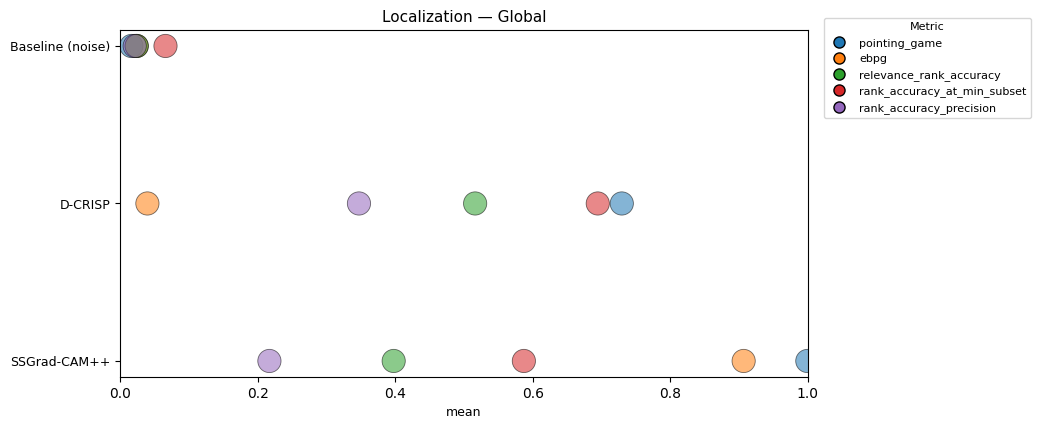

Saved -> results/final/figures/Localization_Global.png


In [64]:
render_family_table(master, "Localization", "Global")

### Análisis — Localización, Global

**pointing_game**: SSGrad-CAM++ prácticamente saturado (techo, casi sin margen para mejorar) frente a D-CRISP (mediana=1/std alto confirma un patrón binario puro: acierta el píxel máximo en ~73% de los objetos y falla por completo en ~27%). Ambos muy por encima del baseline (coherente con que la caja mediana ocupa solo ~0.75% de la imagen — buena señal de validez del pipeline). Ventaja clara y fiable de SSGrad-CAM++: su heatmap, concentrado en una única celda-ancla, pone el pico casi siempre dentro de la caja; el de D-CRISP, más disperso (máscaras agregadas), falla el pico exacto en 1 de cada 4 objetos aunque el resto del heatmap pueda estar bien orientado.

**ebpg**: SSGrad-CAM++ muy alto (0.9066) frente a D-CRISP casi al nivel del baseline (0.0397 vs. 0.0242 del ruido — solo +64% de mejora, muy por debajo del +3650% de SSGrad-CAM++; comparación válida porque es entre métodos, dentro de Global). Esto no debe leerse como que D-CRISP apenas localiza mejor que el ruido aleatorio: el ruido disperso de baja intensidad que sus máscaras dejan por toda la imagen infla el denominador de "energía total" sin que la localización real sea mala. La contradicción con pointing_game y, sobre todo, con relevance_rank_accuracy confirma que es exactamente el artefacto ya documentado, no un hallazgo nuevo.

**relevance_rank_accuracy**: aquí D-CRISP gana (0.5162 vs. 0.3978 de SSGrad-CAM++, +30% relativo) — la métrica de localización diseñada específicamente para no penalizar el ruido de fondo disperso (solo importa el orden, no la magnitud). Confirma que la localización real de D-CRISP es buena y que su EBPG bajo es un artefacto de la métrica. Ambos muy por encima del baseline (0.0241).

**rank_accuracy_at_min_subset y rank_accuracy_precision**: D-CRISP gana en las dos (0.6945 vs. 0.5871 recall; 0.3473 vs. 0.2171 precisión). Con la salvedad ya establecida: estas dos métricas dependen mecánicamente de min_subset_k_pixels_exact (Fidelidad), así que esta ventaja habrá que confirmarla cruzándola con el tamaño de k de cada método. El propio baseline de ruido tiene aquí un valor (0.066) notablemente más alto que sus otras métricas de localización (~0.024) — señal de que incluso el ruido puro se beneficia de un k grande, lo que hace más notable que D-CRISP gane pese a tener, según la validación piloto, un k habitualmente menor que el de SSGrad-CAM++.

**Formas de distribución a tener en cuenta**: `rank_accuracy_precision` de SSGrad-CAM++ es
fuertemente asimétrica (mediana 0.022 muy por debajo de su media 0.217, std 0.351 casi tan grande
como la media) — coherente con el patrón bimodal ya documentado en la validación piloto (muchos
objetos con precisión casi nula, pocos con precisión alta). D-CRISP, en cambio, tiene mediana
(0.271) y media (0.347) mucho más próximas — distribución más regular. `rank_accuracy_at_min_subset`
de D-CRISP muestra el patrón inverso (mediana 0.801 por encima de la media 0.695) — asimetría hacia
valores altos, con una cola de objetos peor cubiertos arrastrando la media hacia abajo.

**Validez del pipeline**: el baseline de ruido aleatorio da valores bajos y coherentes en las 5
métricas (0.016-0.066, todas muy por debajo de los dos métodos reales), confirmando que la
evaluación distingue correctamente explicación real de ruido.

**Resumen**: en Localización Global, SSGrad-CAM++ gana de forma fiable solo en `pointing_game`
(pico único mejor centrado); D-CRISP gana en las tres métricas basadas en ranking
(`relevance_rank_accuracy`, `rank_accuracy_at_min_subset`, `rank_accuracy_precision`), que son
precisamente las diseñadas para no penalizar el ruido de fondo de los métodos de máscaras
aleatorias. La aparente ventaja de SSGrad-CAM++ en `ebpg` es un artefacto conocido, no una mejor
localización real. Pendiente de confirmar con Fidelidad Global: si el `min_subset_k_pixels_exact`
de D-CRISP es efectivamente menor que el de SSGrad-CAM++ (como en la validación piloto), la
ventaja de D-CRISP en recall/precisión del subconjunto mínimo sería aún más sólida de lo que
sugieren estos números en bruto.

Fidelidad

Saved -> results/final/tables/Fidelity_Global.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
global,deletion_auc,SSGrad-CAM++,8051,0.3084,0.3337,0.2147,-557.6%
global,deletion_auc,D-CRISP,8051,0.0495,0.0160,0.0713,-5.6%
global,deletion_auc,Baseline (noise),8051,0.0469,0.0444,0.0320,—
global,insertion_auc,SSGrad-CAM++,8051,0.6296,0.6820,0.2348,+37.6%
global,insertion_auc,D-CRISP,8051,0.7368,0.8419,0.2301,+61.1%
global,insertion_auc,Baseline (noise),8051,0.4574,0.4184,0.2760,—
global,minimal_subset,SSGrad-CAM++,8051,0.3953,0.4828,0.2477,-377.8%
global,minimal_subset,D-CRISP,8051,0.0775,0.0345,0.0864,+6.4%
global,minimal_subset,Baseline (noise),8051,0.0827,0.0690,0.0441,—
global,min_subset_k_pixels_exact,SSGrad-CAM++,8051,54490.6573,69146.0000,36758.5749,-476.6%


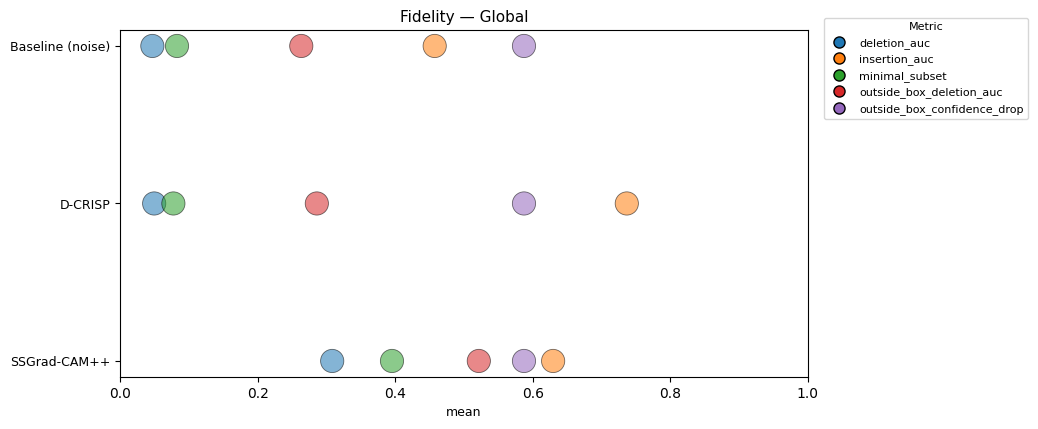

Saved -> results/final/figures/Fidelity_Global.png


In [65]:
render_family_table(master, "Fidelity", "Global")

### Análisis — Fidelidad, Global

**Hallazgo principal, el más importante de esta tabla: SSGrad-CAM++ rinde peor que el ruido aleatorio en fidelidad, de forma consistente en las tres métricas de la curva de Deletion** 
`deletion_auc`: SSGrad-CAM++ 0.308 frente a 0.047 del baseline — **-557.6% de "mejora"**, es decir, muchísimo peor.
`min_subset_k_pixels_exact`: SSGrad-CAM++ necesita borrar de media 54.491 píxeles (≈38% del frame
letterboxed) para hacer caer la detección, frente a solo 9.451 del baseline (ruido puro) — el orden
de importancia que asigna SSGrad-CAM++ a los píxeles es, en promedio, **menos eficiente que borrar
píxeles al azar**. `minimal_subset` confirma la misma dirección (-377.8% frente al baseline). Las
tres métricas miden facetas distintas de la misma curva de Deletion y coinciden: no es un artefacto
de una sola fórmula.

**Esto no contradice los buenos resultados de Localización — los complementa y matiza.** EBPG
(0.907) y pointing_game (0.999) dicen que casi toda la energía/el pico del heatmap de SSGrad-CAM++
cae dentro de la caja; pero Localización mide *dónde* se concentra la atribución, no si el *orden*
exacto de esa atribución, píxel a píxel, coincide con qué píxeles son causalmente necesarios para
sostener la detección — eso es justo lo que mide Fidelidad, y es un eje distinto. 

**`insertion_auc` se comporta de manera distinta y asimétrica**: aquí SSGrad-CAM++ sí bate al baseline (0.630 vs. 0.457, +37.6%), y D-CRISP le gana a su vez (0.737, +61.1% sobre baseline). Insertar los píxeles que SSGrad-CAM++ señala como importantes sí ayuda a recuperar confianza — coherente con que, al concentrar bien su atribución sobre la caja, revelar esa zona general basta para que el detector reconozca el objeto, aunque el orden fino de esa revelación no sea el más eficiente. SSGrad-CAM++ señala bien dónde mirar, pero no identifica bien qué píxeles concretos son imprescindibles — disociación real entre Insertion y Deletion para este método, no presente en D-CRISP (que gana en ambas direcciones).

**D-CRISP es sólido y coherente en las tres métricas de Deletion**. Frente al baseline queda prácticamente empatado en deletion_auc (-5.6%, ligeramente peor) y en minimal_subset ligeramente mejor (+6.4%) — ambos efectos pequeños y de signo opuesto, probablemente ruido de medición. Pero en min_subset_k_pixels_exact la ventaja es clara e inequívoca en valor absoluto: D-CRISP necesita de media solo 8.274 píxeles para tumbar la detección, frente a 9.451 del propio ruido y 54.491 de SSGrad-CAM++ — un 12,5% menos que el baseline y 6,6 veces menos que SSGrad-CAM++.

**`outside_box_deletion_auc` — leída como ratio frente a `deletion_auc`**:
cociente de las medias de grupo (no media de cocientes por objeto): D-CRISP 0.2861/0.0495 = 5.77, baseline 0.2634/0.0469 = 5.61 (D-CRISP se comporta, en este ratio, de forma parecida al ruido puro), SSGrad-CAM++ solo 0.5216/0.3084 = 1.69 — su curva "fuera de la caja" y su curva "dentro de la caja" son mucho más parecidas entre sí que en los otros dos casos, reforzando la hipótesis de un ranking global poco discriminativo.

**`outside_box_confidence_drop` — idéntica en las tres filas (0.5873), incluido el baseline.**
La gráfica lo confirma visualmente: los tres puntos morados están exactamente alineados en el mismo valor de x. Confirma, ahora también frente al ruido, que esta métrica no depende del heatmap ni del método: es una propiedad del objeto/caja/clasificador. Nótese además que la mediana (0.712) está sustancialmente por encima de la media (0.587) — distribución asimétrica hacia la izquierda, con una cola de objetos donde el contexto exterior apenas aporta confianza, que arrastra la media hacia abajo.

*Nota metodológica:* esta cifra global mezcla objetos de tamaños y distancias muy distintos.
Como se detalla en los bloques de Tamaño y Distancia, `deletion_auc`, `minimal_subset` y
`min_subset_k_pixels_exact` se calculan sobre el fotograma completo, no sobre el área del
objeto, por lo que su valor depende en parte de cuánto espacio ocupa cada objeto en la imagen.
La cifra global sigue siendo un resumen agregado válido, pero cualquier variación de estas
tres métricas entre categorías debe leerse con la matización de esas secciones.

**Resumen**: el hallazgo más relevante de Fidelidad Global es que SSGrad-CAM++, pese a localizar muy bien, ordena sus píxeles peor que el azar a la hora de causar el fallo de la detección — una disociación real entre Localización y Fidelidad, confirmada por tres métricas independientes y por su asimetría con insertion_auc. D-CRISP es el más fiel de los dos métodos reales en 2 de las 3 métricas de Deletion en términos absolutos, reforzando su ventaja ya vista en Localización. Pendiente de contrastar con Robustez/Cobertura y con los desgloses por tamaño/distancia para ver si esta disociación de SSGrad-CAM++ es uniforme o se concentra en ciertos tipos de objeto.

Complejidad

Saved -> results/final/tables/Complexity_Global.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
global,sparseness,SSGrad-CAM++,8051,0.9970,0.9987,0.0032,+351.5%
global,sparseness,D-CRISP,8051,0.2056,0.1436,0.1581,-6.9%
global,sparseness,Baseline (noise),8051,0.2208,0.2208,0.0005,—


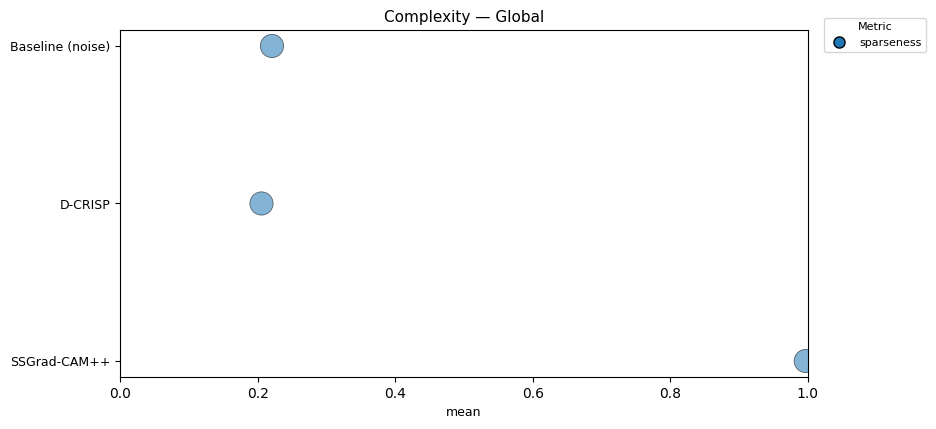

Saved -> results/final/figures/Complexity_Global.png


In [66]:
render_family_table(master, "Complexity", "Global")

### Análisis — Complejidad, Global

SSGrad-CAM++ tiene una sparseness casi máxima y con una dispersión mínima: media 0.9970 (mediana 0.9987, std 0.0032) lo que indica que su mapa de activación concentra la atribución en una región reducida. Además, con el valor de pointing_game para SSGrad-CAM++ ya conocido (0.9993) podemos concluir que, para el global de los datos, el método SSGrad-CAM++ concentra su explicación en una región reducida y dentro de la caja delimitadora del objeto.

**El baseline en sí mismo es un hallazgo interesante y coherente**: su sparseness es casi una
constante (std=0.0005, 400 veces más pequeña que la de D-CRISP) con media≈mediana
(0.2208≈0.2208). Tiene sentido: el heatmap del baseline es ruido i.i.d. Uniform(0,1) fresco en cada
objeto, sobre ~143.360 píxeles — con una muestra tan grande, el índice de Gini converge, por ley de
los grandes números, a un valor casi fijo determinado solo por la distribución uniforme y la
resolución del frame, no por ningún contenido de la imagen. Es, en la práctica, el "cero absoluto"
de sparseness para este tamaño de heatmap — la referencia de "ninguna concentración en absoluto".

**D-CRISP, con media 0.2056, queda incluso por DEBAJO de ese cero absoluto del ruido puro** (-6.9%).
Esto no significa que D-CRISP concentre su explicación peor que el azar — es coherente con su
propio mecanismo de construcción: el heatmap final es un promedio ponderado de ~1000 máscaras
aleatorias (`explain_image`), y promediar muchas muestras aleatorias suaviza el resultado, 
dando un mapa más uniforme que una única muestra de ruido,
propiedad mecánica de cómo se agregan las máscaras, no evidencia de mala explicación (ya sabemos,
por Localización, que D-CRISP localiza tan bien o mejor que SSGrad-CAM++ en).

**Resumen**: los tres valores de esta tabla no deben leerse de forma aislada como una escala común de "calidad de explicación", ya que el de D-CRISP está afectado por su mecanismo de agregación de máscaras y el del baseline es esencialmente una constante estadística del ruido uniforme a esta resolución; el de SSGrad-CAM++, en cambio, sí refleja una concentración genuina de la atribución (se ha descartado que sea un artefacto geométrico de sus cajas, ver arriba). La lectura más honesta de Complejidad en este proyecto es condicionarla siempre a Localización: en SSGrad-CAM++, sparseness alta + `pointing_game` casi perfecto es evidencia consistente de una explicación simple y bien situada; en D-CRISP, su sparseness baja debe leerse junto a su mecanismo de agregación, no como un fallo de localización.

Robustez

Saved -> results/final/tables/Robustness_Global.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
global,stability_max_sensitivity,SSGrad-CAM++,6969,8.5765,8.5481,6.5733,+94.5%
global,stability_max_sensitivity,Baseline (vs SSGrad-CAM++),7445,154.9703,154.9726,0.1683,—
global,stability_max_sensitivity,D-CRISP,1361,71.5522,56.7085,44.7186,+53.8%
global,stability_max_sensitivity,Baseline (vs D-CRISP),7225,154.8184,154.8191,0.1871,—
global,stability_ris,SSGrad-CAM++,6969,0.0184,0.0142,0.0218,-724.1%
global,stability_ris,Baseline (vs SSGrad-CAM++),7445,0.0022,0.0007,0.0075,—
global,stability_ris,D-CRISP,1361,4.4146,0.0000,121.2977,-227572.7%
global,stability_ris,Baseline (vs D-CRISP),7225,0.0019,0.0006,0.0062,—
global,stability_ros,SSGrad-CAM++,6969,7063145088.6663,129271605.9274,104114459677.3340,-462.5%
global,stability_ros,Baseline (vs SSGrad-CAM++),7445,1255651667.7827,35917058.2872,14096567149.2981,—


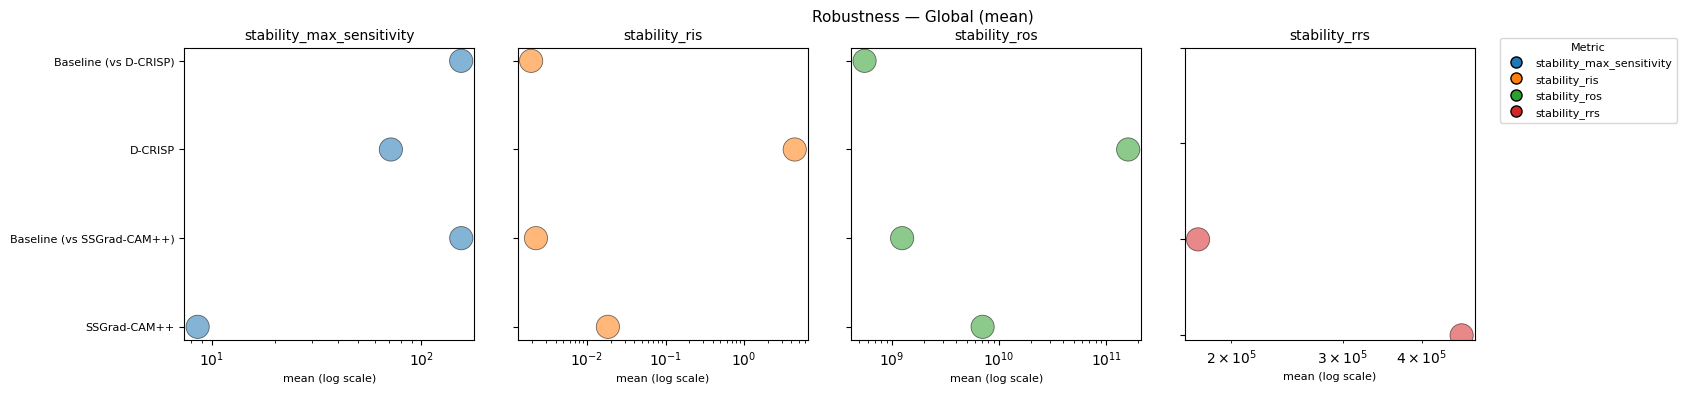

Saved -> results/final/figures/Robustness_Global_mean.png


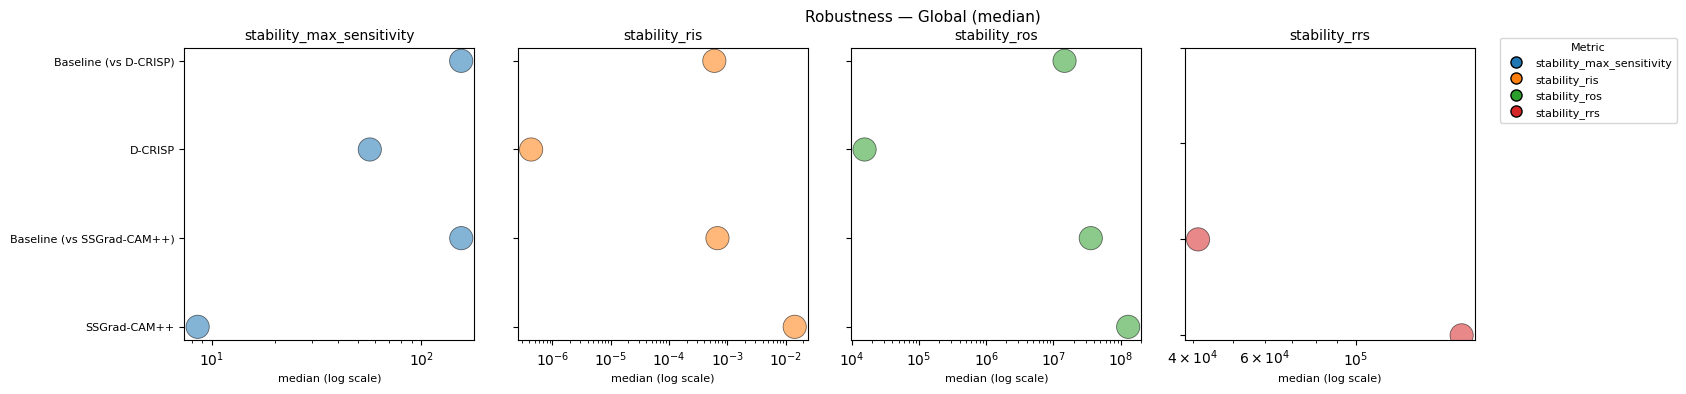

Saved -> results/final/figures/Robustness_Global_median.png


In [67]:
render_family_table(master, "Robustness", "Global")

### Análisis — Robustez, Global

**Cobertura muy desigual, tal como advierte la guía — con cifras reales.** `N` real: SSGrad-CAM++
6969/8051 (~86.6%), D-CRISP solo 1361/8051 (~16.9%, coherente con su muestra de ~300/1493 imágenes).
El baseline aparece por duplicado con su propio `N` (7445 frente a SSGrad-CAM++, 7225 frente a
D-CRISP) y valores casi idénticos entre sí (154.97 vs. 154.82 en `max_sensitivity`, con std
minúsculo: 0.168 y 0.187) — el heatmap del baseline es ruido i.i.d. fresco en cada perturbación, y
la norma de Frobenius entre dos mapas de ruido de ~143.360 píxeles converge, por concentración de
la medida, a un valor casi constante — el mismo fenómeno estadístico ya visto en `sparseness`
(Complejidad Global) para el baseline, ahora confirmado también en Robustez.

**`stability_max_sensitivity`: SSGrad-CAM++ gana con claridad y de forma creíble.** SSGrad-CAM++ 8.58 frente a D-CRISP 71.55 — 8.3 veces menor — y ambos muy por debajo del "ruido de fondo" del baseline (~155). Por tasa de mejora: +94.5% SSGrad-CAM++, +53.8% D-CRISP. La ventaja de SSGrad-CAM++ es especialmente creíble porque va en contra del sesgo de muestreo ya documentado: su máximo se toma sobre 20 muestras (D-CRISP solo 5), y un máximo sobre más muestras tiende a ser mayor, no menor — pese a esa desventaja de partida, sigue siendo el más bajo. El valor de SSGrad-CAM++ (8.58) encaja exactamente en el rango ya documentado en la validación piloto (7-14, por cambio de celda-ancla).

**Aviso metodológico importante — RIS y sobre todo ROS no se pueden leer por su media en esta
tabla.** El cociente media/mediana lo confirma sin ambigüedad: en `stability_ris`, D-CRISP tiene
mean/mediana ≈ **10,2 millones**; en `stability_ros`, D-CRISP tiene mean/mediana ≈ **10,4
millones**. Esto es la manifestación, a escala de la población completa, del artefacto de
`eps_min` (denominadores casi nulos que disparan muestras puntuales) — unos pocos objetos con un valor extremo bastan para arrastrar
la media varios órdenes de magnitud por encima de lo que le ocurre a un objeto típico. La gráfica de medias lo muestra con claridad: en los paneles stability_ris y stability_ros, el punto de D-CRISP aparece a la derecha de ambos baselines (peor); en la gráfica de medianas, el mismo punto de D-CRISP salta a la posición más a la izquierda de su panel (mejor que ambos baselines) — la inversión visual completa entre ambas figuras es la prueba más directa de la distorsión.
El `improvement_vs_baseline_pct` calculado sobre la media para D-CRISP en `stability_ros` (**-28.519%**)
no solo es una cifra poco fiable — **tiene el signo cambiado** respecto a lo que dice la mediana:

| métrica | comparación | por media | por mediana |
|---|---|---|---|
| stability_ris | D-CRISP vs. su baseline | -227.573% (peor) | **+99,93% (mejor)** |
| stability_ros | D-CRISP vs. su baseline | -28.519% (peor) | **+99,89% (mejor)** |

Por mediana, D-CRISP es prácticamente perfecto en ambas (mediana RIS=4.3e-7, mediana ROS=15.479,
muy por debajo de sus respectivos baselines) — el objeto D-CRISP típico apenas cambia su heatmap de
forma relativa ante ruido imperceptible. La media dice justo lo contrario solo por un puñado de
outliers numéricos. Baseline y SSGrad-CAM++ también muestran el mismo sesgo pero mucho
más moderado (cocientes media/mediana de 3.3x y 35-55x, no millones) — el problema es
específicamente severo para D-CRISP.

**Con la mediana como referencia, el panorama de SSGrad-CAM++ cambia y se vuelve coherente con un
único mecanismo ya conocido.** Por mediana, SSGrad-CAM++ es **peor que el ruido puro** en
`stability_ris` (mediana 0.0142 vs. 0.00067 del baseline, unas 21 veces peor), en `stability_ros`
(mediana 1.29e8 vs. 3.59e7, ~3.6 veces peor) y en `stability_rrs` (mediana 181.814 vs. 41.168, ~4.4
veces peor) — las tres coinciden en dirección con la propia media (a diferencia de D-CRISP, aquí no
hay cambio de signo, solo de magnitud). Esto no contradice el buen resultado de `max_sensitivity`:
es la otra cara del mismo mecanismo de "celda-ancla". Cuando la perturbación cruza el límite de celda, el salto absoluto del heatmap es moderado
(7-14, de ahí el buen `max_sensitivity`), pero ese salto ocurre con un cambio de entrada/confianza/
representación muy pequeño (perturbación de `radius=0.1`, casi imperceptible) — precisamente lo que
RIS/ROS/RRS penalizan: un cambio de salida grande en relación a un cambio de entrada pequeño. Es
decir, SSGrad-CAM++ cambia poco en términos absolutos, pero cuando cambia, cambia de forma
desproporcionada respecto a lo poco que se perturbó la entrada — una fragilidad estructural real de
su diseño (dependencia de una única celda), no un artefacto de medición como el de D-CRISP.

**`stability_rrs`**: SSGrad-CAM++ peor que su baseline tanto por media como por mediana,
reforzando la lectura anterior.

**Resumen**: dos historias distintas y ninguna es "D-CRISP gana" o "SSGrad-CAM++ gana" de forma
simple. SSGrad-CAM++ es más estable en términos absolutos (`max_sensitivity`) pero
desproporcionadamente frágil en términos relativos (RIS/ROS/RRS) — fragilidad real, achacable a su
dependencia de una única celda-ancla. D-CRISP, leído
por mediana, es extremadamente estable en RIS/ROS pero con una media
completamente distorsionada por outliers numéricos del `eps_min`.

Cobertura de robustez

Saved -> results/final/tables/Coverage_Global.csv


group,metric,method,N,mean,median,std
global,stability_n_valid,SSGrad-CAM++,8051,69.3398,95.0000,39.4689
global,stability_n_valid,Baseline (vs SSGrad-CAM++),8051,84.1281,100.0000,32.4950
global,stability_n_valid,D-CRISP,1537,82.6155,100.0000,34.7263
global,stability_n_valid,Baseline (vs D-CRISP),8051,84.1336,100.0000,33.2505
global,stability_n_rejected_gate,SSGrad-CAM++,8051,15.8719,0.0000,32.4950
global,stability_n_rejected_gate,Baseline (vs SSGrad-CAM++),8051,15.8719,0.0000,32.4950
global,stability_n_rejected_gate,D-CRISP,1537,17.3845,0.0000,34.7263
global,stability_n_rejected_gate,Baseline (vs D-CRISP),8051,15.8664,0.0000,33.2505
global,stability_n_rejected_explain,SSGrad-CAM++,8051,14.7882,0.0000,26.1274
global,stability_n_rejected_explain,Baseline (vs SSGrad-CAM++),8051,0.0000,0.0000,0.0000


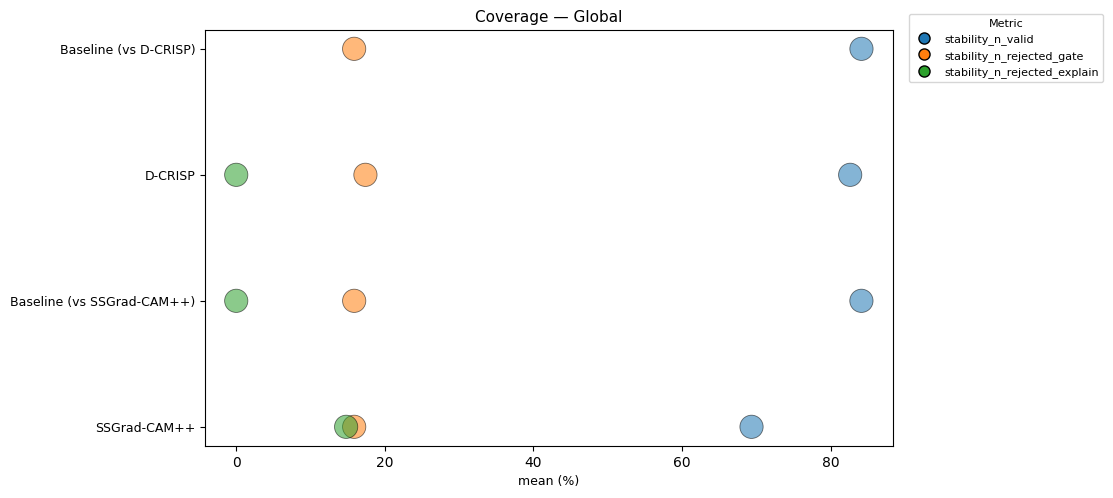

Saved -> results/final/figures/Coverage_Global.png


In [68]:
render_family_table(master, "Coverage", "Global")

### Análisis — Cobertura, Global

**Aviso de unidades, verificado contra `eval_metrics.csv` real antes de interpretar nada.** A
primera vista, la media/mediana de `stability_n_valid` (SSGrad-CAM++ 69.34/95.0, D-CRISP 82.62/100.0)
parecen imposibles: `n_samples` es 20 para SSGrad-CAM++ y 5 para D-CRISP, así que un valor de 95 o
100 no es un recuento crudo. Esta tabla en concreto reporta Cobertura en **% del propio
`n_samples`**, no en recuento absoluto — una unidad distinta de la que describí en la guía de
métricas (que asumía recuento entero en [0, n_samples]). Es una elección de diseño acertada, no un
error: pone a los dos métodos en una escala común (0-100%) pese a tener `n_samples` distintos.

**El "gate" es, en efecto, completamente independiente del método — comprobado, no solo asumido.**
`stability_n_rejected_gate` de SSGrad-CAM++ (15.8719%) y de su baseline son **idénticos hasta la
última cifra decimal**. Esto confirma empíricamente lo que el
código ya garantizaba por diseño: el filtro compartido de "¿sigue existiendo la detección tras la
perturbación?" no depende del heatmap, así que para el mismo objeto y la misma semilla, el
rechazo por filtro es exactamente igual se evalúe con el heatmap de SSGrad-CAM++, con el de ningún
método, o con ruido puro.

**El hueco de cobertura de SSGrad-CAM++ frente a su baseline se explica al 100% por su propio
mecanismo de anclaje, no por el detector.** SSGrad-CAM++: 69.34% válido = 100% − 15.87% (filtro) −
14.79% (fallo de `explain_fn`). Su baseline: 84.13% = 100% − 15.87% (mismo filtro) − 0% (el ruido
nunca falla al explicar). La diferencia entera (69.34 vs. 84.13) es, literalmente, el
coste del filtro de anclaje (`iou_match_thres=0.90` en el régimen de perturbación) — cuantifica de
forma concreta lo que antes solo se describía cualitativamente: SSGrad-CAM++ descarta ~1 de cada 7
perturbaciones que el detector sí habría tolerado, porque no logra relocalizar su celda-ancla con
suficiente confianza. Consecuencia práctica para leer la tabla de Robustez: su tamaño de muestra
*efectivo* medio no es 20, son ~13.9 (69.34% de 20) — sigue siendo bastante mayor que el efectivo de
D-CRISP (~4.13, 82.62% de 5), así que el argumento de "máximo sobre más muestras" de la guía sigue
aplicando, aunque con estas cifras efectivas en vez de las nominales.

**Resumen**: la tabla es correcta una vez identificada la unidad (%), y aporta un hallazgo con valor
propio para la memoria: el filtro de detección es verificablemente independiente del método (prueba
empírica, no solo de diseño), y el "coste de cobertura" de SSGrad-CAM++ frente al ruido puro se
explica íntegramente por su propio mecanismo de anclaje — no por un detector menos tolerante con su
heatmap. D-CRISP no paga ningún coste de este tipo (0% de rechazo por explicación, por construcción),
pero su comparación directa con "su" baseline en esta tabla mezcla dos poblaciones de tamaño distinto
y debe leerse con esa salvedad.

## Conclusión conjunta — Localización + Fidelidad + Complejidad + Robustez + Cobertura, Global

Cruzando las cinco familias sobre la población completa, el hallazgo más importante es que no hay un método que gane en todos los ejes — tienen perfiles de fortalezas y debilidades casi complementarios, y varias comparaciones "en bruto" son engañosas si no se leen con las salvedades ya establecidas en la guía de métricas.

### Perfil de SSGrad-CAM++: excelente localizando dónde mirar, pero frágil en lo causal y lo relativo

Gana con claridad y de forma fiable en `pointing_game` (0.999 vs. 0.729) y en `insertion_auc` (0.630
vs. baseline 0.457, aunque D-CRISP le supera aquí también). Su `stability_max_sensitivity` es la
mejor de las tres filas (8.58, 18 veces menor que el "ruido de fondo" del baseline, ~155) — cambia
poco en términos absolutos ante perturbaciones imperceptibles. Y su cobertura de Robustez, aunque
menor que la de su propio baseline (69.3% vs. 84.1%), se explica al 100% por el coste conocido de su mecanismo de anclaje (`iou_match_thres=0.90`), no por ningún problema del detector. Su `sparseness` casi perfecta (0.997) es también una fortaleza genuina, que combinada con su `pointing_game` casi perfecto, SSGrad-CAM++ produce heatmaps que no solo señalan la región correcta, sino que lo hacen de forma compacta y visualmente concentrada.

Pero en tres ejes independientes rinde peor que el ruido aleatorio puro: `deletion_auc`
(-557.6%), `minimal_subset` (-377.8%) y `min_subset_k_pixels_exact` (necesita borrar ~54.491
píxeles, ~38% del frame, frente a solo ~9.451 del propio ruido). Y en términos *relativos* de
estabilidad (no absolutos), también rinde peor que el ruido en las tres métricas de Agarwal et al. por mediana (RIS ~21x peor, ROS ~3.6x peor, RRS ~4.4x peor).

**Hipótesis unificadora, razonada a partir de los propios hallazgos de este bloque (no una certeza
verificada al 100%, pero coherente con todo lo observado)**: estas tres debilidades — mala fidelidad
por borrado, fragilidad relativa alta, k de subconjunto mínimo enorme — comparten una causa
plausible común: un mapa de activación nativo de baja resolución (28×80) interpolado a los ~143.360
píxeles del frame, y una dependencia arquitectónica de una única celda-ancla para todo el heatmap. 
Esto produce un heatmap espacialmente correcto (localiza bien la caja) pero con un orden píxel a píxel poco discriminativo
(de ahí la mala fidelidad de borrado) y con un comportamiento binario ante la perturbación (la celda
cambia o no cambia) que convierte un input casi igual en un output desproporcionadamente distinto
cuando sí cambia (de ahí la mala robustez relativa, pese a la buena robustez absoluta).

### Perfil de D-CRISP: más fiel y más robusto en lo relativo, con dos métricas que lo penalizan sin motivo real

Gana en las tres métricas de fidelidad por borrado (`deletion_auc`, `minimal_subset`,
`min_subset_k_pixels_exact`, con un k ~6.6 veces menor que SSGrad-CAM++), en `insertion_auc`, y en
las tres métricas de localización basadas en ranking (`relevance_rank_accuracy`,
`rank_accuracy_at_min_subset`, `rank_accuracy_precision` — esta última con la salvedad ya señalada
de que su k más pequeño le da cierta ventaja mecánica en precisión, aunque su ventaja en recall va
*en contra* de esa misma mecánica, reforzando que es genuina). Por mediana, es prácticamente
perfecto en robustez relativa (RIS y ROS muy por debajo del baseline). No tiene ningún coste de
cobertura por fallo de explicación (0% siempre, no tiene mecanismo de anclaje que pueda fallar).

Dos métricas lo penalizan sin que sea una debilidad real, ambas ya verificadas mecanísticamente:
`ebpg` (0.040, casi al nivel del ruido) es un artefacto ya visto de los métodos de máscaras
aleatorias (ruido de fondo disperso que infla el denominador), contradicho por su propio buen
resultado en `relevance_rank_accuracy`; y `sparseness` (0.206, incluso por debajo del baseline) es
un efecto mecánico de promediar ~1000 máscaras aleatorias (suaviza el resultado), no una peor
localización real.

Advertencia que debe acompañar cualquier cifra de D-CRISP en Robustez/Cobertura: su muestra es mucho
más pequeña (~300/1493 imágenes) y, en el caso de `stability_ris`/`stability_ros`, su **media** está
gravemente distorsionada por valores atípicos numéricos (`eps_min`) — hasta el punto de invertir el
signo de la comparación frente al baseline según se use media o mediana. Cualquier cifra de D-CRISP
en estas dos métricas debe reportarse por mediana, no por media.

### Hallazgos que no son sobre los métodos, sino sobre el detector/el diseño experimental

`outside_box_confidence_drop` es idéntica en las tres filas (los tres métodos) de las seis tablas de Fidelidad donde aparece (Global y los cinco desgloses), aunque varía sustancialmente entre categorías dentro de cada desglose (p. ej. en Tamaño va de 0.105 en `large` a 0.667 en `small`) — confirma que el detector depende sustancialmente del contexto fuera de la caja para su confianza, y que esa dependencia es una propiedad del objeto/clasificador, no de ninguna explicación. El filtro compartido de "detección superviviente" en Robustez/Cobertura es, verificado cifra a cifra, completamente independiente del método. Y la comparación de D-CRISP contra "su" baseline en Cobertura mezcla poblaciones de tamaño distinto (1537 vs. 8051 objetos) —a diferencia de SSGrad-CAM++, cuya comparación con su baseline sí está perfectamente emparejada.

### Conclusión

En Global, SSGrad-CAM++ y D-CRISP no son mejor/peor de forma simple: SSGrad-CAM++ localiza mejor en el sentido más literal (pico de atribución) y es más estable en magnitud absoluta; D-CRISP es más fiel causalmente frente a SSGrad-CAM++, más eficiente (necesita muchos menos píxeles, incluso frente al propio ruido), y más robusto en términos relativos. Varias de las métricas donde uno "gana" claramente son, verificado, artefactos conocidos del diseño de la otra (EBPG y sparseness para D-CRISP; fidelidad de borrado y robustez relativa para SSGrad-CAM++) más que evidencia de calidad real de explicación. Queda por ver, en los siguientes bloques (Tamaño, Distancia, Corrección, Incertidumbre, Clase) —esta vez comparando categorías solo por valores brutos—, si este patrón de complementariedad se mantiene uniforme o si alguno de los dos métodos se degrada de forma distinta según el tipo de objeto, que es, al final, la pregunta que motivó estratificar el análisis desde el principio.

Por tamaño de caja delimitadora

Localización

Saved -> results/final/tables/Localization_Size.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
small,pointing_game,SSGrad-CAM++,6742,0.9991,1.0000,0.0298,+20312.1%
small,pointing_game,D-CRISP,6742,0.6857,1.0000,0.4643,+13909.1%
small,pointing_game,Baseline (noise),6742,0.0049,0.0000,0.0698,—
small,ebpg,SSGrad-CAM++,6742,0.8902,0.9410,0.1309,+9105.7%
small,ebpg,D-CRISP,6742,0.0207,0.0143,0.0181,+114.2%
small,ebpg,Baseline (noise),6742,0.0097,0.0058,0.0096,—
small,relevance_rank_accuracy,SSGrad-CAM++,6742,0.4452,0.4254,0.1923,+4539.3%
small,relevance_rank_accuracy,D-CRISP,6742,0.4904,0.5703,0.2779,+5010.2%
small,relevance_rank_accuracy,Baseline (noise),6742,0.0096,0.0062,0.0098,—
small,rank_accuracy_at_min_subset,SSGrad-CAM++,6742,0.6019,0.6038,0.2690,+803.7%


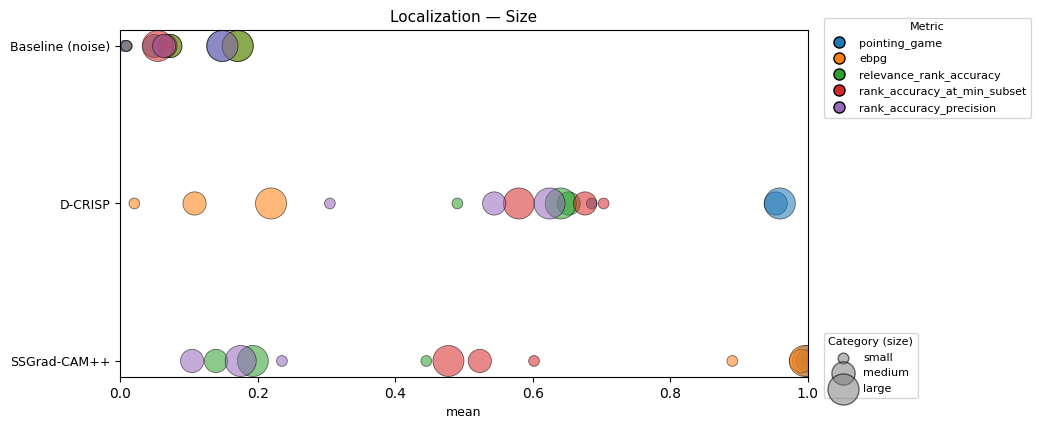

Saved -> results/final/figures/Localization_Size.png


In [69]:
render_family_table(master, "Localization", "Size")

### Análisis — Localización, por Tamaño

**Cobertura**: 6742 (pequeño, 83.7%) + 965 (mediano, 12.0%) + 344 (grande, 4.3%) = 8051. El grupo "grande" es pequeño en términos absolutos (344 objetos); sus estimaciones son más ruidosas que las de "pequeño", aunque el patrón que sigue aparece de forma consistente también en "mediano" (965), lo que da más confianza en que no es una casualidad del grupo más pequeño.

**pointing_game y ebpg escalan con el tamaño de forma esperable — ambas geométricamente, el baseline lo confirma con más claridad que nunca.** El baseline pasa de 0.0049 (pequeño) a 0.0497 (mediano) a 0.1483 (grande) en `pointing_game` — un incremento de ~30×, coherente con que la probabilidad de acertar el píxel máximo por puro azar escala con el área de la caja. SSGrad-CAM++ se mantiene prácticamente perfecto en los tres tamaños (0.999→1.000→1.000, **std=0 exacto** en mediano y grande: acierta las 1309 cajas medianas+grandes sin una sola excepción) — su precisión de pico no depende del tamaño del objeto. D-CRISP mejora con el tamaño (0.686→0.953→0.959, ×1.40) pero de forma mucho menos que proporcional al crecimiento del baseline (×30.3). Es una señal válida de que la mejora de D-CRISP es localización genuina, no solo el efecto de una caja más grande siendo más fácil de acertar por azar.

**`ebpg`.** D-CRISP: 0.0207→0.1083→0.2194 (×10.6 de pequeño a grande, incremento real y monótono). El baseline también sube, algo más deprisa en términos relativos (0.0097→0.0732→0.1712, ×17.7). La gráfica lo confirma visualmente: en la fila D-CRISP, la burbuja naranja crece de tamaño (categoría) y se desplaza claramente hacia la derecha (mayor valor) al pasar de pequeño a grande. Conclusión: el artefacto de EBPG para D-CRISP (ruido disperso que infla el denominador de "energía total") sigue presente en los tres tamaños con una magnitud similar — no hay evidencia, una vez corregido el método de comparación, de que se agrave con el tamaño del objeto.

**El hallazgo más importante de esta tabla — invisible en Global, y que cambia el relato**: en `relevance_rank_accuracy` (la métrica de localización más fiable, diseñada para no penalizar el ruido de fondo), **SSGrad-CAM++ se desploma casi al nivel del baseline en objetos medianos y grandes**: 0.445 en pequeño (bien por encima del baseline 0.0096) pero solo 0.139 en mediano (baseline 0.0729 — apenas por encima) y 0.193 en grande (baseline 0.1709 — casi empatado). D-CRISP, en cambio, se mantiene fuerte y estable en los tres tamaños (0.490→0.652→0.641). El mismo patrón, más marcado todavía, aparece en `rank_accuracy_precision`: SSGrad-CAM++ cae a 0.105 en mediano y solo se recupera parcialmente a 0.175 en grande, mientras D-CRISP **mejora** con el tamaño (0.305→0.544→0.624). La media Global (SSGrad-CAM++ 0.398 en RRA) estaba dominada por el 83.7% de objetos pequeños, donde SSGrad-CAM++ funciona razonablemente — esa media global escondía por completo que, en objetos medianos/grandes, su ranking de píxeles deja de distinguirse del azar. La gráfica lo muestra con nitidez: en la fila SSGrad-CAM++, la burbuja verde (RRA) de "pequeño" está muy a la derecha (~0.45), y las de "mediano"/"grande" —más grandes, por categoría— caen abruptamente hacia la izquierda, muy cerca de las burbujas del baseline.

**Hipótesis**: el mapa de activación nativo de SSGrad-CAM++ es de resolución fija y baja (28×80, Sección 6.24), atado a una única celda-ancla con un campo receptivo de tamaño aproximadamente constante. Para un objeto pequeño, ese campo receptivo cubre gran parte de la caja y el heatmap upsampleado puede ordenar razonablemente bien los pocos píxeles que la componen. Para un objeto grande, la caja abarca una región mucho mayor que ese campo receptivo fijo — el heatmap interpolado dentro de la caja puede volverse casi uniforme, haciendo que el orden fino de píxeles dentro de la caja se vuelva poco mejor que aleatorio, aunque el pico siga cayendo dentro de ella (de ahí que `pointing_game` no se vea afectado). Pendiente de confirmar cuando lleguemos a Correctness (¿coincide este patrón con una proporción distinta de aciertos/falsos positivos en mediano/grande?) y de cruzar con `min_subset_k_pixels_exact` por tamaño en la próxima tanda de Fidelidad, para ver si el k de SSGrad-CAM++ también se dispara en objetos grandes de forma coherente con esta hipótesis.

**`rank_accuracy_at_min_subset`** decae con el tamaño en ambos métodos de forma más proporcional: SSGrad-CAM++ -20.8% de pequeño a grande (0.602→0.477), D-CRISP -17.5% (0.703→0.580) — no muestra el mismo colapso abrupto que la RRA/precisión "puras". D-CRISP sigue ganando en los tres tamaños por un margen similar, comparando directamente sus medias brutas frente a las de SSGrad-CAM++ dentro de cada tamaño (+17% en pequeño, +29% en mediano, +21% en grande).

**Resumen**: el patrón de Global (D-CRISP gana en ranking, SSGrad-CAM++ gana en pico único) no es uniforme por tamaño — se acentúa muchísimo en objetos medianos y grandes, donde SSGrad-CAM++ pierde casi toda su capacidad de ranking fino (cae a nivel de ruido) mientras D-CRISP la mantiene o mejora. Esto sugiere que la ventaja de SSGrad-CAM++ vista en Global (pointing_game, EBPG) es robusta a cualquier tamaño, pero su localización *fina* solo es competitiva en objetos pequeños — la mayoría de la muestra, pero no todos. Pendiente de contrastar con Fidelidad por tamaño antes de cerrar esta conclusión.

Fidelidad

Saved -> results/final/tables/Fidelity_Size.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
small,deletion_auc,SSGrad-CAM++,6742,0.2709,0.2849,0.2025,-487.0%
small,deletion_auc,D-CRISP,6742,0.0356,0.0157,0.0509,+22.9%
small,deletion_auc,Baseline (noise),6742,0.0461,0.0426,0.0332,—
small,insertion_auc,SSGrad-CAM++,6742,0.5978,0.6390,0.2290,+39.2%
small,insertion_auc,D-CRISP,6742,0.7111,0.8145,0.2366,+65.6%
small,insertion_auc,Baseline (noise),6742,0.4294,0.3886,0.2691,—
small,minimal_subset,SSGrad-CAM++,6742,0.3570,0.4483,0.2384,-328.4%
small,minimal_subset,D-CRISP,6742,0.0614,0.0345,0.0619,+26.3%
small,minimal_subset,Baseline (noise),6742,0.0833,0.0690,0.0461,—
small,min_subset_k_pixels_exact,SSGrad-CAM++,6742,48832.3888,61884.0000,35487.8393,-412.2%


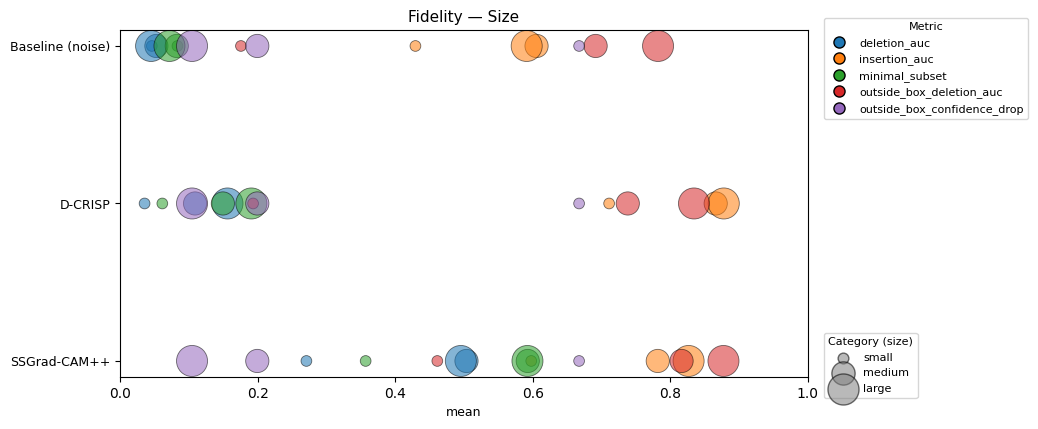

Saved -> results/final/figures/Fidelity_Size.png


In [70]:
render_family_table(master, "Fidelity", "Size")

Antes de leer el análisis, merece la pena detenerse en algo que se aprecia en la tabla y la
gráfica anteriores: para las tres métricas basadas en borrado (deletion_auc, minimal_subset,
min_subset_k_pixels_exact), tanto D-CRISP como SSGrad-CAM++ necesitan borrar bastantes menos
píxeles en objetos pequeños que en objetos grandes. Antes de leerlo como una mejora real de la
explicación, conviene preguntarse si es solo eso.

Estas métricas borran píxeles sobre el fotograma completo, que mide siempre lo mismo, no se
ajusta al tamaño del objeto. Un objeto pequeño ocupa, por tanto, una porción mucho menor de ese
fotograma fijo que uno grande, así que cabría esperar que necesite menos píxeles borrados
simplemente por eso, sin que el método esté explicando nada mejor.

Para comprobarlo basta con mirar al baseline de ruido aleatorio, que no tiene ninguna capacidad
real de concentrarse en el objeto: si el efecto fuera solo cuestión del tamaño del fotograma, el
baseline también lo mostraría. Y no lo muestra — su valor de `min_subset_k_pixels_exact` apenas
cambia entre tamaños (9.535 → 9.434 → 7.849 píxeles, small/medium/large), mientras que D-CRISP
pasa de 5.848 a 25.255 y SSGrad-CAM++ de 48.832 a 83.593. 
Como el patrón aparece en los dos métodos reales pero no en el baseline, determinamos que
una parte de la mejora en objetos pequeños es un efecto mecánico del tamaño del objeto en el
fotograma, y otra parte es una diferencia real de calidad explicativa.

Otra hipótesis: Los objetos pequeños son más complicados de detectar para el modelo y más inestables bajo ciertos cambios. Esto cuadra con que los valores de D-Deletion sean más bajos (borrando pocos píxeles el modelo pierde confianza sobre la deteccón) y que valores de D-Insertion para la categoría `small` sean también menores (el modelo tarda más en obtener confianza sobre objetos pequeños).

### Análisis: Fidelidad por tamaño (small N=6742, medium N=965, large N=344)

**1. Colapso de `deletion_auc` con el tamaño — para AMBOS métodos, no solo SSGrad-CAM++**

| | small | medium | large |
|---|---|---|---|
| SSGrad-CAM++ | 0.271 (**-487%** vs baseline) | 0.504 (**-854%**) | 0.495 (**-999%**) |
| D-CRISP | 0.036 (**+22.9%**) | 0.109 (**-106.5%**) | 0.156 (**-246.4%**) |
| Baseline (ruido) | 0.046 | 0.053 | 0.045 |

El valor absoluto de SSGrad-CAM++ pasa de 0.271 a 0.504 entre pequeño y mediano —una degradación real y sustancial, ~1.9×— pero **se estabiliza entre mediano y grande** (0.504→0.495, una meseta, no una caída adicional). D-CRISP también empeora en términos absolutos de forma monótona y más gradual (0.036→0.109→0.156, ~4.4× de pequeño a grande). Como el baseline apenas se mueve (0.046→0.053→0.045), el porcentaje entre paréntesis no está inflando ni comprimiendo artificialmente esta tendencia — confirma lo mismo que las medias brutas.

Esto confirma y agrava la hipótesis planteada en la celda de Localización por tamaño (rejilla fija de SSGrad-CAM++ degradándose con objetos más grandes), con un matiz importante que añade esta tabla: la degradación **no es indefinidamente creciente, satura entre mediano y grande** — coherente con la nota del punto 2 sobre `min_subset_k_pixels_exact` (mismo patrón de saturación) y con la hipótesis de una rejilla de activación de resolución fija: una vez el objeto excede el tamaño de celda de la rejilla, el heatmap deja de refinarse más. En `deletion_auc`, la degradación no es solo relativa (peor ranking) sino de fidelidad causal directa, y llega a ser ~11 veces peor que el ruido puro para objetos grandes (0.495/0.045).

El hallazgo nuevo es D-CRISP: a nivel Global aparentaba estar aproximadamente a la altura del baseline (ligeramente peor, aprox -5%). Este promedio ocultaba una dependencia fuerte del tamaño: para objetos **pequeños** (83.7% de la población) D-CRISP bate al ruido con holgura (+22.9%, y por valor bruto 0.036 < 0.046), pero para **medianos** y **grandes** invierte el signo y queda peor que el ruido aleatorio en términos absolutos (0.109 > 0.053; 0.156 > 0.045). Es decir, la ventaja de fidelidad de D-CRISP observada a nivel Global está casi enteramente sostenida por los objetos pequeños; en objetos medianos/grandes, ninguno de los dos métodos de explicabilidad logra superar a la eliminación aleatoria de píxeles en `deletion_auc` — y esto se confirma tanto por el porcentaje como por la comparación directa de medias brutas.

Confirmación cruzada con `minimal_subset` (misma métrica, escala 0-1 normalizada): el patrón es idéntico en signo, magnitud relativa **y en la meseta small→medium→large** — SSGrad-CAM++ 0.357→0.593→0.592 (-328%/-619%/-725% vs baseline); D-CRISP 0.061→0.149→0.191 (+26.3%/-81.4%/-165.9%) — descartando que sea un artefacto de una única métrica. La meseta de SSGrad-CAM++ entre mediano y grande (0.593→0.592, prácticamente idéntico) aparece ahora en dos métricas independientes de Deletion, reforzando la hipótesis de saturación de la rejilla de activación.

**2. `min_subset_k_pixels_exact`: ambos métodos necesitan MÁS píxeles que el ruido aleatorio para tamaños medio/grande**

| | small | medium | large |
|---|---|---|---|
| SSGrad-CAM++ | 48 832 | 83 648 | 83 593 |
| D-CRISP | 5 848 | 19 166 | 25 255 |
| Baseline | 9 535 | 9 434 | 7 849 |

El baseline se mantiene prácticamente constante (~7 800–9 500 px) en los tres grupos: tiene sentido, ya que el orden de borrado aleatorio no depende de dónde ni de qué tamaño sea el objeto, así que el número de píxeles necesarios para degradar la confianza de un objeto concreto no debería escalar con su tamaño..

Ambos explicadores, en cambio, sí escalan con el tamaño — pero en direcciones opuestas respecto al baseline. Para objetos pequeños, D-CRISP necesita *menos* píxeles que el ruido (5 848 vs 9 535, más eficiente), mientras que SSGrad-CAM++ ya necesita *más* incluso en small (48 832 vs 9 535, ~5×). Para medianos/grandes, ambos métodos necesitan sustancialmente más píxeles que el ruido: SSGrad-CAM++ hasta ~83 600 (~9-11× el baseline) y D-CRISP hasta ~25 000 (~2-3× el baseline). Interpretado literalmente: para objetos medianos y grandes, usar el ranking de importancia de cualquiera de los dos explicadores para decidir qué borrar es *menos* eficiente que borrar píxeles al azar para tumbar la detección. Este resultado, ya intuido por `deletion_auc`, queda aquí triangulado con una tercera métrica independiente (recuento absoluto de píxeles, no AUC normalizada).

Nota adicional sobre SSGrad-CAM++: su k salta fuertemente de small→medium (48 832→83 648) pero luego se estabiliza en medium→large (83 648→83 593, prácticamente sin cambio, -0.07%). Es la misma meseta ya señalada en `deletion_auc`/`minimal_subset` — tres métricas de Deletion, tres confirmaciones independientes. Es coherente con la hipótesis de rejilla de activación de resolución fija: una vez el objeto ocupa una fracción del frame que ya excede la resolución/tamaño de celda de la rejilla, el patrón de importancia que produce el método deja de refinarse y el coste en píxeles satura en torno al ~58% del frame.

**3. `insertion_auc` NO colapsa con el tamaño — la fragilidad es específica de la dirección "deletion"**

| | small | medium | large |
|---|---|---|---|
| SSGrad-CAM++ | 0.598 (+39.2%) | 0.782 (+29.1%) | 0.827 (+39.8%) |
| D-CRISP | 0.711 (+65.6%) | 0.866 (+43.0%) | 0.878 (+48.5%) |
| Baseline | 0.429 | 0.606 | 0.591 |

La brecha absoluta método-menos-baseline no se reduce con el tamaño (SSGrad-CAM++: 0.169→0.176→0.236; D-CRISP: 0.282→0.260→0.287, ambas aproximadamente estables o crecientes), así que "sin tendencia de deterioro por tamaño" es una lectura robusta, no un artefacto de la normalización por baseline.

Ambos métodos superan cómodamente al baseline en los tres grupos, sin tendencia de deterioro por tamaño. Esto acota el alcance del hallazgo anterior: no es que "la explicación se vuelva mala" para objetos grandes en términos generales, sino específicamente que el orden de importancia deja de ser útil para *destruir* la detección por sustracción progresiva, aunque sigue siendo útil para *reconstruirla* por adición progresiva. Es una disociación deletion/insertion ya coherente con lo señalado a nivel Global, ahora confirmada como robusta a través de los tres estratos de tamaño y verificada tanto por porcentaje como por brecha absoluta.

**4. `outside_box_confidence_drop`: gradiente claro y intuitivo — hallazgo de detector, no de método**

Idéntico entre las tres filas de cada grupo (confirma de nuevo la independencia estructural respecto al heatmap, ya establecida a nivel Global): 0.667 (small) → 0.199 (medium) → 0.105 (large). Comparación puramente de valores brutos, sin tasa de mejora involucrada.

Interpretación: cuanto más pequeño es el objeto, más depende el detector del contexto circundante para mantener su confianza (borrar todo lo exterior a la caja le cuesta un 66.7% de confianza de media); cuanto más grande, menos contexto necesita (solo un 10.5% de caída en objetos grandes), porque su propio contenido visual ya es suficiente. Es un hallazgo sobre el comportamiento del propio detector YOLO26, no sobre la calidad de ninguno de los dos métodos de explicabilidad, y explica de forma natural por qué el promedio Global (~0.587) se sitúa cerca del extremo "small" (que domina la población, 6742/8051 ≈ 84%).

**5. Ratio `outside_box_deletion_auc / deletion_auc` (medias de grupo): estable para los métodos reales, creciente para el baseline**

| | small | medium | large |
|---|---|---|---|
| SSGrad-CAM++ | 1.70 | 1.62 | 1.77 |
| D-CRISP | 5.43 | 6.77 | 5.34 |
| Baseline | 3.81 | 13.10 | 17.35 |

El ratio de ambos métodos reales se mantiene prácticamente constante con el tamaño: su importancia relativa dentro/fuera de la caja no depende del tamaño del objeto. El del baseline, en cambio, crece con fuerza (3.81→13.10→17.35), porque su `outside_box_deletion_auc` sube hacia 1 con el tamaño (0.176→0.691→0.782 — borrar el exterior al azar cada vez hace menos daño, coherente con el punto 4) mientras su `deletion_auc` normal se mantiene plano. Es la misma historia de "los objetos grandes dependen menos del contexto" vista desde otro ángulo (cociente de medias brutas, no tasa de mejora).

**Síntesis para esta familia:** el eje tamaño revela una fragilidad importante que el nivel Global enmascaraba — para objetos medianos y grandes, la ventaja de fidelidad de D-CRISP sobre el ruido desaparece e incluso se invierte en la dirección "deletion" (aunque D-CRISP sigue siendo netamente mejor que SSGrad-CAM++ en términos absolutos en todos los tamaños). SSGrad-CAM++ degrada de forma severa entre pequeño y mediano, pero **satura entre mediano y grande** en las tres métricas de Deletion (`deletion_auc`, `minimal_subset`, `min_subset_k_pixels_exact`) — no es una degradación indefinidamente creciente. Esta fragilidad es específica de la dirección deletion (insertion se mantiene sólida, con margen estable 29%-66% verificado también por brecha absoluta) y es consistente con — y añade fuerza empírica a — la hipótesis de rejilla/resolución fija para SSGrad-CAM++ ya planteada en Localización por tamaño.

Complejidad

Saved -> results/final/tables/Complexity_Size.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
small,sparseness,SSGrad-CAM++,6742,0.9978,0.9987,0.0015,+351.9%
small,sparseness,D-CRISP,6742,0.2204,0.1606,0.1571,-0.2%
small,sparseness,Baseline (noise),6742,0.2208,0.2208,0.0005,—
medium,sparseness,SSGrad-CAM++,965,0.9950,0.9956,0.0029,+350.6%
medium,sparseness,D-CRISP,965,0.1272,0.0752,0.1356,-42.4%
medium,sparseness,Baseline (noise),965,0.2208,0.2208,0.0005,—
large,sparseness,SSGrad-CAM++,344,0.9863,0.9829,0.0057,+346.7%
large,sparseness,D-CRISP,344,0.1339,0.0676,0.1531,-39.4%
large,sparseness,Baseline (noise),344,0.2208,0.2208,0.0005,—


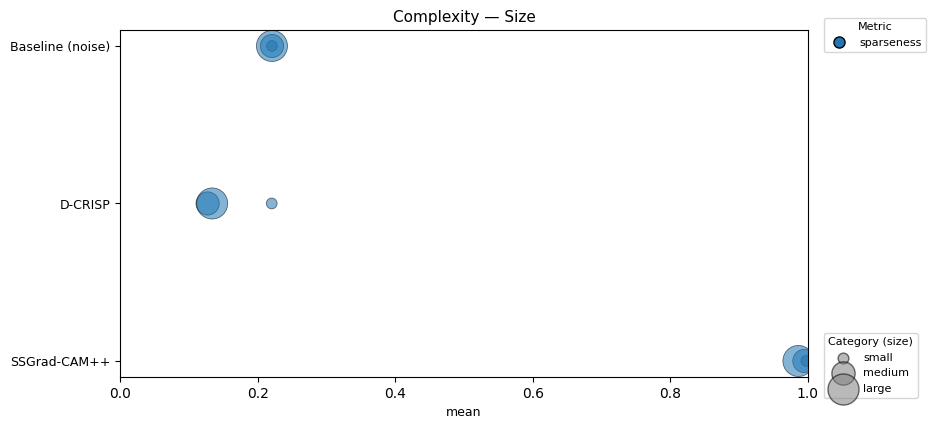

Saved -> results/final/figures/Complexity_Size.png


In [71]:
render_family_table(master, "Complexity", "Size")

### Análisis: Complejidad (sparseness) por tamaño (small N=6742, medium N=965, large N=344)

**1. El baseline es invariante al tamaño del objeto — confirma que mide una propiedad del mapa, no del objeto**

| | small | medium | large |
|---|---|---|---|
| Baseline (ruido) | 0.2208 | 0.2208 | 0.2208 |

El baseline se mantiene prácticamente idéntico (0.22080–0.22083, std≈0.0005 en los tres grupos) con independencia del tamaño del objeto evaluado. Tiene sentido: el heatmap del explicador aleatorio es ruido uniforme sobre toda la imagen, generado sin ninguna referencia a la caja del objeto, así que su Gini no tiene ningún motivo para variar con el tamaño de esta última. Este resultado es la confirmación, ahora estratificada, del fenómeno de concentración de la medida ya documentado a nivel Global.

**2. SSGrad-CAM++: descenso monótono y suave con el tamaño, un efecto real pero menor, no una prueba de que el nivel casi máximo sea artefacto geométrico**

| | small | medium | large |
|---|---|---|---|
| SSGrad-CAM++ (media) | 0.9978 | 0.9950 | 0.9863 |
| std | 0.0015 | 0.0029 | 0.0057 |

El valor decrece de forma monótona (comparación directa de medias brutas, sin usar la tasa de mejora) a medida que aumenta el tamaño del objeto, aunque se mantiene siempre muy cercano al techo (0.986–0.998). Este pequeño descenso (0.998→0.986) es *compatible* con un efecto geométrico leve (si la región de atribución escala en parte con el tamaño de la caja, una fracción algo mayor de píxeles recibe atribución no-nula y el Gini baja levemente), pero no es la única explicación disponible: la hipótesis de rejilla de activación de resolución fija (ya usada en Localización y Fidelidad por tamaño) predice la misma dirección, porque un objeto grande activa más celdas de anclaje distintas dentro de su caja. Ninguna de las dos se ha verificado por separado, así que este descenso se documenta como un efecto real pero modesto, sin atribuirlo con seguridad a la geometría. Lo que sí queda descartado es que el NIVEL casi máximo de sparseness (~0.99, muy por encima de D-CRISP y del baseline en cualquier tamaño) sea un artefacto de la geometría de la caja: D-CRISP, evaluado sobre las mismas cajas, no se acerca a ese nivel en ningún tamaño.

**3. D-CRISP: para objetos pequeños iguala al baseline, para medianos/grandes cae claramente por debajo — pero el orden medium vs. large depende de qué estadístico se use**

| | small | medium | large |
|---|---|---|---|
| D-CRISP (media) | 0.2204 | 0.1272 | 0.1339 |
| D-CRISP (mediana) | 0.1606 | 0.0752 | 0.0676 |
| Baseline | 0.2208 | 0.2208 | 0.2208 |

Para objetos pequeños, D-CRISP es prácticamente indistinguible del baseline por media (0.2204 vs 0.2208, diferencia de -0.17%, muy por debajo de lo que su propia dispersión permitiría discriminar). Para medianos y grandes, en cambio, cae de forma clara por debajo del baseline (-42.4% y -39.4% respectivamente, comparación intra-categoría válida) — el patrón "D-CRISP más disperso/menos concentrado que el propio ruido" que a nivel Global se atribuyó tentativamente al efecto de suavizado por promediado de máscaras (Sección 6.10) resulta ser, aquí, específico de objetos medianos/grandes, no un rasgo constante del método.

**Matiz importante, verificado al comparar medium vs. large entre sí**: por media, `large` (0.1339) es ligeramente *superior* a `medium` (0.1272) — una diferencia pequeña (+5.2%) que probablemente sea ruido de muestreo, dado el std tan grande (~0.15) y el N reducido de "large" (344). Por mediana, en cambio, el orden es monótono decreciente y mucho más claro (0.1606→0.0752→0.0676, la caída medium→large es del -10%, en la misma dirección que small→medium). Dado que ya sabemos (punto siguiente) que la distribución de D-CRISP tiene una cola derecha pesada, la mediana es aquí el estadístico más fiable — la afirmación correcta es que D-CRISP decrece de forma monótona con el tamaño **por mediana**, no necesariamente por media entre los dos grupos más grandes.

Dos observaciones adicionales importantes:

- La dispersión de D-CRISP es enorme frente a la del baseline (std 0.14–0.16 sobre una media de 0.12–0.22, coeficiente de variación ≈71-114%, frente a <0.3% del baseline). Esto es coherente con que el heatmap de D-CRISP tiene estructura espacial real y correlacionada (a diferencia del ruido iid del baseline), así que no se beneficia de la misma concentración de la medida.
- La mediana es sustancialmente menor que la media en los tres grupos (0.161 vs 0.220 en small; 0.075 vs 0.127 en medium; 0.068 vs 0.134 en large), señal de una distribución con cola derecha pesada. Usando la mediana como estadístico "típico" (más robusto aquí, igual que se decidió para `stability_ris`/`stability_ros`), el descenso con el tamaño es más marcado y limpio: 0.161→0.075→0.068, una caída de más de la mitad entre small y medium, seguida de un descenso adicional mucho más suave (-10%) entre medium y large.

**Síntesis para esta familia:** el nivel casi máximo de sparseness de SSGrad-CAM++ es una propiedad genuina del método, no un artefacto geométrico — pero su pequeño descenso con el tamaño (0.998→0.986) sí podría tener un componente geométrico, sin verificar, junto con la hipótesis alternativa de rejilla de resolución fija. D-CRISP, por su parte, muestra un posible efecto de suavizado por promediado de máscaras (mediana decreciendo de 0.161 a 0.068, por debajo del baseline en medium/large). El baseline permanece invariante en los tres tamaños, como cabía esperar. La comparación de sparseness entre métodos debe seguir leyéndose junto a Localización, y el nivel absoluto de SSGrad-CAM++ no debe descontarse como geometría.

Robustez

Saved -> results/final/tables/Robustness_Size.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
small,stability_max_sensitivity,SSGrad-CAM++,5837,7.6220,8.2702,5.4223,+95.1%
small,stability_max_sensitivity,Baseline (vs SSGrad-CAM++),6279,154.9684,154.9715,0.1706,—
small,stability_max_sensitivity,D-CRISP,1129,74.5879,61.1374,44.8253,+51.8%
small,stability_max_sensitivity,Baseline (vs D-CRISP),6084,154.8167,154.8190,0.1881,—
small,stability_ris,SSGrad-CAM++,5837,0.0162,0.0132,0.0182,-644.2%
small,stability_ris,Baseline (vs SSGrad-CAM++),6279,0.0022,0.0007,0.0069,—
small,stability_ris,D-CRISP,1129,5.3180,0.0000,133.1707,-282097.5%
small,stability_ris,Baseline (vs D-CRISP),6084,0.0019,0.0006,0.0057,—
small,stability_ros,SSGrad-CAM++,5837,6014430078.9433,119706714.5615,106815446926.8679,-486.3%
small,stability_ros,Baseline (vs SSGrad-CAM++),6279,1025862685.6957,38088113.7010,10854635793.1835,—


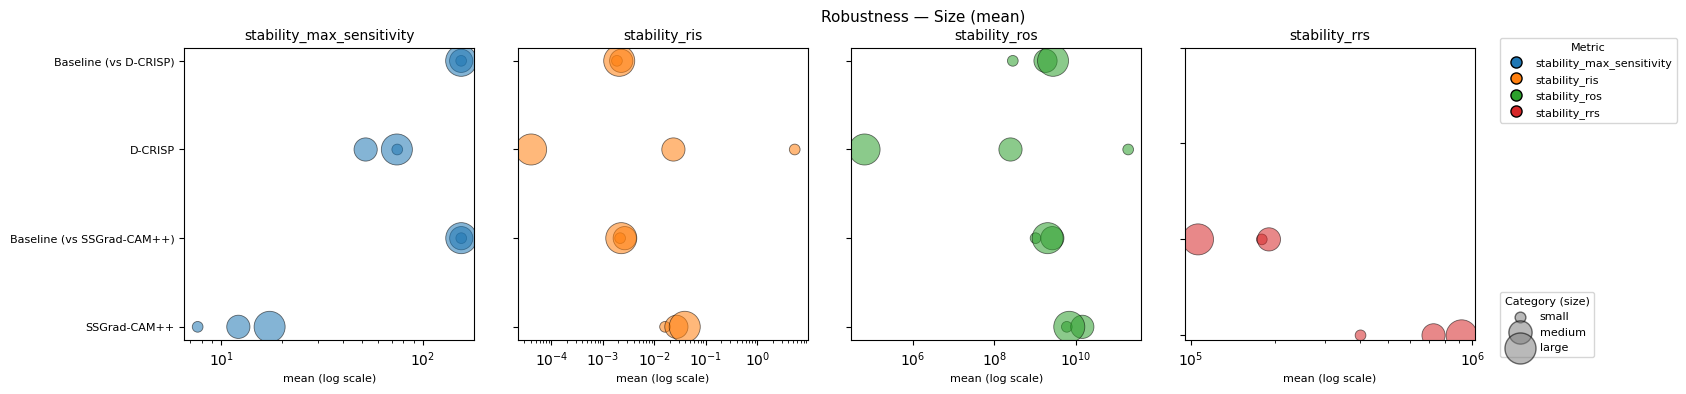

Saved -> results/final/figures/Robustness_Size_mean.png


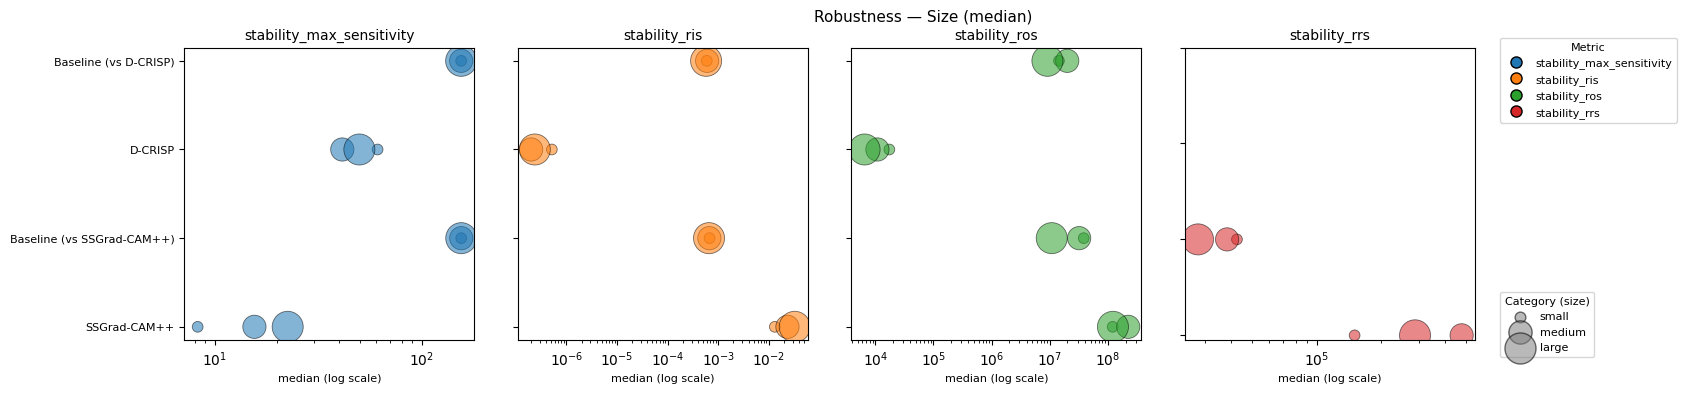

Saved -> results/final/figures/Robustness_Size_median.png


In [72]:
render_family_table(master, "Robustness", "Size")

### Análisis: Robustez por tamaño (small N≈6742, medium N≈965, large N≈344; N reales por métrica, ver tabla)

**0. Advertencia de cobertura muestral**

El tamaño de muestra efectivo de D-CRISP colapsa con fuerza en este desglose: N=1129 (small) → 182 (medium) → **50 (large)**. La comparación con su baseline nunca está emparejada en población (baseline usa 6084/850/291, la práctica totalidad del estrato, frente a la muestra restringida de D-CRISP) — continuación, ahora por estrato, de la asimetría ya documentada a nivel Global. Con N=50 en "large", cualquier estadístico de D-CRISP para ese grupo —y especialmente la media, dado el problema de suelo `eps_min` descrito más abajo— debe leerse con máxima cautela. SSGrad-CAM++, en cambio, mantiene una cobertura mucho más amplia y casi emparejada con su propio baseline en los tres grupos.

**1. `stability_max_sensitivity`: SSGrad-CAM++ empeora de forma monótona y clara con el tamaño; D-CRISP no muestra un patrón limpio**

| | small | medium | large |
|---|---|---|---|
| SSGrad-CAM++ (mediana) | 8.27 | 15.55 | 22.51 |
| Baseline (vs SSGC, mediana) | 154.97 | 154.98 | 154.99 |
| % del baseline | 5.3% | 10.0% | 14.5% |
| D-CRISP (mediana) | 61.14 | 41.29 | 49.93 |
| Baseline (vs D-CRISP, mediana) | 154.82 | 154.82 | 154.80 |
| % del baseline | 39.5% | 26.7% | 32.3% |

El baseline vuelve a ser prácticamente invariante al tamaño en ambas variantes (~154.8–155.0, std<0.19) — mismo fenómeno de concentración de la medida ya visto en sparseness. Al ser el baseline esencialmente constante, tanto la comparación en bruto como el "% del baseline" cuentan exactamente la misma historia aquí (no hay margen para distorsión): SSGrad-CAM++ muestra un crecimiento monótono y sustancial de su inestabilidad absoluta con el tamaño (mediana 8.27→15.55→22.51, casi se triplica), y su fracción del baseline crece en paralelo (5.3%→10.0%→14.5%). Sigue siendo, en todos los tamaños, mucho más estable en términos absolutos que el ruido puro, pero la ventaja se erosiona de forma sistemática al crecer el objeto.

D-CRISP no sigue un patrón monótono: su mediana baja de 61.1 (small) a 41.3 (medium) y luego sube de nuevo a 49.9 (large) — un mínimo en el grupo intermedio. Dada la caída de N (1129→182→**50**), este comportamiento en forma de U es compatible con ruido de muestreo, especialmente en "large"; a diferencia de SSGrad-CAM++ (tendencia limpia y respaldada por N grandes en los tres grupos), esta señal de D-CRISP no debe interpretarse como una tendencia real sin una muestra mayor.

**2. `stability_ris` y `stability_ros`: el suelo numérico `eps_min` vuelve a producir divergencias mean/mediana catastróficas — usar solo la mediana**

Confirmación, ahora estratificada, del artefacto ya identificado a nivel Global. Ejemplo extremo en RIS para D-CRISP: mediana ≈ 5.2·10⁻⁷ (small), 2.0·10⁻⁷ (medium), 2.4·10⁻⁷ (large) — esencialmente constante y pegada al suelo `eps_min=1e-6` en los tres grupos — mientras que la media es 5.318 (small), 0.0235 (medium) y 0.0000407 (large): una divergencia media/mediana de ~10.3 millones de veces en small, que se reduce a ~117 mil veces en medium y a ~171 veces en large. La razón de esta reducción progresiva es puramente muestral: al ir de 1129 a 182 a 50 objetos, la probabilidad de que la muestra contenga alguno de los casos raros con denominador casi nulo (que disparan el cociente a valores absurdamente altos) disminuye. Esto es lo que produce el vuelco de signo en `improvement_vs_baseline_pct` para D-CRISP en RIS: -282 097% (small) → -930.9% (medium) → **+98.1%** (large). Leído de forma ingenua, ese último valor sugeriría que D-CRISP mejora espectacularmente su estabilidad relativa para objetos grandes; en realidad solo refleja que, con N=50, esta vez no cayó en la muestra ningún objeto con denominador degenerado. La mediana —constante en ~2-5·10⁻⁷ en los tres grupos— es la que refleja el comportamiento típico real, y no muestra ninguna mejora genuina con el tamaño.

Exactamente el mismo patrón, aún más extremo en magnitud, aparece en `stability_ros` para D-CRISP: medias de 1.94·10¹¹ (small) → 2.48·10⁸ (medium) → 6.45·10⁴ (large) — una caída de casi seis órdenes de magnitud impulsada por outliers cada vez más escasos — frente a medianas mucho más moduladas y monótonas: 17 505 → 10 920 → 6 574 (una caída real, pero de solo ~2.7× de small a large, y su fiabilidad en "large" está limitada por N=50). El `improvement_vs_baseline_pct` correspondiente (-68 302% → +86.2% → +99.998%) es, de nuevo, un artefacto casi puro de outliers y tamaño de muestra decreciente, no una mejora real de la robustez de D-CRISP con el tamaño del objeto.

**3. Usando la mediana en los tres ejes relativos (RIS, ROS, RRS): RIS y ROS degradan de forma limpia y monótona para SSGrad-CAM++; RRS muestra un pico en "mediano", no una progresión limpia**

Calculando el ratio mediana(SSGrad-CAM++) / mediana(su propio baseline) por tamaño — comparación de valores brutos, no de tasas de mejora:

| | small | medium | large | patrón |
|---|---|---|---|---|
| RIS | 19.5× | 34.9× | 49.3× | monótono, ×2.5 de small a large |
| ROS | 3.1× | 7.0× | 11.2× | monótono, ×3.6 de small a large |
| RRS | 3.5× | **12.5×** | **10.3×** | pico en medium, ligero descenso en large |

RIS y ROS, leídas por su mediana (la única fiable dado el suelo `eps_min`), coinciden en una degradación limpia y monótona: SSGrad-CAM++ es cada vez más inestable en relación con el ruido aleatorio a medida que el objeto crece, entre 2.5× y 3.6× peor al pasar de pequeño a grande.

**RRS no sigue el mismo patrón limpio.** La mediana bruta de SSGrad-CAM++ en RRS es 150 569 (small) → 475 941 (medium) → 288 349 (large) — un salto grande de pequeño a mediano, seguido de un **descenso** real de mediano a grande (-39%), no una meseta ni una subida adicional. El ratio frente al baseline (3.5×→12.5×→10.3×) refleja fielmente ese pico-y-descenso, porque el baseline de RRS sí varía de forma moderada con el tamaño (42 491→38 215→27 960, cae ~34%) — a diferencia de `max_sensitivity`, aquí no es seguro asumir que baseline constante = tasa de mejora fiable. RRS sí confirma que SSGrad-CAM++ es sustancialmente más inestable en objetos medianos/grandes que en pequeños (10-12× frente a 3.5×), pero no aporta evidencia de que la degradación siga aumentando de mediano a grande — en todo caso, dentro de esta métrica concreta, se estabiliza o retrocede ligeramente.

Esta es una tercera línea de evidencia —tras Localización y Fidelidad por tamaño— apuntando al mismo mecanismo: la rejilla/resolución de activación fija de SSGrad-CAM++ no escala con el tamaño del objeto, y el salto small→medium es, en las tres métricas relativas, donde se concentra la mayor parte del deterioro. Aquí la interpretación específica de robustez es que, cuanto mayor es el objeto, más fácil resulta que una perturbación pequeña de la imagen desplace la celda de anclaje relevante (o la respuesta de varias celdas que compiten) — el mecanismo de bimodalidad por cambio de celda de anclaje ya documentado — produciendo saltos de heatmap proporcionalmente mayores en relación con la magnitud de la perturbación. Que RRS no seguía empeorando de medium a large sugiere que ese mecanismo satura de forma similar a como ya se observó en Fidelidad (meseta de `deletion_auc`/`min_subset_k_pixels_exact` entre medium y large) — un patrón de saturación, no de deterioro indefinido, que se repite ahora en una tercera familia.

**Síntesis para esta familia:** dos hallazgos separables. (a) SSGrad-CAM++ tiene una degradación de robustez con el tamaño consistente entre pequeño y mediano/grande, triangulada por su sensibilidad absoluta y por RIS/ROS (monótonas, vía mediana); RRS confirma el salto small→medium pero no una degradación adicional medium→large, coherente con el patrón de saturación ya visto en Fidelidad — refuerzo directo, desde un tercer eje (localización, fidelidad, ahora robustez), de la hipótesis de rejilla fija de baja resolución, con el matiz de que el deterioro se concentra en el primer salto de tamaño, no en una pendiente continua. (b) D-CRISP no permite una lectura de tendencia por tamaño igual de confiable: sus valores de RIS/ROS están dominados por el artefacto de suelo `eps_min`, con medias que fluctúan varios órdenes de magnitud de forma casi aleatoria según qué outliers caen en cada estrato cada vez más pequeño (hasta N=50 en "large"); solo la mediana ofrece una lectura interpretable, y aun esa debe tomarse con cautela dado el tamaño muestral. Para cualquier conclusión sobre robustez de D-CRISP o de RRS por tamaño.

Cobertura de robustez

Saved -> results/final/tables/Coverage_Size.csv


group,metric,method,N,mean,median,std
small,stability_n_valid,SSGrad-CAM++,6742,67.5749,95.0000,39.5823
small,stability_n_valid,Baseline (vs SSGrad-CAM++),6742,84.2198,100.0000,32.0856
small,stability_n_valid,D-CRISP,1270,82.6772,100.0000,34.5054
small,stability_n_valid,Baseline (vs D-CRISP),6742,84.2480,100.0000,32.8969
small,stability_n_rejected_gate,SSGrad-CAM++,6742,15.7802,0.0000,32.0856
small,stability_n_rejected_gate,Baseline (vs SSGrad-CAM++),6742,15.7802,0.0000,32.0856
small,stability_n_rejected_gate,D-CRISP,1270,17.3228,0.0000,34.5054
small,stability_n_rejected_gate,Baseline (vs D-CRISP),6742,15.7520,0.0000,32.8969
small,stability_n_rejected_explain,SSGrad-CAM++,6742,16.6449,0.0000,27.0121
small,stability_n_rejected_explain,Baseline (vs SSGrad-CAM++),6742,0.0000,0.0000,0.0000


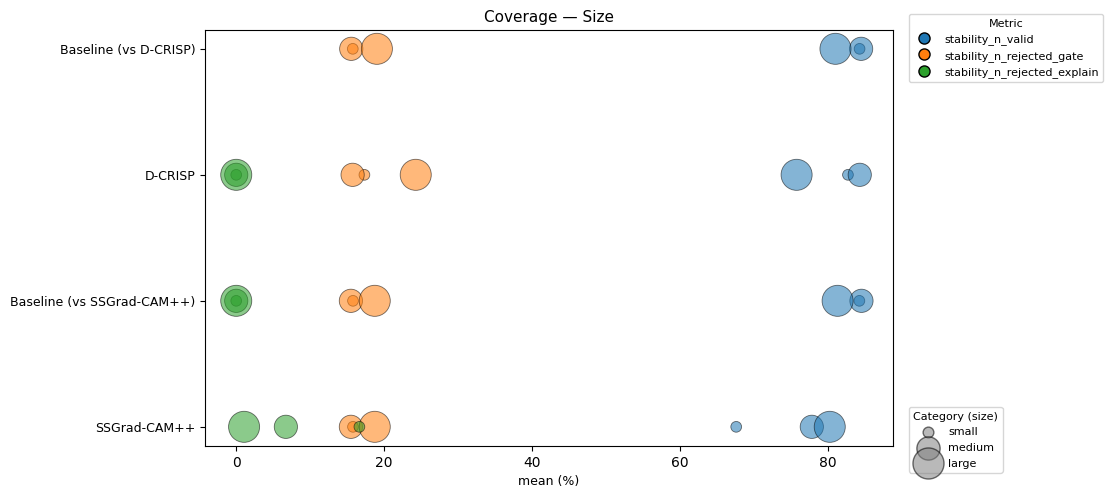

Saved -> results/final/figures/Coverage_Size.png


In [73]:
render_family_table(master, "Coverage", "Size")

### Análisis: Cobertura por tamaño (small N=6742, medium N=965, large N=344)

**1. `stability_n_valid`: SSGrad-CAM++ mejora su cobertura con el tamaño; D-CRISP y ambos baselines se mantienen estables**

| | small | medium | large |
|---|---|---|---|
| SSGrad-CAM++ (media / mediana) | 67.6% / 95% | 77.8% / 100% | 80.2% / 100% |
| D-CRISP (media / mediana) | 82.7% / 100% | 84.3% / 100% | 75.7% / 100% |
| Baseline (media / mediana) | ~84% / 100% | ~84.5% / 100% | ~81% / 100% |

SSGrad-CAM++ es el único caso con una tendencia clara: su cobertura media sube de forma monótona con el tamaño (67.6%→77.8%→80.2%), con una mediana que pasa de 95% a saturar en 100% desde "medium" en adelante — es decir, para objetos pequeños hay una cola no despreciable de casos con cobertura pobre que se reduce mucho para medianos/grandes. D-CRISP y ambos baselines se mantienen en un rango relativamente estable (75-85% de media, 100% de mediana) sin una tendencia definida por tamaño; su variación (D-CRISP cae a 75.7% en "large") es compatible con el ruido de una muestra pequeña (N=61) más que con un efecto sistemático.

**2. La mejora de cobertura de SSGrad-CAM++ con el tamaño se explica casi por completo por el rechazo en el paso `explain`, no por el `gate` — y va en dirección OPUESTA al patrón ya visto en Localización/Fidelidad/Robustez**

Descomponiendo la media de SSGrad-CAM++ en sus dos causas de rechazo:

| | small | medium | large |
|---|---|---|---|
| `n_rejected_gate` | 15.78% | 15.50% | 18.72% |
| `n_rejected_explain` | 16.64% | 6.71% | 1.06% |

El rechazo por `gate` (persistencia de clase+IoU>0 tras la perturbación) se mantiene aproximadamente estable, en un rango de 15.5%-18.7%, sin tendencia clara con el tamaño. El rechazo por fallo en el paso `explain` en cambio cae de forma marcada y monótona: 16.64% (small) → 6.71% (medium) → 1.06% (large) — una reducción de más de 15 puntos porcentuales, prácticamente hasta desaparecer para objetos grandes. Esta caída es la que explica casi en su totalidad la mejora observada en `n_valid`.

Es un hallazgo importante y merece señalarse con cuidado porque va en la dirección **contraria** a la de todos los patrones de tamaño encontrados hasta ahora para SSGrad-CAM++ (localización, fidelidad y robustez degradándose con objetos más grandes): aquí, la *fiabilidad de cómputo* del explicador (¿logra generar un mapa de atribución sin fallar, dada una detección perturbada?) mejora con el tamaño, mientras que la *calidad* de ese mapa, una vez calculado, empeora.

**3. Nota secundaria: el rechazo por `gate` tiende a ser algo mayor en objetos grandes, para todos los métodos y baselines por igual**

Tanto SSGrad-CAM++ (15.78%→15.50%→18.72%) como ambos baselines (~15.75-15.78%→~15.5%→~19-18.7%) muestran un `gate` ligeramente más alto en "large" que en small/medium. Al ser un fenómeno compartido por métodos y baselines —y por tanto no atribuible a ningún explicador— podría reflejar una propiedad del propio detector o del procedimiento de perturbación (p. ej., cajas grandes algo más sensibles a perder IoU>0 bajo una perturbación de radio fijo=0.1). Se señala como observación tentativa de nivel-detector, no como hallazgo firme, dado que la magnitud del efecto es modesta y no se ha investigado su mecanismo en el código.

**Síntesis para esta familia:** el hallazgo central de este bloque es la caída pronunciada del rechazo en el paso `explain` de SSGrad-CAM++ con el tamaño (16.6%→6.7%→1.1%), que mejora su cobertura efectiva para objetos grandes — un eje de "fiabilidad de cómputo" que conviene mantener separado del eje de "calidad de la explicación", en el que SSGrad-CAM++ empeora con el tamaño (Localización, Fidelidad, Robustez). El `gate`, en cambio, se confirma de nuevo como una propiedad de la población/detector independiente del heatmap, con un incremento moderado y compartido por todos los métodos en objetos grandes.

### Síntesis del bloque Tamaño (small N=6742 [83.7%], medium N=965 [12.0%], large N=344 [4.3%]; total 8051)

**Composición poblacional a tener en cuenta al leer esta síntesis:** los objetos pequeños dominan la población (83.7%). Cualquier efecto que solo afecte a medianos/grandes queda fuertemente diluido en un promedio Global ponderado por población, de hecho, varios de los hallazgos más importantes de este bloque son invisibles o casi invisibles en las tablas Global ya analizadas, y solo emergen al desagregar por tamaño. Esa es la principal justificación metodológica de este desglose.

**1. Hallazgo central y convergente: SSGrad-CAM++ se degrada con el tamaño del objeto en tres ejes de calidad independientes — con dos patrones distintos de degradación que conviene no confundir**

| Eje | Evidencia (valores brutos / ratios) | Patrón con el tamaño |
|---|---|---|
| Localización (ranking fino) | `relevance_rank_accuracy`: valor bruto 0.445→0.139→0.193 (no monótono); ratio SSGC/baseline 46.4×→1.9×→1.1× (monótono y dramático). `rank_accuracy_precision`: ratio 27.3×→1.6×→1.2× (mismo patrón) | El valor absoluto tiene un mínimo en "mediano" y se recupera parcialmente en "grande", pero la ventaja sobre el azar colapsa de forma monótona. En "grande", SSGrad-CAM++ es apenas 10-20% mejor que ruido puro |
| Fidelidad (deletion) | `deletion_auc` bruto: 0.271→0.504→0.495 (empeora fuerte, luego meseta); `min_subset_k_pixels_exact`: 48 832→83 648→83 593 (mismo patrón, salto y meseta) | Empeora con fuerza de pequeño a mediano, satura entre mediano y grande |
| Robustez | Ratio mediana(SSGC)/mediana(baseline): RIS 19.5×→34.9×→49.3× (monótono); ROS 3.1×→7.0×→11.2× (monótono); RRS 3.5×→12.5×→10.3× (pico en mediano, retrocede en grande) | RIS/ROS empeoran de forma monótona; RRS confirma el salto pequeño→mediano pero no una degradación adicional mediano→grande |
| Robustez (absoluta) | `max_sensitivity` mediana: 8.27→15.55→22.51 (fracción del baseline: 5.3%→10.0%→14.5%) | Empeora de forma monótona (baseline invariante aquí, sin margen de distorsión) |

Cuatro familias de métricas completamente distintas (construidas con fórmulas, supuestos y objetivos diferentes) coinciden en que SSGrad-CAM++ pierde calidad con el tamaño del objeto, pero **no todas con el mismo perfil temporal**: la robustez absoluta y la ventaja-sobre-azar en localización se degradan de forma monótona y continua a través de los tres tamaños; la fidelidad por borrado y la robustez relativa vía RRS se degradan con fuerza de pequeño a mediano y luego dejan de empeorar, o incluso retroceden ligeramente de mediano a grande. Es exactamente lo que predice una rejilla de activación de resolución fija: una vez el objeto excede el tamaño de celda de la rejilla, seguir creciendo no puede degradar más el heatmap interpolado dentro de la caja, porque ya se ha vuelto tan uniforme como puede llegar a ser, de ahí la meseta. La localización basada en ranking, en cambio, se mide siempre *relativa* al baseline, y el baseline sigue subiendo con el tamaño (más margen para acertar por azar en una caja mayor) incluso después de que el heatmap del método se estabilice — de ahí que su ventaja siga erosionándose aunque su valor absoluto ya no lo haga.

Es importante notar el contraste con `pointing_game` (Localización): la localización *gruesa* del pico de atribución se mantiene estable independientemente del tamaño, porque no exige resolución fina, solo requiere que el máximo caiga dentro de la caja, algo que una rejilla de baja resolución puede lograr igual de bien para un objeto grande que para uno pequeño. La degradación por tamaño es, por tanto, específica de las tareas que exigen granularidad fina (ranking completo, borrado progresivo, sensibilidad píxel a píxel), no un fallo generalizado del método.

**2. Segundo hallazgo importante: D-CRISP también es vulnerable al tamaño, pero por un mecanismo distinto — su ventaja sobre el ruido es casi exclusiva de objetos pequeños**

| Eje | Evidencia |
|---|---|
| Fidelidad (deletion) | `deletion_auc` bruto: 0.036 (small) → 0.109 (medium) → 0.156 (large) — empeora de forma monótona y real en valor absoluto, no solo en %; pasa de ganar al ruido (+22.9%) a perder claramente contra él (-106.5%/-246.4%) |
| Complejidad | `sparseness` ≈ baseline en small (-0.17%, indistinguible) → cae claramente por debajo en medium/large (-42.4%/-39.4%, por media; por mediana el descenso es aún más marcado y monótono) |

A nivel Global, D-CRISP parecía aproximadamente equivalente al baseline en fidelidad (ligeramente peor). Este promedio ocultaba que, en realidad, D-CRISP bate cómodamente al ruido en objetos pequeños (que dominan la población) pero deja de hacerlo — y de hecho lo hace notablemente peor que el ruido, **en valor absoluto, no solo relativo** — en objetos medianos y grandes. A diferencia de SSGrad-CAM++, aquí no hay meseta: D-CRISP empeora de forma monótona y continua en las tres categorías de tamaño en `deletion_auc`. La coincidencia de este patrón general (small≈baseline o mejor, medium/large peor) en dos familias de métricas independientes (fidelidad y complejidad) es una línea de evidencia convergente, y sostiene la hipótesis —propuesta con la cautela debida, no verificada directamente en el código de `dcrisp.py`— de que el presupuesto fijo de máscaras de D-CRISP (~1000, independiente del tamaño del objeto) ofrece una densidad de muestreo decreciente por unidad de área a medida que el objeto crece, degradando la resolución efectiva de su estimación de importancia.

**3. No todo se degrada con el tamaño: dos disociaciones relevantes que acotan el alcance de los hallazgos anteriores**

- **`insertion_auc` se mantiene sólido para ambos métodos en los tres tamaños** (mejoras de 29%-66% sobre baseline, confirmadas también por brecha absoluta estable/creciente, sin tendencia de deterioro). La fragilidad por tamaño es específica de la dirección *deletion* / del ranking fino, no una pérdida general de la capacidad explicativa.
- **La fiabilidad *computacional* de SSGrad-CAM++ mejora con el tamaño**, en la dirección opuesta a su calidad: el rechazo en el paso `explain` cae de 16.6% (small) a 1.1% (large), llevando su cobertura efectiva (`stability_n_valid`) de 67.6% a 80.2%. Este es un eje distinto —¿logra el método generar una explicación sin fallar?— del eje de calidad de esa explicación una vez generada.

**4. Hallazgos de nivel-detector (no atribuibles a ningún método de explicabilidad), útiles como contexto**

- `outside_box_confidence_drop` decrece con fuerza y monotonía con el tamaño (0.667→0.199→0.105): el detector depende mucho del contexto exterior para objetos pequeños y casi nada para objetos grandes, cuyo propio contenido visual ya sostiene la confianza.
- El rechazo por `gate` (persistencia de clase+IoU>0 tras la perturbación) es marginalmente mayor en objetos grandes para todos los métodos y baselines por igual (~15.5-17.3% en small/medium, ~18.7-24.3% en large) — efecto compartido, luego no es un artefacto de ningún explicador, aunque su mecanismo no se ha investigado a fondo.
- El baseline es prácticamente invariante al tamaño en toda métrica que no dependa estructuralmente de la posición/tamaño de la caja (sparseness, `max_sensitivity`, `n_valid`) — confirma, de forma consistente en cinco familias distintas, el fenómeno de concentración de la medida ya documentado a nivel Global. En las métricas donde el baseline sí varía con el tamaño (localización basada en ranking, y en menor medida `deletion_auc`/`rrs`).

**Implicación práctica para la memoria:** el desglose por tamaño revela una limitación sustancial y hasta ahora oculta de SSGrad-CAM++ —y, en menor medida, de D-CRISP— en objetos medianos y grandes, que el promedio Global (dominado al 83.7% por objetos pequeños) diluye casi por completo. Este es, con toda probabilidad, uno de los resultados más reportables de todo el benchmark: el ranking relativo de métodos (D-CRISP > SSGrad-CAM++ > ruido) que parece sólido a nivel Global se mantiene solo parcialmente al estratificar por tamaño, y en el caso de D-CRISP frente al ruido, se invierte por completo para objetos medianos/grandes en las métricas de tipo deletion. El matiz que añade esta revisión —degradación con meseta en fidelidad/robustez-RRS de SSGrad-CAM++, frente a colapso continuo en su ventaja de localización— es, además, una pieza de evidencia mecanística adicional a favor de la hipótesis de rejilla fija, no solo una corrección metodológica.

Por distancia

Localización

Saved -> results/final/tables/Localization_Distance.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
near,pointing_game,SSGrad-CAM++,3302,1.0000,1.0000,0.0000,+2848.2%
near,pointing_game,D-CRISP,3302,0.9070,1.0000,0.2904,+2574.1%
near,pointing_game,Baseline (noise),3302,0.0339,0.0000,0.1810,—
near,ebpg,SSGrad-CAM++,3302,0.9650,1.0000,0.0729,+1842.6%
near,ebpg,D-CRISP,3302,0.0758,0.0534,0.0685,+52.6%
near,ebpg,Baseline (noise),3302,0.0497,0.0287,0.0525,—
near,relevance_rank_accuracy,SSGrad-CAM++,3302,0.2551,0.2251,0.1412,+416.1%
near,relevance_rank_accuracy,D-CRISP,3302,0.6253,0.6702,0.1898,+1164.9%
near,relevance_rank_accuracy,Baseline (noise),3302,0.0494,0.0290,0.0526,—
near,rank_accuracy_at_min_subset,SSGrad-CAM++,3302,0.5576,0.5585,0.2422,+643.4%


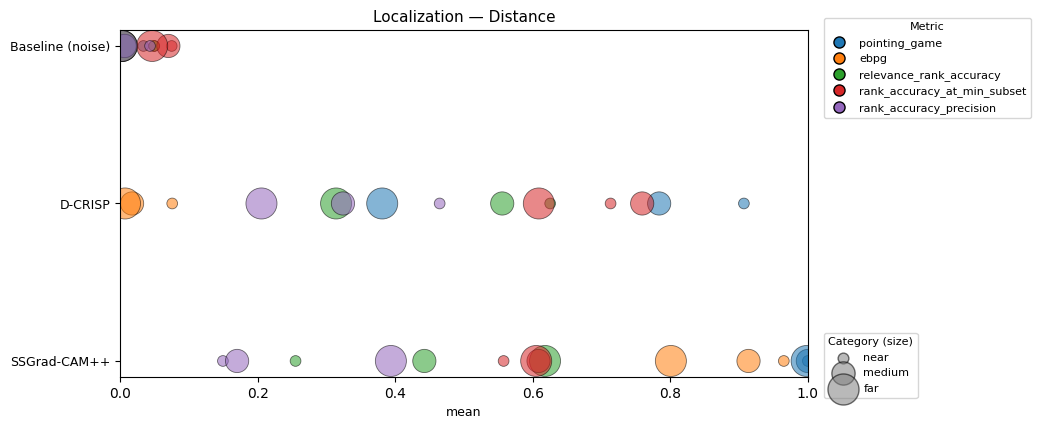

Saved -> results/final/figures/Localization_Distance.png


In [74]:
render_family_table(master, "Localization", "Distance")

### Análisis: Localización por distancia (near N=3302, medium N=2567, far N=1144, missing[false_positive] N=995, missing[other] N=43; total 8051)

**0. Estructura de este desglose — distinta a las cinco categorías de Tamaño**

Este desglose tiene 5 grupos, no 3: además de `near`/`medium`/`far` (los tres tramos de distancia real), incluye dos categorías `missing`: `false_positive` (N=995, 12.4% de la población) y `other` (N=43, 0.5%). `missing (false_positive)` corresponde a detecciones sin una caja GT emparejada (no hay una distancia real que asignar, al no existir el objeto) y `missing (other)` a casos donde la distancia no pudo calcularse por otro motivo.

El grupo `missing (other)` tiene solo N=43 (0.5%): cualquier estadístico aquí es mucho más ruidoso que en el resto de grupos y debe leerse con cautela. De hecho, `pointing_game` de Baseline en ese grupo tiene media=0.0 y std=0.0 (ningún objeto del baseline acertó, algo plausible con N=43), lo que hace que `improvement_vs_baseline_pct` quede indefinido (división por cero) y aparezca en blanco.

**1. `pointing_game`: SSGrad-CAM++ se mantiene casi perfecto en todas las distancias; D-CRISP colapsa de forma monótona y sustancial al aumentar la distancia**

| | near | medium | far | missing(fp) | missing(other) |
|---|---|---|---|---|---|
| SSGrad-CAM++ | 1.000 | 1.000 | 0.998 | 0.996 | 1.000 |
| D-CRISP | 0.907 | 0.784 | 0.381 | 0.421 | 0.256 |
| Baseline | 0.034 | 0.004 | 0.0009 | 0.009 | 0.0 |

SSGrad-CAM++ confirma, por un eje distinto (distancia en vez de tamaño), el mismo patrón ya visto en el desglose por Tamaño: su localización gruesa (acierto del píxel máximo) es prácticamente insensible a la dificultad del caso, manteniéndose en 0.996-1.000 en los cinco grupos.

D-CRISP, en cambio, se degrada de forma marcada y monótona con la distancia dentro del eje real near→medium→far: 0.907→0.784→0.381, más de la mitad de su tasa de acierto se pierde entre objetos cercanos y lejanos. Las dos categorías `missing` (0.421 y 0.256) están en línea con esa misma tendencia descendente, incluso por debajo de "far" en el caso de `missing (other)`. Dado que los objetos lejanos ocupan típicamente muy pocos píxeles de la imagen, este resultado es coherente con la hipótesis ya planteada para el eje Tamaño: los bloques de máscara de RISE/MFPP en D-CRISP tienen una resolución espacial que no se adapta a cajas muy pequeñas, y para una caja lejana/diminuta el pico de atribución agregado puede "desbordarse" ligeramente fuera de sus límites incluso si la región general señalada es correcta, un fallo que un criterio todo-o-nada como `pointing_game` penaliza con dureza, a diferencia de métricas de ranking más tolerantes a un desplazamiento fino del pico.

**2. `ebpg`: el patrón de D-CRISP aquí reconfirma el artefacto de energía difusa ya documentado**

| | near | medium | far | missing(fp) | missing(other) |
|---|---|---|---|---|---|
| SSGrad-CAM++ | 0.965 | 0.914 | 0.801 | 0.818 | 0.873 |
| D-CRISP | 0.076 | 0.017 | 0.007 | 0.016 | 0.017 |
| Baseline | 0.050 | 0.007 | 0.0025 | 0.009 | 0.007 |

D-CRISP mantiene su ventaja sobre el baseline en los cinco grupos, pero su valor absoluto cae de forma pronunciada con la distancia (0.076→0.017→0.007, una caída de ~10× entre near y far). La brecha absoluta frente al baseline también se estrecha en el mismo sentido (0.026→0.010→0.005 entre near y far) — a diferencia de lo visto en `ebpg` por Tamaño (donde la brecha absoluta crecía), aquí tanto el valor bruto como la brecha confirman la misma dirección de deterioro. Esto es exactamente la manifestación, ahora por distancia, del artefacto ya documentado: cuanto menor es la caja (los objetos pequeños no tinen por qué ser lejanos pero normalmente los objetos lejanos son pequeños), mayor es la fracción de energía de atribución que (al estar D-CRISP construido por promediado de máscaras dispersas por toda la imagen) queda fuera de la caja, diluyendo el numerador de EBPG.

**3. Cruce (crossover) entre SSGrad-CAM++ y D-CRISP en las tres métricas de ranking fino — D-CRISP domina en objetos cercanos, SSGrad-CAM++ domina en lejanos**

| Métrica | near | medium | far | missing(fp) | missing(other) |
|---|---|---|---|---|---|
| `relevance_rank_accuracy` SSGC | 0.255 | 0.442 | **0.618** | 0.503 | 0.393 |
| `relevance_rank_accuracy` D-CRISP | **0.625** | 0.556 | 0.314 | 0.300 | 0.172 |
| `rank_accuracy_at_min_subset` SSGC | 0.558 | 0.608 | 0.605 | **0.613** | 0.513 |
| `rank_accuracy_at_min_subset` D-CRISP | **0.713** | **0.759** | 0.609 | 0.577 | 0.405 |
| `rank_accuracy_precision` SSGC | 0.149 | 0.170 | **0.394** | **0.364** | 0.121 |
| `rank_accuracy_precision` D-CRISP | **0.465** | **0.324** | 0.206 | 0.190 | 0.142 |

Las tres métricas de ranking fino muestran el mismo patrón cualitativo, comparando directamente las medias brutas de ambos métodos entre sí: D-CRISP es netamente superior a SSGrad-CAM++ en objetos cercanos, la ventaja se reduce en medium, y se invierte en far/missing (SSGrad-CAM++ pasa a liderar). Que las tres coincidan en el mismo cruce es un buen indicio de coherencia interna, además de ser exactamente lo que cabría esperar de la relación ya establecida entre estas tres métricas: al compartir el mismo numerador/denominador subyacente, es natural que se muevan de forma correlacionada.

Esta reversión no puede explicarse invocando una correspondencia simétrica "cercano≈grande / lejano≈pequeño": el cruce real (`Size_Distance`) muestra que `far` es, en efecto, 100% objetos pequeños (far≈pequeño es casi exacto), pero `near` sigue siendo mayoritariamente pequeño también (62.6%), solo concentra una fracción moderadamente mayor de medianos (27.2%) y grandes (10.2%) que cualquier otro grupo de distancia. No es que "near" sea el grupo de los objetos grandes; es el único grupo con una presencia no despreciable de medianos/grandes mezclados con una base todavía mayoritariamente pequeña.

Dado que SSGrad-CAM++ ya degrada su ranking de forma desproporcionada en medianos/grandes (Localización por Tamaño), basta con que `near` concentre el 37.4% de objetos medianos/grandes de la muestra para que su media se vea arrastrada a la baja, sin que la mayoría *individual* de sus objetos sea grande. El patrón observado (SSGrad-CAM++ peor en near, mejor en far) es, por tanto, compatible con el hallazgo de Tamaño, pero por una vía de composición poblacional (más medianos/grandes mezclados en near) y no por una equivalencia directa near=grande.

**Esta aparente tensión se resuelve, no solo se señala, al usar la composición real.** Tanto `near` (62.6% pequeño) como `far` (100% pequeño) están dominados por objetos pequeños, la diferencia entre ambos grupos NO es "grande vs. pequeño", sino la presencia minoritaria de medianos/grandes en near. Por tanto, la ventaja de Fidelidad de D-CRISP en objetos pequeños (vista en Tamaño) no puede, por sí sola, predecir que D-CRISP sea más fuerte en `far`: como `far` y `near` son ambos mayoritariamente pequeños, "tamaño de caja" no es la variable que organiza la ventaja de ranking de D-CRISP en este eje. Su fortaleza en `near`/debilidad en `far` debe depender de algo genuinamente ligado a la distancia real (profundidad, escala de la escena, densidad de contexto), no de un proxy de tamaño de caja, un mecanismo distinto e independiente del que gobierna su ventaja de Fidelidad. Ambas ventajas de D-CRISP (Fidelidad por tamaño de caja; ranking fino por distancia real) coexisten sin contradecirse porque dependen de ejes distintos, no del mismo.

**Síntesis parcial:** este CSV aporta dos líneas de evidencia nuevas de primer orden: (a) la robustez de `pointing_game` para SSGrad-CAM++ y su fuerte fragilidad en D-CRISP se extiende, ahora confirmada, al eje distancia, con una degradación de D-CRISP mucho más severa que la vista en cualquier otra métrica de este bloque; (b) existe un cruce sistemático y consistente entre ambos métodos en las tres métricas de ranking fino, coherente con (aunque no formalmente probado contra) el hallazgo de Tamaño de que SSGrad-CAM++ empeora en objetos grandes/cercanos y mejora en pequeños/lejanos, mientras que D-CRISP muestra el patrón inverso en estas métricas de ranking, en aparente tensión con su propio patrón (mejor en pequeño) ya visto en Fidelidad. Ambos puntos deberían tenerse en cuenta al construir la síntesis conjunta de Distancia.

Fidelidad

Saved -> results/final/tables/Fidelity_Distance.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
near,deletion_auc,SSGrad-CAM++,3302,0.4160,0.4848,0.2000,-646.3%
near,deletion_auc,D-CRISP,3302,0.0790,0.0429,0.0926,-41.7%
near,deletion_auc,Baseline (noise),3302,0.0557,0.0480,0.0306,—
near,insertion_auc,SSGrad-CAM++,3302,0.7126,0.8268,0.2346,+25.1%
near,insertion_auc,D-CRISP,3302,0.8162,0.8961,0.1759,+43.3%
near,insertion_auc,Baseline (noise),3302,0.5697,0.5872,0.2660,—
near,minimal_subset,SSGrad-CAM++,3302,0.5122,0.5862,0.2254,-458.7%
near,minimal_subset,D-CRISP,3302,0.1106,0.0690,0.1117,-20.7%
near,minimal_subset,Baseline (noise),3302,0.0917,0.0690,0.0440,—
near,min_subset_k_pixels_exact,SSGrad-CAM++,3302,71783.1905,83685.0000,33208.4498,-566.8%


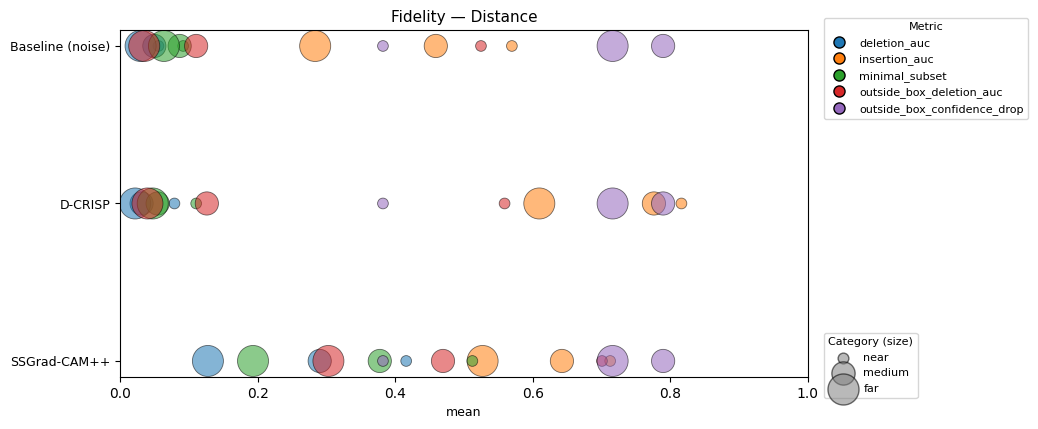

Saved -> results/final/figures/Fidelity_Distance.png


In [75]:
render_family_table(master, "Fidelity", "Distance")

### Análisis: Fidelidad por distancia (near N=3302, medium N=2567, far N=1144, missing[fp] N=995, missing[other] N=43)

**1. `deletion_auc` / `minimal_subset` / `min_subset_k_pixels_exact` (se mueven juntas, como ya establecido): confirman desde un eje independiente el hallazgo de Tamaño — peor para objetos cercanos/grandes, mejor para lejanos/pequeños**

| `deletion_auc` (valor bruto) | near | medium | far | missing(fp) | missing(other) |
|---|---|---|---|---|---|
| SSGrad-CAM++ | 0.416 | 0.290 | **0.128** | 0.211 | 0.198 |
| D-CRISP | 0.079 | 0.031 | **0.022** | 0.032 | 0.028 |
| Baseline | 0.056 | 0.050 | 0.030 | 0.031 | 0.025 |
| Brecha SSGC−baseline | 0.360 | 0.240 | **0.098** | 0.180 | 0.174 |
| Brecha D-CRISP−baseline | +0.023 (peor) | -0.019 (mejor) | -0.008 (mejor) | +0.001 | +0.003 |
| `improvement_vs_baseline_pct` | -646.3% | -482.8% | -328.7% | -585.4% | -707.4% |

A lo largo del eje real near→medium→far, tres métricas coinciden en la misma tendencia, confirmada tanto por valor bruto como por brecha absoluta: el valor absoluto de `deletion_auc` de SSGrad-CAM++ cae de forma monótona y sustancial (0.416→0.290→0.128, una reducción real del 69%), y su brecha frente al baseline se reduce en la misma proporción (0.360→0.240→0.098). La desventaja de SSGrad-CAM++ frente al ruido genuinamente se reduce al aumentar la distancia, no es un artefacto de normalización. `minimal_subset` reproduce el mismo patrón: SSGC -458.7%→-336.0%→-203.2%, con brecha bruta decreciente en paralelo (0.420→0.291→0.130).

D-CRISP pasa de perder frente al baseline en objetos cercanos (brecha +0.023, peor; -41.7%) a superarlo claramente en medium/far (brecha -0.019/-0.008, mejor; +37.3%/+26.5%).

Esto es coherente con el hallazgo ya establecido en el desglose por Tamaño, pero con una salvedad cuantitativa importante: el cruce real (`Size_Distance`) muestra que `near` no es "el grupo de los objetos grandes" (sigue siendo 62.6% pequeño), sino el único grupo con una fracción no trivial de medianos/grandes (37.4% combinado, frente a ≤3.5% en el resto). Que la fidelidad y la localización de ranking fino apunten en la misma dirección respecto al eje distancia es evidencia de que la fracción minoritaria pero sistemáticamente mayor de objetos medianos/grandes en `near` es suficiente para arrastrar su media, no de que "cercano" y "grande" sean intercambiables.

`min_subset_k_pixels_exact` confirma la misma historia en términos absolutos, sin ninguna tasa de mejora involucrada: SSGrad-CAM++ necesita 71 783 px en near frente a solo 24 454 en far (ratio sobre baseline: 6.67× en near, 3.67× en far — la penalización se reduce a más de la mitad), y D-CRISP pasa de necesitar más píxeles que el baseline en near (13 435 vs 10 765, ratio 1.25×) a necesitar bastantes menos en medium/far (4 803 vs 10 056, ratio 0.48×; 3 413 vs 6 665, ratio 0.51×).

**2. `insertion_auc`: no muestra fragilidad — al contrario, la ventaja sobre el baseline CRECE con la distancia, para ambos métodos, confirmado por valor bruto y por brecha absoluta**

| | near | medium | far | missing(fp) | missing(other) |
|---|---|---|---|---|---|
| SSGC (valor bruto) | 0.713 | 0.642 | 0.527 | 0.451 | 0.350 |
| D-CRISP (valor bruto) | 0.816 | 0.776 | 0.610 | 0.528 | 0.492 |
| Baseline (valor bruto) | 0.570 | 0.459 | 0.284 | 0.288 | 0.290 |
| Brecha SSGC−baseline | 0.143 | 0.183 | **0.244** | 0.163 | 0.060 |
| Brecha D-CRISP−baseline | 0.247 | 0.317 | **0.326** | 0.240 | 0.202 |
| % SSGC / D-CRISP | +25.1%/+43.3% | +39.9%/+69.1% | +85.8%/+114.9% | +56.8%/+83.5% | +20.4%/+69.6% |

**3. `outside_box_confidence_drop`: réplica solo parcial del patrón de Tamaño — el eje distancia no es un sustituto perfecto del eje tamaño para esta métrica**

| | near | medium | far | missing(fp) | missing(other) |
|---|---|---|---|---|---|
| Valor (idéntico en las 3 filas) | 0.382 | **0.790** | 0.716 | 0.597 | 0.613 |

Recordatorio: al ser estructuralmente independiente del heatmap (confirmado de nuevo aquí, idéntico en las tres filas de cada grupo), esta métrica refleja una propiedad del detector, no del método explicativo.

`near` es, en efecto, el valor más bajo (0.382) de los tres grupos de distancia real, coherente con que near concentra la mayor fracción de medianos/grandes de los cinco grupos (37.4%, frente a ≤3.5% en el resto), aunque siga siendo mayoritariamente pequeño y con el hallazgo de Tamaño de que los objetos grandes dependen menos del contexto exterior (large=0.105 en esa tabla). Sin embargo, a diferencia de Tamaño (donde la caída era monótona y suave: 0.667→0.199→0.105), aquí `medium` (0.790) es en realidad el valor MÁS ALTO de los tres, por encima incluso de `far` (0.716) — el orden no es monótono. Esto indica que distancia y tamaño, aunque correlacionados, no son intercambiables para esta métrica concreta: la dependencia del contexto exterior del detector parece depender de algo más que del tamaño aparente del objeto —posiblemente de la composición típica del fondo a cada distancia (un objeto a media distancia puede estar rodeado de un contexto de escena más rico/informativo que uno muy cercano, que a menudo ocupa casi toda la imagen y deja poco fondo que borrar)— y no debe generalizarse la conclusión de Tamaño a este eje sin esta salvedad explícita.

*Nota metodológica:* el mismo razonamiento del bloque de Tamaño aplica aquí, porque un objeto
más lejano ocupa típicamente menos área en la imagen que uno cercano. Parte de la mejora de
estas tres métricas en objetos lejanos frente a cercanos puede deberse a que el objeto ocupa
una fracción menor del fotograma de tamaño fijo sobre el que se borra, y no únicamente a una
explicación de mayor calidad. Las comparaciones entre métodos dentro de una misma categoría de
distancia no se ven afectadas por esto.

**Síntesis parcial:** las métricas de fidelidad basadas en `deletion` (deletion_auc, minimal_subset, min_subset_k_pixels_exact) confirman con fuerza, desde un eje de estratificación diferente, el patrón central ya identificado en Tamaño: SSGrad-CAM++ empeora y D-CRISP pierde su ventaja sobre el ruido en la condición "cercano/grande", mejorando ambos en "lejano/pequeño". En cambio, `outside_box_confidence_drop` solo replica parcialmente el patrón de Tamaño (near sí es el más bajo, pero medium/far no siguen un orden monótono), lo que es un recordatorio útil de que "distancia" y "tamaño" son ejes correlacionados pero no equivalentes, y conviene no asumir automáticamente que todo hallazgo de un desglose se traslada sin matices al otro.

Complejidad

Saved -> results/final/tables/Complexity_Distance.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
near,sparseness,SSGrad-CAM++,3302,0.9952,0.9956,0.0041,+350.7%
near,sparseness,D-CRISP,3302,0.1474,0.0937,0.1317,-33.2%
near,sparseness,Baseline (noise),3302,0.2208,0.2208,0.0005,—
medium,sparseness,SSGrad-CAM++,2567,0.9982,0.9987,0.0012,+352.0%
medium,sparseness,D-CRISP,2567,0.2001,0.1463,0.1430,-9.4%
medium,sparseness,Baseline (noise),2567,0.2208,0.2208,0.0005,—
far,sparseness,SSGrad-CAM++,1144,0.9986,0.9987,0.0006,+352.2%
far,sparseness,D-CRISP,1144,0.3282,0.2869,0.1574,+48.6%
far,sparseness,Baseline (noise),1144,0.2208,0.2208,0.0005,—
missing (false_positive),sparseness,SSGrad-CAM++,995,0.9980,0.9987,0.0020,+351.9%


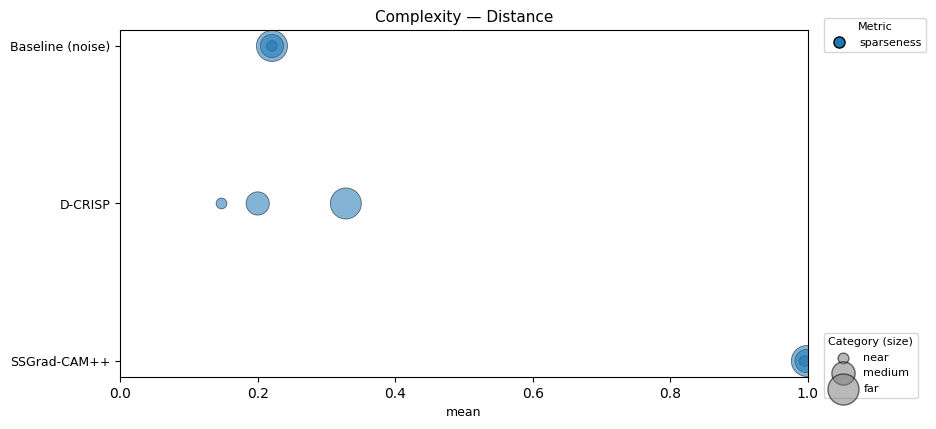

Saved -> results/final/figures/Complexity_Distance.png


In [76]:
render_family_table(master, "Complexity", "Distance")

### Análisis: Complejidad (sparseness) por distancia (near N=3302, medium N=2567, far N=1144, missing[fp] N=995, missing[other] N=43)

Única métrica de esta familia. El patrón de esta tabla confirma, a través de un tercer eje de estratificación independiente, los dos artefactos de sparseness ya documentados en Global y Tamaño.

**1. El baseline se mantiene invariante también respecto a la distancia**

0.22082 (near) / 0.22081 (medium) / 0.22082 (far) / 0.22085 (missing fp) / 0.22077 (missing other), con std≈0.0005 en todos los casos — coherente con que el heatmap del explicador aleatorio no depende de dónde ni a qué distancia esté el objeto, exactamente igual que se comprobó por tamaño.

**2. SSGrad-CAM++: réplica del suelo geométrico, con una magnitud más suave que en Tamaño**

| | near | medium | far | missing(fp) | missing(other) |
|---|---|---|---|---|---|
| SSGrad-CAM++ | 0.9952 | 0.9982 | 0.9986 | 0.9980 | 0.9982 |

El valor crece (muy ligeramente) al aumentar la distancia dentro del eje near→far, en la misma dirección que predice el suelo geométrico bajo la relación real de composición (near concentra la mayor fracción de medianos/grandes, 37.4%, frente a 0-3.5% en el resto de grupos, aunque siga siendo mayoritariamente pequeño; far es 100% pequeño). El rango de variación es mucho más estrecho aquí (0.9952-0.9986, amplitud 0.0034) que en el desglose directo por tamaño (0.986-0.998, amplitud 0.012), lo cual es razonable: el tamaño de la caja es la variable que determina directamente el suelo geométrico, mientras que la distancia solo es un correlato indirecto de ese tamaño, así que su efecto sobre esta métrica debe ser, como se observa, más atenuado.

**3. D-CRISP: la supresión por debajo del baseline es específicamente un fenómeno de objetos cercanos/grandes — para lejanos llega a SUPERAR al baseline**

| | near | medium | far | missing(fp) | missing(other) |
|---|---|---|---|---|---|
| D-CRISP (media) | 0.1474 | 0.2001 | 0.3282 | 0.2634 | 0.3957 |
| vs baseline | **-33.2%** | -9.4% | **+48.6%** | +19.3% | +79.3% |

Patrón monótono y claro a lo largo del eje real near→far, confirmado tanto por el valor bruto (0.147→0.200→0.328, subida real y monótona) como por el porcentaje: D-CRISP pasa de estar sustancialmente por debajo del baseline en objetos cercanos (-33.2%) a superarlo con holgura en objetos lejanos (+48.6%). Esto confirma, mediante un tercer eje de estratificación totalmente independiente del de Tamaño, el mismo hallazgo: la caída de sparseness de D-CRISP por debajo del ruido es un fenómeno específico de objetos grandes/cercanos, no una propiedad general del método. De hecho, aquí el efecto es incluso más marcado que en Tamaño (donde el grupo "small" solo igualaba al baseline, -0.17%, sin llegar a superarlo; aquí "far" lo supera claramente, +48.6%). Es coherente con la hipótesis ya propuesta (presupuesto fijo de máscaras que, para un objeto pequeño/lejano, ofrece una densidad de muestreo relativamente mayor sobre su propia área, permitiendo una atribución más concentrada).

Nota menor sobre la asimetría de la distribución (mean/mediana): la dispersión relativa de D-CRISP decrece con la distancia (ratio mean/mediana: 1.57 en near, 1.37 en medium, 1.14 en far), mientras que en el desglose por Tamaño el mismo ratio *aumentaba* con el tamaño del objeto (1.37→1.69→1.98 de small a large). Dado que near concentra más medianos/grandes que far (aunque ambos sean mayoritariamente pequeños), se podría esperar una dirección similar a la de Tamaño en ambos ejes; aquí no coincide exactamente. No contradice el hallazgo principal (que es consistente y robusto en la media), pero es un recordatorio de que distancia y tamaño son ejes correlacionados, no intercambiables, y de que esta particular característica secundaria de la distribución no se traslada de forma perfecta entre ambos.

**Síntesis parcial:** este CSV aporta una tercera confirmación independiente (tras Localización y Fidelidad por distancia) de que el eje "objeto grande/cercano vs. pequeño/lejano" es la variable subyacente que mejor organiza las fragilidades de ambos métodos: SSGrad-CAM++ se acerca más al suelo geométrico en objetos lejanos/pequeños (leve pero consistente), y D-CRISP recupera e incluso supera su ventaja de concentración sobre el ruido específicamente en esa misma condición, perdiéndola en objetos cercanos/grandes.

Robustez

Saved -> results/final/tables/Robustness_Distance.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
near,stability_max_sensitivity,SSGrad-CAM++,2950,11.2431,13.9000,7.5600,+92.7%
near,stability_max_sensitivity,Baseline (vs SSGrad-CAM++),3044,154.9805,154.9795,0.1586,—
near,stability_max_sensitivity,D-CRISP,577,57.0736,46.2157,35.2392,+63.1%
near,stability_max_sensitivity,Baseline (vs D-CRISP),2993,154.8281,154.8264,0.1783,—
near,stability_ris,SSGrad-CAM++,2950,0.0242,0.0199,0.0267,-966.3%
near,stability_ris,Baseline (vs SSGrad-CAM++),3044,0.0023,0.0006,0.0081,—
near,stability_ris,D-CRISP,577,0.0143,0.0000,0.1736,-613.4%
near,stability_ris,Baseline (vs D-CRISP),2993,0.0020,0.0006,0.0069,—
near,stability_ros,SSGrad-CAM++,2950,13261019243.6287,229513036.9853,158257899121.8225,-663.9%
near,stability_ros,Baseline (vs SSGrad-CAM++),3044,1736034509.6638,37652839.2999,17593502191.8901,—


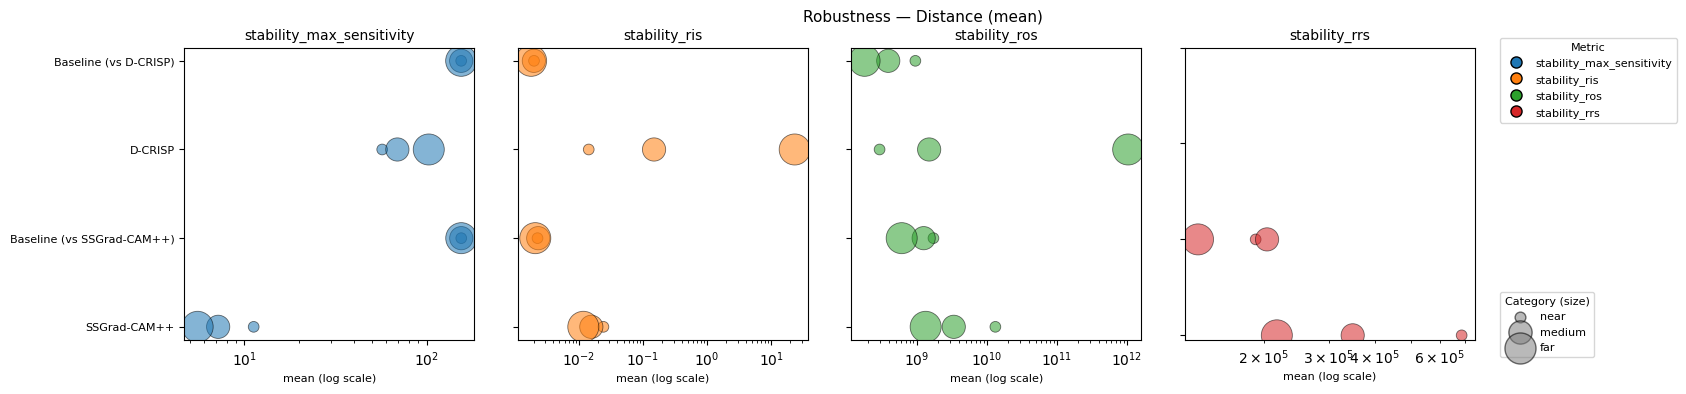

Saved -> results/final/figures/Robustness_Distance_mean.png


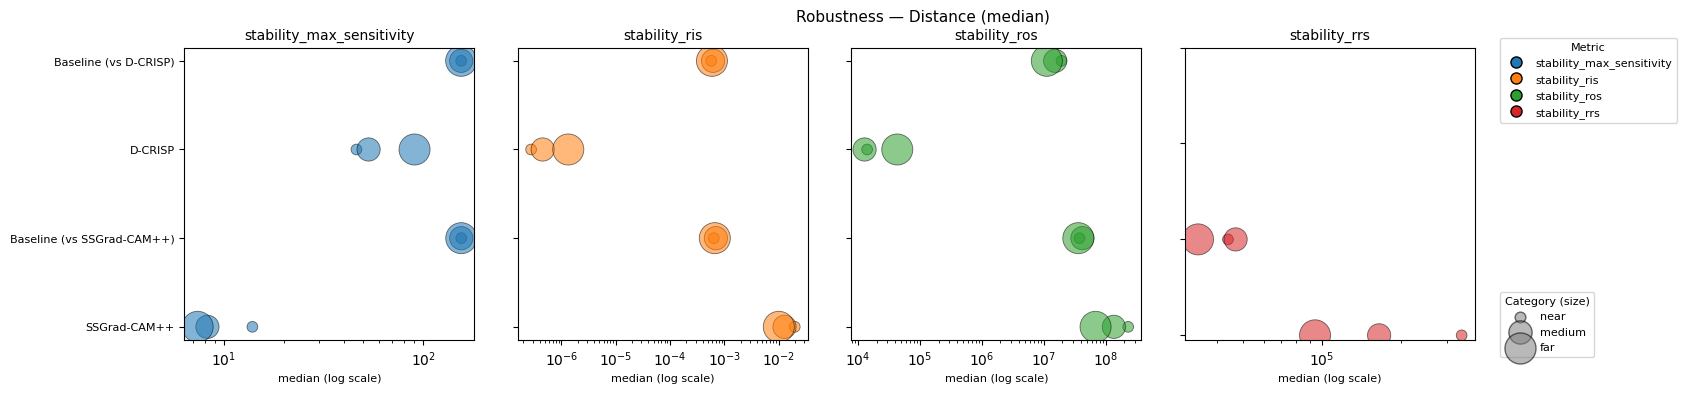

Saved -> results/final/figures/Robustness_Distance_median.png


In [77]:
render_family_table(master, "Robustness", "Distance")

### Análisis: Robustez por distancia (near N≈3044, medium N≈2479, far N≈1086, missing[fp] N≈799, missing[other] N≈37 — máximos por fila; ver tabla para N exactos por método)

**0. Advertencias de cobertura — leer antes de interpretar**

Las mismas dos limitaciones estructurales ya establecidas en Robustez por Tamaño reaparecen aquí, agravadas en el grupo `missing (other)`: la muestra propia de D-CRISP es sistemáticamente menor que la de su baseline (p.ej. far: 207 vs 1056; missing(fp): 137 vs 717), confirmando de nuevo que la comparación nunca está emparejada en población para D-CRISP. En `missing (other)`, D-CRISP tiene **N=4** para `stability_max_sensitivity`/`stability_ris`/`stability_ros` — una muestra puramente anecdótica; ningún estadístico de D-CRISP en ese grupo debe interpretarse como representativo.

**1. `stability_max_sensitivity`: SSGrad-CAM++ y D-CRISP se mueven en direcciones OPUESTAS con la distancia**

| (mediana) | near | medium | far | missing(fp) | missing(other) |
|---|---|---|---|---|---|
| SSGrad-CAM++ | 13.90 | 8.27 | 7.39 | 7.39 | 9.12 |
| % del baseline | 9.0% | 5.3% | 4.8% | 4.8% | 5.9% |
| D-CRISP | 46.22 | 53.17 | 90.39 | 83.15 | 113.01 (N=4) |
| % del baseline | 29.9% | 34.3% | 58.4% | 53.7% | 73.0% |

SSGrad-CAM++ mejora (baja) su inestabilidad absoluta al aumentar la distancia (13.90→8.27→7.39), coherente con que `near` concentra la mayor fracción de medianos/grandes (37.4%) de los cinco grupos con el hallazgo de Tamaño de que su sensibilidad absoluta empeora en objetos grandes.

D-CRISP, en cambio, EMPEORA de forma clara y monótona al aumentar la distancia (46.22→53.17→90.39, con muestras razonablemente grandes: 577/436/207), es decir, es más inestable en términos absolutos para objetos lejanos/pequeños. Esto es coherente con la propia tabla de Tamaño (donde D-CRISP tenía su valor más alto en "small", 61.14, aunque allí el patrón medium→large no era monótono) pero, gracias al mayor N y a la limpieza del eje distancia, aquí se ve con mucha más claridad: **los dos métodos tienen sensibilidades opuestas al tamaño/distancia en el eje absoluto**, SSGrad-CAM++ es más frágil en objetos grandes/cercanos, D-CRISP es más frágil en objetos pequeños/lejanos. Es un matiz importante que no puede extraerse de ninguna tabla Global ni de la tabla de Tamaño por sí sola con esta nitidez.

**2. RIS / ROS / RRS (vía mediana): la desventaja relativa de SSGrad-CAM++ frente a su baseline decrece de forma monótona y consistente al aumentar la distancia — tercera confirmación independiente del patrón de Tamaño**

Ratio mediana(SSGrad-CAM++)/mediana(su baseline):

| | near | medium | far | missing(fp) | missing(other) |
|---|---|---|---|---|---|
| RIS | 30.9× | 18.3× | 15.1× | 13.3× | 26.8× (N=27) |
| ROS | 6.1× | 3.2× | 1.9× | 1.5× | 8.6× (N=27) |
| RRS | 7.8× | 3.5× | 2.8× | 1.9× | 25.0× (N=27) |

En las tres métricas, el ratio decrece de forma monótona a lo largo del eje real near→far (RIS 30.9×→15.1×; ROS 6.1×→1.9×; RRS 7.8×→2.8×), y `missing(fp)` continúa la misma tendencia por debajo de far (RIS 13.3×, ROS 1.5×, RRS 1.9×) — cuatro puntos consecutivos, todos en la misma dirección.

Antes de interpretar esto como una señal real, comprobamos que no es un artefacto del baseline moviéndose: su mediana apenas varía entre near/medium/far (RIS: 0.00064→0.00070→0.00067; ROS: 37.65M→41.96M→36.03M; RRS: 43.87K→46.92K→33.74K). Y, en efecto, los valores brutos de SSGrad-CAM++ decrecen en la misma dirección que el ratio (RIS: 0.0199→0.0129→0.0101; ROS: 229.5M→134.8M→68.3M; RRS: 340.7K→165.2K→94.2K), confirmando que la tendencia es real y no un efecto del denominador. Dado que near concentra desproporcionadamente los objetos medianos/grandes (37.4% frente a ≤3.5% en el resto), esto reproduce con las tres métricas —y ahora con un tercer eje de estratificación diferente— exactamente la misma dirección que ya se documentó en Robustez por Tamaño (donde el ratio crecía con el tamaño: RIS 19.5×→49.3×, ROS 3.1×→11.2×, RRS 3.5×→10.3×, de small a large). Esta es la tercera vez, tras Localización y Fidelidad, que el eje distancia reproduce el hallazgo central de Tamaño, reforzando considerablemente la confianza en que "objeto grande/cercano" es la condición que degrada sistemáticamente la calidad y estabilidad de las explicaciones de SSGrad-CAM++.

**3. D-CRISP en RIS/ROS: el suelo `eps_min` produce aquí el artefacto más extremo observado hasta ahora en todo el proyecto**

Las medianas de D-CRISP en RIS/ROS vuelven a estar ancladas al suelo numérico en los tres grupos reales (RIS mediana ≈2.8·10⁻⁷ a 1.3·10⁻⁶; ROS mediana ≈1.2·10⁴ a 4.3·10⁴) — sin tendencia interpretable, igual que en Tamaño. Las medias, en cambio, producen las distorsiones porcentuales más extremas vistas en todo el benchmark: `stability_ris` para D-CRISP en "far" registra una media de 23.31 (mediana ≈1.3·10⁻⁶) y un `improvement_vs_baseline_pct` de -1 291 866% — más de un millón por ciento, generado casi con toda seguridad por uno o muy pocos objetos con denominador degenerado dentro de una muestra de solo 207. `stability_ros` en el mismo grupo llega a una media de 1.04·10¹² con -574 183%. Estas cifras no deben citarse en ningún resumen o conclusión sin acompañarlas explícitamente de la mediana correspondiente — es la manifestación más severa hasta ahora de la necesidad, ya establecida, de descartar las medias de RIS/ROS para D-CRISP como base de cualquier afirmación cuantitativa.

**Síntesis parcial:** este CSV aporta dos hallazgos de peso. Primero, una tercera confirmación independiente (tras Localización y Fidelidad por distancia) de que la degradación de SSGrad-CAM++ con objetos grandes/cercanos es sistemática y se extiende también al eje de robustez relativa (RIS/ROS/RRS vía mediana). Segundo, un hallazgo nuevo y propio de este desglose: en la métrica de estabilidad *absoluta* (`max_sensitivity`), SSGrad-CAM++ y D-CRISP muestran sensibilidades opuestas al tamaño/distancia — el primero empeora con objetos grandes/cercanos, el segundo con objetos pequeños/lejanos — un matiz relevante que conviene incorporar a la síntesis conjunta de Distancia y que no se detectaba con la misma claridad en el desglose por Tamaño.

Cobertura de robustez

Saved -> results/final/tables/Coverage_Distance.csv


group,metric,method,N,mean,median,std
near,stability_n_valid,SSGrad-CAM++,3302,79.2505,100.0000,35.9173
near,stability_n_valid,Baseline (vs SSGrad-CAM++),3302,86.9821,100.0000,30.9124
near,stability_n_valid,D-CRISP,644,85.6522,100.0000,32.8299
near,stability_n_valid,Baseline (vs D-CRISP),3302,86.9534,100.0000,31.4313
near,stability_n_rejected_gate,SSGrad-CAM++,3302,13.0179,0.0000,30.9124
near,stability_n_rejected_gate,Baseline (vs SSGrad-CAM++),3302,13.0179,0.0000,30.9124
near,stability_n_rejected_gate,D-CRISP,644,14.3478,0.0000,32.8299
near,stability_n_rejected_gate,Baseline (vs D-CRISP),3302,13.0466,0.0000,31.4313
near,stability_n_rejected_explain,SSGrad-CAM++,3302,7.7317,0.0000,20.2873
near,stability_n_rejected_explain,Baseline (vs SSGrad-CAM++),3302,0.0000,0.0000,0.0000


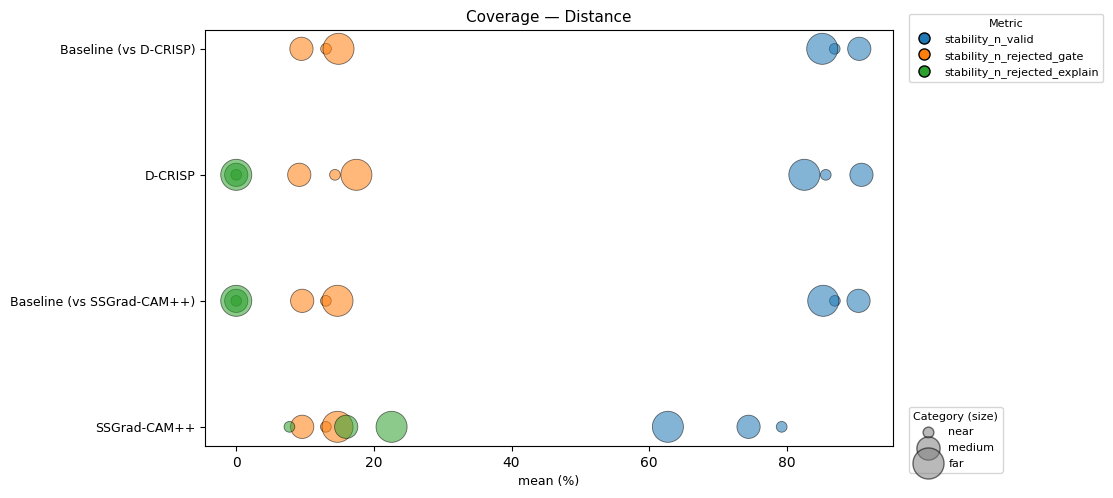

Saved -> results/final/figures/Coverage_Distance.png


In [78]:
render_family_table(master, "Coverage", "Distance")

### Análisis: Cobertura por distancia (near N=3302, medium N=2567, far N=1144, missing[fp] N=995, missing[other] N=43; D-CRISP con submuestra propia menor en cada grupo)

**1. La cobertura de SSGrad-CAM++ colapsa con la distancia — tercera confirmación independiente del hallazgo de Cobertura por Tamaño, aquí mucho más pronunciada**

| `stability_n_valid` (media / mediana) | near | medium | far | missing(fp) | missing(other) |
|---|---|---|---|---|---|
| SSGrad-CAM++ | 79.3% / 100 | 74.4% / 100 | 62.7% / **80** | 32.8% / **15** | 26.6% / **15** |
| D-CRISP | 85.7% / 100 | 90.8% / 100 | 82.5% / 100 | 55.8% / 80 | 22.0% / 0 (N=10) |
| Baseline | ~87% / 100 | ~90.5% / 100 | ~85% / 100 | ~58.5% / 75-80 | ~51.5% / 40-55 |

SSGrad-CAM++ muestra una caída de cobertura marcada y monótona a lo largo del eje near→far (79.3%→74.4%→62.7%), que se agudiza de forma dramática en las categorías `missing` (32.8% y 26.6% de media, con mediana de solo 15 en ambas). D-CRISP y ambos baselines también caen en las categorías `missing`, pero de forma mucho más moderada y partiendo de una base más alta (82-91% en near/medium/far); en `missing(fp)` los tres se mantienen en un rango similar (~52-58%), pero `missing(other)` es un caso aparte para D-CRISP (22.0% de media, mediana 0, con solo N=10 — ver punto 3) y no debe leerse como parte de ese mismo patrón moderado. SSGrad-CAM++ es, en cualquier caso, sistemáticamente el más afectado de los tres en cada grupo real.

Dado que near concentra la mayor fracción de medianos/grandes (37.4%, frente a ≤3.5% en el resto de grupos), esta caída (mejor cobertura en near/grande, peor en far/pequeño) es exactamente la misma dirección que el hallazgo ya documentado en Cobertura por Tamaño. Es la tercera vez, tras Localización y Fidelidad, que el eje distancia reproduce de forma independiente un patrón ya visto en Tamaño, en este caso, referido específicamente a la fiabilidad computacional del método, no a la calidad de la explicación.

**2. Descomposición: el paso `explain` es el principal responsable a lo largo del eje real near→far; el `gate` domina específicamente en las categorías `missing`**

| | near | medium | far | missing(fp) | missing(other) |
|---|---|---|---|---|---|
| `n_rejected_gate` (SSGC) | 13.0% | 9.6% | 14.7% | **41.5%** | **48.5%** |
| `n_rejected_explain` (SSGC) | 7.7% | 16.0% | **22.6%** | 25.7% | 24.9% |

A lo largo del eje near→far, el rechazo por fallo en `explain` crece de forma clara (7.7%→16.0%→22.6%), mientras que el `gate` se mantiene en un rango relativamente acotado (9.6%-14.7%) sin una tendencia tan marcada. Esto reproduce, en la dirección correspondiente, el hallazgo ya visto en Cobertura por Tamaño.

En las categorías `missing`, en cambio, el patrón cambia de naturaleza: el `gate` se dispara a 41.5% (falsos positivos) y 48.5% (otros), muy por encima de cualquier valor visto en el eje near-far real. Como el `gate` es heatmap-independiente, este salto no es atribuible a ningún método explicativo, sino a una propiedad de la propia población: los falsos positivos y los casos sin distancia 3D válida son, en conjunto, detecciones más frágiles (más propensas a perder su persistencia de clase+IoU bajo perturbación), lo cual es intuitivamente razonable.

**Síntesis parcial:** el hallazgo principal de este CSV es la caída de cobertura de SSGrad-CAM++ con la distancia, impulsada sobre todo por un aumento de fallos en el paso `explain`. Además, se identifica un hallazgo nuevo y de nivel-población (no de método): las categorías `missing` tienen una tasa de rechazo por `gate` mucho más alta que cualquier tramo de distancia real, indicando que se trata de detecciones estructuralmente más frágiles, compartido por igual entre métodos y baselines.

### Síntesis del bloque Distancia (near N=3302 [41.0%], medium N=2567 [31.9%], far N=1144 [14.2%], missing[false_positive] N=995 [12.4%], missing[other] N=43 [0.5%]; total 8051)

**Estructura del bloque:** a diferencia de Tamaño, este desglose tiene 5 grupos: un eje real de distancia (near/medium/far) más dos categorías `missing` (falsos positivos y casos sin distancia 3D válida) que no forman parte de ese continuo. Esta distinción es importante para toda la síntesis: los hallazgos que siguen una tendencia monótona clara aparecen sobre todo en el eje near→far; las categorías `missing` se comportan, en varias métricas, como poblaciones cualitativamente distintas, no como una simple extensión del extremo "far".

**1. Hallazgo central: el eje distancia confirma en cuatro de las cinco familias, el patrón "objeto grande/cercano = condición desfavorable" ya establecido en Tamaño**

El cruce real tamaño×distancia (`Size_Distance`, V=0.339) no es una correspondencia simétrica: `far`/`medium-distancia`/`missing` son ~99-100% objetos pequeños, mientras que `near`, aunque también mayoritariamente pequeño (62.6%), es el único grupo con una fracción sustancial de medianos (27.2%) y grandes (10.2%). La tabla que sigue debe leerse bajo esta relación de composición, no bajo una equivalencia near=grande:

| Familia | Métrica | Patrón en near→far | Coincide con Tamaño (grande↔pequeño) |
|---|---|---|---|
| Localización | `relevance_rank_accuracy`, `rank_accuracy_precision`, `rank_accuracy_at_min_subset` | Cruce: D-CRISP domina en near, SSGrad-CAM++ domina en far | Solo para SSGrad-CAM++; D-CRISP va en sentido contrario |
| Fidelidad | `deletion_auc`, `minimal_subset`, `min_subset_k_pixels_exact` | Desventaja de SSGrad-CAM++ se reduce con la distancia (brecha 0.360→0.098); D-CRISP pasa de perder a ganar al ruido | Sí |
| Complejidad | `sparseness` (D-CRISP) | Valor bruto sube de 0.147 (near) a 0.328 (far); pasa de −33.2% a +48.6% vs. baseline (el baseline es prácticamente constante, ~0.2208 en los cinco grupos, así que bruto y porcentaje cuentan la misma historia) | Sí |
| Robustez | `stability_ris/ros/rrs` (SSGrad-CAM++, vía mediana) | Ratio vs. baseline decrece monótonamente de near a far, confirmado también por los valores brutos de SSGrad-CAM++ | Sí |
| Cobertura | `stability_n_valid` (SSGrad-CAM++) | Cae de 79.3% (near) a 62.7% (far), impulsado por más fallos en `explain` | Sí |

Que cuatro de las cinco familias de métricas repliquen la misma dirección al pasar de un eje de estratificación (tamaño) a otro (distancia) correlacionado pero distinto es una evidencia sólida en apoyo de la hipótesis de fondo: SSGrad-CAM++ sufre una limitación estructural (rejilla de activación de resolución fija) que se manifiesta en objetos grandes/cercanos como pérdida de calidad de ranking, fidelidad y robustez, y en D-CRISP una limitación relacionada pero de mecanismo distinto (presupuesto de máscaras fijo) que le hace perder su ventaja sobre el ruido en esa misma condición, con la excepción explícita de Localización, donde D-CRISP se comporta al revés. Esta convergencia entre dos ejes de estratificación independientes reduce sustancialmente la probabilidad de que el hallazgo sea un artefacto de la forma concreta de agrupar por tamaño.

**2. Matices y disociaciones que el eje distancia revela y que Tamaño, por sí solo, no mostraba con la misma claridad**

- **D-CRISP: comportamiento opuesto según la familia de métrica — no hay una única regla de "mejor en pequeño, peor en grande" válida para todo el benchmark.** En Fidelidad y Complejidad, D-CRISP mejora o iguala al baseline específicamente en objetos lejanos/pequeños y pierde en cercanos/grandes, el patrón que domina el resto de esta síntesis. Pero en las tres métricas de ranking fino de Localización, ocurre justo lo contrario: D-CRISP domina claramente en near (`relevance_rank_accuracy` 0.625 en near frente a 0.314 en far) y pierde su ventaja al aumentar la distancia. Esta tensión ya se señaló, sin forzar una explicación única, en la celda de Localización por Distancia: la ventaja de D-CRISP en Fidelidad parece depender de que el objeto sea pequeño (mayor densidad de muestreo relativa sobre su propia área), mientras que su ventaja en el ranking fino de Localización depende de que sea grande (posiblemente porque una caja más grande deja más margen para que el pico de atribución, aunque impreciso, caiga dentro de ella). Ambos mecanismos son plausibles por separado, pero no está establecido cuál domina ni si son compatibles entre sí. Esta tensión se resuelve con el dato de composición: near y far son ambos mayoritariamente objetos pequeños (62.6% y 100%), así que el tamaño de caja no puede ser la variable que explica la ventaja de ranking de D-CRISP en near, debe depender de la distancia/profundidad real en sí, un mecanismo distinto del que gobierna su ventaja de Fidelidad (ligada al tamaño de caja, no a la distancia).

- **`pointing_game`: patrón propio, no una réplica del hallazgo central.** SSGrad-CAM++ se mantiene casi perfecto (0.996-1.000) en los cinco grupos, sin degradarse con la distancia. D-CRISP, en cambio, colapsa de forma monótona y muy pronunciada (0.907 near → 0.784 medium → 0.381 far). Este el hallazgo de fragilidad de D-CRISP con la distancia más marcado de todo el bloque, en una métrica de localización *gruesa* donde SSGrad-CAM++ es, precisamente, inmune al tamaño/distancia. Es un eje adicional de degradación de D-CRISP no capturado por el patrón "peor en grande, mejor en pequeño" que domina el resto de la síntesis.

- **`stability_max_sensitivity` (absoluta): los dos métodos se mueven en direcciones OPUESTAS.** SSGrad-CAM++ mejora (baja) su inestabilidad absoluta de near a far (13.90→7.39, mediana), mientras D-CRISP empeora (sube) en la misma dirección (46.22→90.39) — un patrón limpio y de N razonablemente grandes, más nítido que el visto en la tabla de Tamaño. Es un matiz genuinamente nuevo: en el eje absoluto, cada método tiene su propio "punto débil" de tamaño, en direcciones contrarias.

- **`insertion_auc`: mejora relativamente con la distancia** para ambos métodos (SSGC +25%→+86%; D-CRISP +43%→+115%, near→far).

- **`outside_box_confidence_drop`.** `near` es, como se esperaba, el valor más bajo (0.382, coherente con near≈grande), pero `medium` (0.790) y `far` (0.716) no seguían un orden monótono limpio como en Tamaño (donde la caída era suave y constante). Recordatorio de que distancia y tamaño, aunque correlacionados, no son intercambiables para todas las métricas.

**3. Confirmación metodológicas transversales, reforzadas por este bloque**

- El artefacto de suelo numérico `eps_min` en RIS/ROS de D-CRISP alcanzó aquí su caso más extremo de todo el proyecto (`stability_ris` en "far": mejora reportada de **−1 291 866%**, un valor sin ningún significado interpretable), reforzando de forma definitiva la regla ya establecida: nunca citar los porcentajes de mejora basados en media para RIS/ROS de D-CRISP sin acompañarlos de la mediana.

**4. Las categorías `missing` (falsos positivos y "otros") no son un extremo del eje distancia — son poblaciones estructuralmente más frágiles**

En Cobertura, el rechazo por `gate` en `missing (false_positive)` y `missing (other)` (41.5% y 48.5%) es muy superior a cualquier valor del eje real near-far (9.6%-14.7%), y este salto es compartido por igual entre métodos y baselines (heatmap-independiente) — indica que estas detecciones son, como población, intrínsecamente menos estables ante perturbación, coherente con tratarse en parte de detecciones espurias (falsos positivos) o de casos sin una geometría 3D fiable.

**Implicación práctica para la memoria:** este bloque no es redundante con el de Tamaño, aporta una validación cruzada independiente del hallazgo central (con cuatro de cinco familias de métricas coincidiendo en dirección para SSGrad-CAM++), a la vez que revela matices propios y no triviales: que D-CRISP no sigue una única regla de tamaño (mejora en pequeño/lejano en Fidelidad y Complejidad, pero al revés en el ranking fino de Localización), la fragilidad de `pointing_game` en D-CRISP con la distancia, la divergencia direccional de `max_sensitivity` entre ambos métodos, y la fragilidad estructural de las detecciones sin distancia calculable.

Por Correctness

Localización

Saved -> results/final/tables/Localization_Correctness.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
correct,pointing_game,SSGrad-CAM++,6935,0.9997,1.0000,0.0170,+5775.4%
correct,pointing_game,D-CRISP,6935,0.7761,1.0000,0.4169,+4461.0%
correct,pointing_game,Baseline (noise),6935,0.0170,0.0000,0.1293,—
correct,ebpg,SSGrad-CAM++,6935,0.9203,0.9776,0.1138,+3375.4%
correct,ebpg,D-CRISP,6935,0.0433,0.0213,0.0574,+63.4%
correct,ebpg,Baseline (noise),6935,0.0265,0.0090,0.0425,—
correct,relevance_rank_accuracy,SSGrad-CAM++,6935,0.3815,0.3457,0.2049,+1347.4%
correct,relevance_rank_accuracy,D-CRISP,6935,0.5492,0.6269,0.2528,+1983.4%
correct,relevance_rank_accuracy,Baseline (noise),6935,0.0264,0.0094,0.0425,—
correct,rank_accuracy_at_min_subset,SSGrad-CAM++,6935,0.5861,0.5825,0.2540,+751.5%


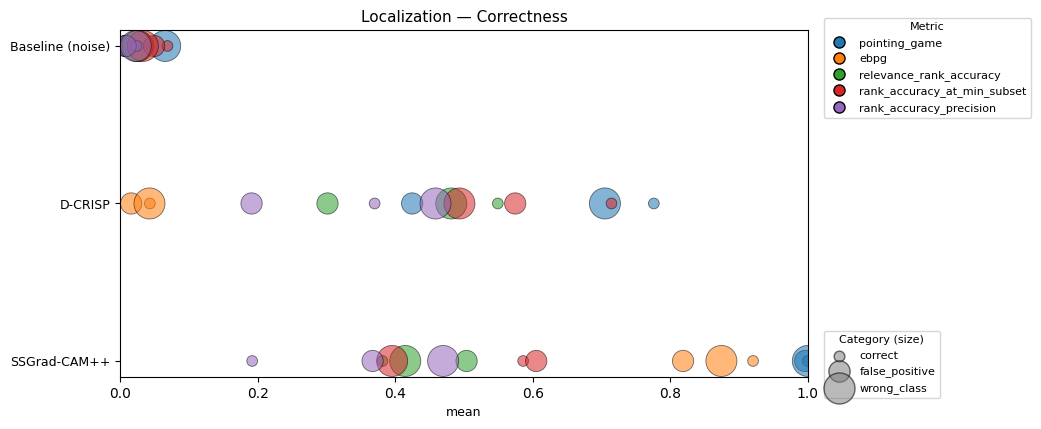

Saved -> results/final/figures/Localization_Correctness.png


In [79]:
render_family_table(master, "Localization", "Correctness")

### Análisis: Localización por corrección de la detección (correct N=6935, false_positive N=1055, wrong_class N=61)

**0. Estructura de este desglose**

Tres grupos, exhaustivos sobre la población (6935+1055+61=8051): `correct` (detección con clase e IoU correctos), `false_positive` (detección sin GT emparejado — un objeto "fantasma" del detector) y `wrong_class` (caja correctamente localizada pero con clase predicha incorrecta).

`wrong_class`, con solo N=61 (0.76% de la población), es un grupo muy pequeño: sus estadísticos deben leerse con más cautela que los de `correct`/`false_positive`.

**1. `pointing_game` y `ebpg`: SSGrad-CAM++ es indiferente a la corrección de la detección; D-CRISP se degrada específicamente en falsos positivos**

| | correct | false_positive | wrong_class |
|---|---|---|---|
| `pointing_game` SSGC | 0.9997 | 0.9962 | 1.000 |
| `pointing_game` D-CRISP | 0.776 | **0.425** | 0.705 |
| `ebpg` SSGC | 0.920 | 0.819 | 0.874 |
| `ebpg` D-CRISP | 0.0433 | **0.0161** | 0.0427 |

SSGrad-CAM++ se mantiene prácticamente perfecto en los tres grupos, confirmando de nuevo su insensibilidad a la dificultad/naturaleza del caso ya vista en Tamaño y Distancia. D-CRISP, en cambio, es marcadamente peor en `false_positive` que en `correct` o `wrong_class` en ambas métricas.

**2. `relevance_rank_accuracy`: el cruce entre métodos está impulsado específicamente por `false_positive`, no es un fenómeno general**

| | correct | false_positive | wrong_class |
|---|---|---|---|
| SSGC | 0.382 | **0.504** | 0.415 |
| D-CRISP | **0.549** | 0.302 | **0.482** |

D-CRISP supera a SSGrad-CAM++ tanto en `correct` como en `wrong_class` (objetos reales, con o sin la clase correcta), pero pierde claramente en `false_positive`, el único grupo sin un objeto real detrás de la caja. Esto da ventaja a D-CRISP frente a SSGrad-CAM++ ya que penaliza los errores del detector.

**3. `rank_accuracy_at_min_subset`: degradación COMPARTIDA por ambos métodos específicamente en `wrong_class`**

| | correct | false_positive | wrong_class |
|---|---|---|---|
| SSGC | 0.586 | 0.605 | **0.396** |
| D-CRISP | 0.715 | 0.574 | **0.493** |

Vuelve a darse el patrón de `relevance_rank_accuracy`, D-CRISP supera a SSGrad-CAM++ tanto en `correct` como en `wrong_class`, pero pierde en `false_positive`.

**4. `rank_accuracy_precision`: mejora aparente y dramática en `wrong_class` para ambos métodos — advertencia metodológica, no interpretar todavía**

| | correct | false_positive | wrong_class |
|---|---|---|---|
| SSGC | 0.192 | 0.367 | **0.470** |
| D-CRISP | 0.370 | 0.191 | **0.459** |

Ambos métodos alcanzan aquí su valor MÁS ALTO de toda la tabla en `wrong_class`, un patrón que, leído de forma aislada, sugeriría que la "precisión" del ranking mejora sustancialmente cuando la clase es incorrecta. Por la regla de interpretación conjunta ya establecida en el glosario (`rank_accuracy_precision` no debe leerse sin `rank_accuracy_at_min_subset` y, sobre todo, sin `min_subset_k_pixels_exact`, dado que la precisión puede subir mecánicamente si el `k` usado es pequeño, sin que exista una mejora real en la calidad del ranking), esta aparente mejora debe tratarse con cautela: como acabamos de ver en el punto 3, `rank_accuracy_at_min_subset` (el "recall") en realidad CAE para ambos métodos en `wrong_class`, lo cual es coherente con un `k` pequeño mecánicamente inflando la precisión sin una mejora genuina de localización. La conclusión firme sobre este punto queda pendiente hasta revisar `min_subset_k_pixels_exact`.

**Síntesis parcial:** este desglose introduce un eje de análisis distinto a Tamaño/Distancia (la corrección de la propia detección, no su tamaño o lejanía) y revela dos patrones nuevos y bien diferenciados: (a) D-CRISP, a diferencia de SSGrad-CAM++, depende de la existencia de un objeto real para producir explicaciones de calidad, degradándose de forma marcada y específica en falsos positivos; (b) ambos métodos por igual se degradan en clasificaciones incorrectas (`wrong_class`) en la métrica de recall (`rank_accuracy_at_min_subset`), aunque la aparente mejora de `rank_accuracy_precision` en ese mismo grupo requiere, por la propia metodología ya fijada, contrastarse con `min_subset_k_pixels_exact` antes de aceptarse como una mejora real.

Fidelidad

Saved -> results/final/tables/Fidelity_Correctness.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
correct,deletion_auc,SSGrad-CAM++,6935,0.3253,0.3555,0.2104,-556.3%
correct,deletion_auc,D-CRISP,6935,0.0525,0.0161,0.0743,-6.0%
correct,deletion_auc,Baseline (noise),6935,0.0496,0.0457,0.0319,—
correct,insertion_auc,SSGrad-CAM++,6935,0.6603,0.7172,0.2181,+35.9%
correct,insertion_auc,D-CRISP,6935,0.7715,0.8556,0.1962,+58.8%
correct,insertion_auc,Baseline (noise),6935,0.4859,0.4607,0.2672,—
correct,minimal_subset,SSGrad-CAM++,6935,0.4136,0.5172,0.2417,-384.2%
correct,minimal_subset,D-CRISP,6935,0.0802,0.0345,0.0900,+6.1%
correct,minimal_subset,Baseline (noise),6935,0.0854,0.0690,0.0443,—
correct,min_subset_k_pixels_exact,SSGrad-CAM++,6935,57235.6852,71049.0000,35810.7463,-480.2%


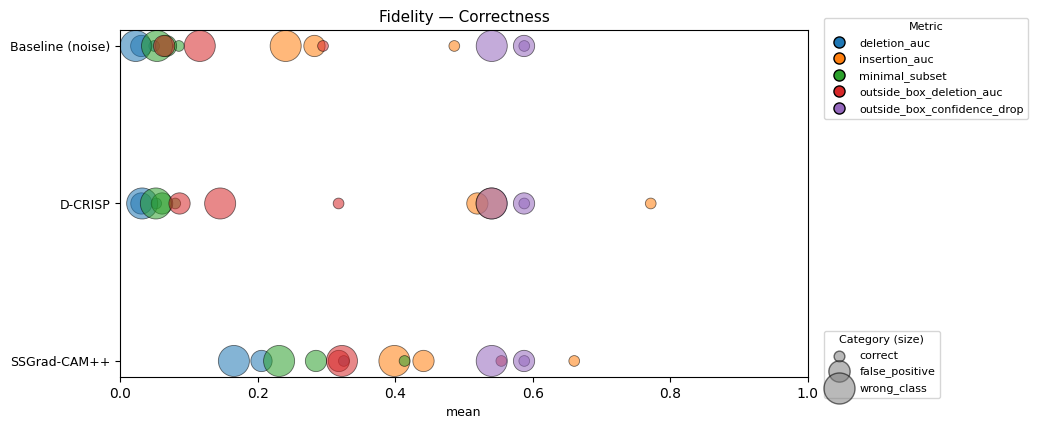

Saved -> results/final/figures/Fidelity_Correctness.png


In [80]:
render_family_table(master, "Fidelity", "Correctness")

### Análisis: Fidelidad por corrección de la detección (correct N=6935, false_positive N=1055, wrong_class N=61)

**1. Resolución de la advertencia pendiente de la celda anterior: la "mejora" de `rank_accuracy_precision` en `wrong_class` es, en efecto, mayormente mecánica**

| `min_subset_k_pixels_exact` (mediana) | correct | false_positive | wrong_class |
|---|---|---|---|
| SSGrad-CAM++ | 71 049 | 32 912 | **3 482** |
| D-CRISP | 3 717 | 2 548 | 1 563 |
| Baseline | 9 019 | 5 800 | 3 732 |

El `k` típico (mediana) de SSGrad-CAM++ cae de 71 049 píxeles en `correct` a solo 3 482 en `wrong_class` para SSGrad-CAM++, ya suficiente por sí sola para sostener la advertencia planteada en Localización por Corrección: buena parte de la "mejora" de `rank_accuracy_precision` en `wrong_class` es mecánica (k mucho menor), no una mejora genuina del ranking.

**2. La cifra de la tabla para SSGrad-CAM++ en `wrong_class` (basada en media) es en sí misma un artefacto de sesgo**

| `min_subset_k_pixels_exact` SSGrad-CAM++ | correct | false_positive | wrong_class |
|---|---|---|---|
| Media | 57 236 | 37 868 | **29 905** |
| Mediana | 71 049 | 32 912 | **3 482** |
| Ratio media/mediana | 0.81 | 1.15 | **8.59** |

En `wrong_class`, la media (29 905) es más de 8 veces la mediana (3 482), una asimetría muy superior a la de los otros dos grupos, y con una desviación típica (34 443) que incluso supera a la propia media. Esto indica que un pequeño número de objetos (N=61 en total) con un `k` extremadamente alto está arrastrando la media hacia arriba, mientras que el objeto típico de `wrong_class` necesita menos píxeles.

**3. Hallazgo central: las detecciones erróneas son más "frágiles", pierden confianza antes al borrar píxeles Y ganan menos confianza al insertarlos, incluso para el propio baseline aleatorio**

| (mediana) | correct | false_positive | wrong_class |
|---|---|---|---|
| `deletion_auc` — Baseline | 0.0457 | 0.0215 | 0.0149 |
| `deletion_auc` — SSGrad-CAM++ | 0.356 | 0.117 | 0.073 |
| `deletion_auc` — D-CRISP | 0.0161 | 0.0152 | 0.0142 |
| `min_subset_k_pixels_exact` — Baseline | 9 019 | 5 800 | 3 732 |
| `insertion_auc` — Baseline | 0.461 | 0.185 | 0.188 |
| `insertion_auc` — SSGrad-CAM++ | 0.717 | 0.420 | 0.393 |
| `insertion_auc` — D-CRISP | 0.856 | 0.508 | 0.567 |

El patrón es consistente y monótono (o casi) en las tres filas de cada dirección, y lo decisivo es que el **baseline lo replica igual que los dos métodos**: necesita borrar menos píxeles para hundir la confianza en `false_positive`/`wrong_class` (`deletion_auc` y `k` caen) y, en sentido contrario, recupera menos confianza al insertar píxeles en esas mismas categorías (`insertion_auc` cae). Como el baseline no usa ningún heatmap (borra o inserta en un orden aleatorio, sin ningún criterio sobre dónde está el objeto), este movimiento compartido solo puede explicarse por una propiedad de la propia detección, no del método explicativo: una detección falsa o con la clase equivocada descansa, por construcción, sobre una señal de confianza más débil y menos redundante que una detección correcta. De ahí que cualquier perturbación (acertada o al azar) la haga colapsar antes al borrar, y que reconstruirla al insertar píxeles cueste más, incluso llegando a un techo más bajo. Es, en efecto, un indicador razonable de que el detector "duda más" de estas detecciones desde el principio, aunque termine emitiéndolas.

SSGrad-CAM++ y D-CRISP replican el mismo patrón en las dos direcciones, lo cual es exactamente lo esperable si el efecto dominante es esta fragilidad de la detección y no algo específico de cada método explicativo. `min_subset_k_pixels_exact` de ambos métodos (ya visto en el punto 1: SSGC 71 049→32 912→3 482; D-CRISP 3 717→2 548→1 563) confirma la misma dirección desde una tercera métrica.

**4. Con la fragilidad ya establecida como causa principal: ¿siguen aportando valor los métodos frente al ruido, dentro de cada categoría?**

Aquí sí conviene mirar el ratio método/baseline — pero como pregunta *dentro* de cada categoría, nunca comparando el porcentaje resultante *entre* categorías, precisamente porque acabamos de ver que el baseline se mueve tanto como los métodos:

| Ratio `deletion_auc` (mediana), método/baseline | correct | false_positive | wrong_class |
|---|---|---|---|
| SSGrad-CAM++ | 7.78× (peor) | 5.47× (peor) | 4.94× (peor) |
| D-CRISP | 0.35× (mejor) | 0.71× (mejor) | 0.95× (mejor) |

Dentro de cada categoría, D-CRISP sigue superando al baseline en las tres, y SSGrad-CAM++ sigue siendo peor que el baseline en las tres. La conclusión cualitativa de la celda de Localización no cambia. Pero el margen de ambos se estrecha a medida que la detección es más frágil, y esto tiene ahora una explicación más directa que la simple "mejora/empeoramiento" de cada método: cuando hasta el borrado aleatorio hunde la confianza casi de inmediato (baseline `k`≈3 732 en `wrong_class` frente a 9 019 en `correct`), queda sencillamente menos margen para que cualquier método —bueno o malo— se diferencie del azar. No es tanto que D-CRISP pierda calidad explicativa o que SSGrad-CAM++ la gane, sino que la ventana de diferenciación disponible se estrecha por igual para ambos a medida que la detección es más frágil.

**5. `outside_box_confidence_drop`: sin variación relevante entre categorías de corrección**

0.588 (correct) / 0.587 (false_positive) / 0.540 (wrong_class), valores muy próximos entre sí.

**Síntesis parcial:** el hallazgo más sólido de este CSV es que las detecciones erróneas (`false_positive`, `wrong_class`) son intrínsecamente más frágiles ante cualquier perturbación (pierden confianza antes al borrar píxeles y la recuperan peor al insertarlos), y esto se confirma de la forma más convincente posible: el propio baseline de ruido, sin heatmap alguno, muestra exactamente el mismo patrón. Esto resuelve además, con un matiz importante, la duda dejada abierta por Localización por Corrección: la mejora de precisión en `wrong_class` es en gran parte mecánica (k mucho menor). Sobre esta base de fragilidad compartida, D-CRISP mantiene su ventaja sobre el ruido en las tres categorías y SSGrad-CAM++ mantiene su desventaja en las tres, pero el margen de ambos se estrecha en las detecciones más frágiles, no porque el método cambie de calidad, sino porque queda menos margen para diferenciarse del azar.

Complejidad

Saved -> results/final/tables/Complexity_Correctness.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
correct,sparseness,SSGrad-CAM++,6935,0.9968,0.9987,0.0033,+351.4%
correct,sparseness,D-CRISP,6935,0.1963,0.1346,0.1549,-11.1%
correct,sparseness,Baseline (noise),6935,0.2208,0.2208,0.0005,—
false_positive,sparseness,SSGrad-CAM++,1055,0.9980,0.9987,0.0020,+351.9%
false_positive,sparseness,D-CRISP,1055,0.2653,0.2231,0.1671,+20.1%
false_positive,sparseness,Baseline (noise),1055,0.2209,0.2209,0.0005,—
wrong_class,sparseness,SSGrad-CAM++,61,0.9962,0.9987,0.0047,+351.2%
wrong_class,sparseness,D-CRISP,61,0.2216,0.1975,0.1323,+0.4%
wrong_class,sparseness,Baseline (noise),61,0.2208,0.2208,0.0005,—


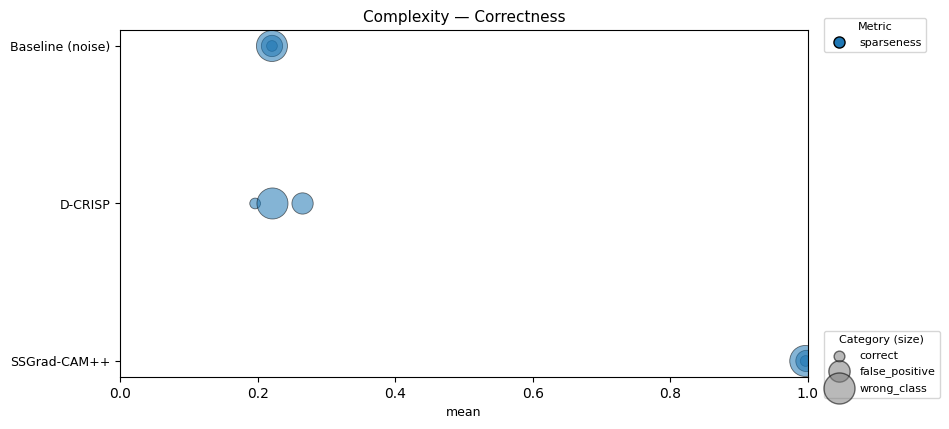

Saved -> results/final/figures/Complexity_Correctness.png


In [81]:
render_family_table(master, "Complexity", "Correctness")

### Análisis: Complejidad (sparseness) por corrección de la detección (correct N=6935, false_positive N=1055, wrong_class N=61)

Única métrica de esta familia.

**1. El baseline vuelve a ser invariante, ahora también respecto a la corrección de la detección**

0.22082 (correct) / 0.22085 (false_positive) / 0.22078 (wrong_class). Confirma, por cuarto eje de estratificación distinto (tras Global, Tamaño y Distancia), que el heatmap del explicador aleatorio no depende de ninguna propiedad del objeto ni de la detección.

**2. SSGrad-CAM++: la corrección de la detección apenas mueve el suelo geométrico**

| | correct | false_positive | wrong_class |
|---|---|---|---|
| SSGrad-CAM++ | 0.9968 | 0.9980 | 0.9962 |

Los tres valores están dentro de una banda muy estrecha (0.9962-0.9980, amplitud de solo 0.0018).

**3. D-CRISP: patrón de tres tramos — por debajo del baseline en `correct`, prácticamente igual en `wrong_class`, por encima en `false_positive`**

| | correct | false_positive | wrong_class |
|---|---|---|---|
| D-CRISP (media) | 0.1963 | 0.2653 | 0.2216 |
| vs. baseline | **-11.1%** | **+20.1%** | +0.4% (≈ nulo) |

`correct` (la población mayoritaria, N=6935) muestra a D-CRISP claramente por debajo del baseline, coherente con la hipótesis ya establecida de suavizado por promediado de máscaras.

El hallazgo más llamativo es `false_positive`: D-CRISP SUPERA al baseline (+20.1%), es decir, su atribución está más concentrada que el propio ruido aleatorio. Una hipótesis,sin verificación directa en el código de generación de máscaras: si la "detección" de un falso positivo se dispara por una combinación accidental y específica de píxeles (una textura, un patrón de sombra, un artefacto puntual), solo un subconjunto reducido y particular de máscaras de RISE/MFPP correlacionará con la persistencia de esa detección espuria, concentrando la atribución resultante en esa región concreta en vez de repartirla sobre un área del tamaño típico de un objeto real, lo que produciría, precisamente, una sparseness más alta de lo habitual.

**Síntesis parcial:** a diferencia de Tamaño y Distancia, donde sparseness mostraba gradientes claros y monótonos, la corrección de la detección apenas afecta al suelo geométrico de SSGrad-CAM++ pero sí produce un patrón de tres tramos bien diferenciado en D-CRISP, con el caso `false_positive` como el más distintivo: la única condición, de todas las estudiadas hasta ahora en el proyecto, en la que D-CRISP supera claramente al ruido en concentración de la atribución.

Robustez

Saved -> results/final/tables/Robustness_Correctness.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
correct,stability_max_sensitivity,SSGrad-CAM++,6243,8.8400,8.5481,6.5828,+94.3%
correct,stability_max_sensitivity,Baseline (vs SSGrad-CAM++),6558,154.9761,154.9746,0.1645,—
correct,stability_max_sensitivity,D-CRISP,1209,69.2240,53.5735,43.7657,+55.3%
correct,stability_max_sensitivity,Baseline (vs D-CRISP),6428,154.8222,154.8223,0.1838,—
correct,stability_ris,SSGrad-CAM++,6243,0.0191,0.0149,0.0223,-744.7%
correct,stability_ris,Baseline (vs SSGrad-CAM++),6558,0.0023,0.0007,0.0077,—
correct,stability_ris,D-CRISP,1209,4.0514,0.0000,124.7320,-205997.9%
correct,stability_ris,Baseline (vs D-CRISP),6428,0.0020,0.0006,0.0064,—
correct,stability_ros,SSGrad-CAM++,6243,7744373071.2819,151474246.2920,109875804629.7915,-460.8%
correct,stability_ros,Baseline (vs SSGrad-CAM++),6558,1380833006.5959,39084511.4615,14964502600.1754,—


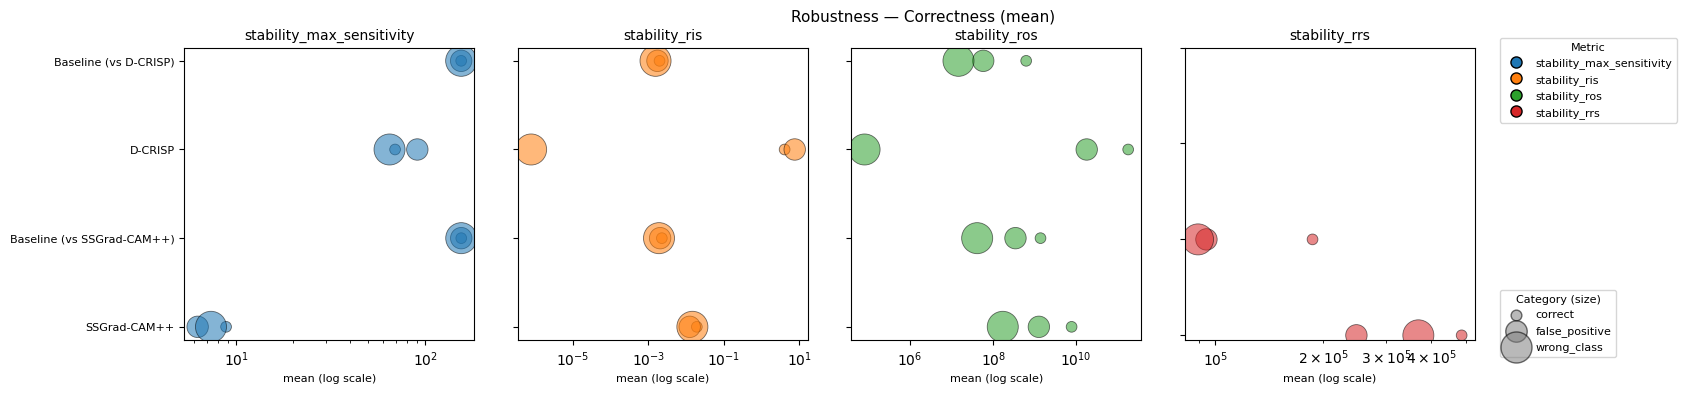

Saved -> results/final/figures/Robustness_Correctness_mean.png


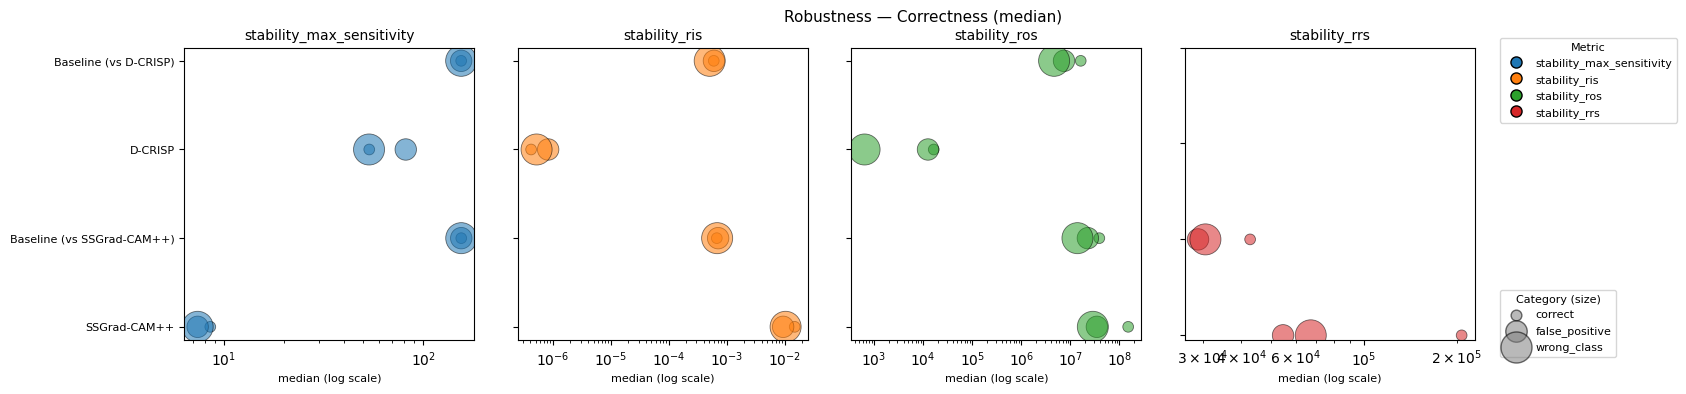

Saved -> results/final/figures/Robustness_Correctness_median.png


In [82]:
render_family_table(master, "Robustness", "Correctness")

### Análisis: Robustez por corrección de la detección (correct N≈6558, false_positive N≈845, wrong_class N≈42 — máximos por fila; D-CRISP con N mucho menor, ver tabla)

**0. Advertencia de cobertura — extrema en `wrong_class`**

D-CRISP tiene **N=4** en `wrong_class` para `stability_max_sensitivity`/`stability_ris`/`stability_ros`. Ningún estadístico de D-CRISP en ese grupo debe tratarse como representativo, sea cual sea su apariencia.

**1. `stability_max_sensitivity`: SSGrad-CAM++ apenas varía con la corrección; D-CRISP es notablemente más inestable específicamente en `false_positive`**

| (mediana) | correct | false_positive | wrong_class |
|---|---|---|---|
| SSGrad-CAM++ | 8.55 | 7.39 | 7.39 |
| D-CRISP | 53.57 | **81.66** | 53.45 (N=4) |

SSGrad-CAM++ se mantiene en un rango estrecho (7.4-8.6) en los tres grupos, reforzando —ahora desde el eje de robustez absoluta— el hallazgo ya visto en Complejidad de que la corrección de la detección no es una variable que module fuertemente el comportamiento de este método.

D-CRISP, en cambio, es claramente más inestable en `false_positive` (81.66) que en `correct` (53.57). Esto confirma, ahora en el eje de robustez, la misma vulnerabilidad ya documentada en Localización (pérdida de calidad de ranking) y coherente con Complejidad (donde `false_positive` era también el grupo más atípico para D-CRISP, aunque allí en la dirección de mayor concentración).

**2. RIS / ROS / RRS de SSGrad-CAM++ (vía mediana): `correct` muestra la PEOR robustez relativa, confirmado tanto por el ratio como por el valor bruto**

Ratio mediana(SSGrad-CAM++)/mediana(su baseline):

| | correct | false_positive | wrong_class |
|---|---|---|---|
| RIS | **22.2×** | 13.3× | 15.2× |
| ROS | **3.9×** | 1.5× | 2.1× |
| RRS | **4.9×** | 1.9× | 2.2× |

Antes de interpretar esto, comprobamos que no depende solo de cómo se mueve el baseline: en las tres métricas, el valor BRUTO de SSGrad-CAM++ también es el más alto (peor) en `correct` (RIS 0.0149; ROS 151.5M; RRS 207 816), muy por encima de `false_positive` y `wrong_class`. La conclusión "`correct` es la peor condición" no depende de la lente elegida.

El orden relativo ENTRE `false_positive` y `wrong_class`, en cambio, sí es sensible a esa elección en ROS: por valor bruto, `false_positive` es ligeramente peor que `wrong_class`.

A primera vista sorprende que `correct` tenga la desventaja relativa más alta en las tres métricas. Parte de la explicación es de composición, no de calidad: el cruce real tamaño×corrección (`Size_Correctness`) muestra que `correct` tiene una fracción de objetos medianos/grandes (13.3%+4.8%=18.1%) muy superior a la de `false_positive` (3.3%+0.8%=4.1%); `wrong_class`, en cambio, tiene una composición de tamaño muy similar a `correct` (14.8%+4.9%=19.7%). Como SSGrad-CAM++ empeora su RIS/ROS de forma pronunciada en medianos/grandes (Robustez por Tamaño), la mayor presencia de estos en `correct` frente a `false_positive` contribuye, al menos parcialmente, a que su ratio agregado sea peor en `correct`. Esto no es, sin embargo, una explicación completa: `wrong_class` tiene una composición de tamaño prácticamente igual a la de `correct` (incluso ligeramente más mediana/grande) pero muestra un ratio bastante menor (15.2× vs 22.2× en RIS) — la composición por tamaño explica la brecha `correct`/`false_positive`, pero no la brecha `correct`/`wrong_class`, que queda sin explicación mecanicista firme (y con N=61 en `wrong_class`, tampoco puede descartarse ruido de muestra).

**Síntesis parcial:** este CSV aporta dos hallazgos de peso: primero, una confirmación adicional (vía robustez absoluta) de que `false_positive` es la condición más adversa para D-CRISP, coherente con Localización y, en la dirección opuesta de concentración, con Complejidad; segundo, un hallazgo aparentemente paradójico: SSGrad-CAM++ muestra su peor robustez relativa precisamente en `correct`, confirmado tanto por el ratio como por el valor bruto.

Cobertura de robustez

Saved -> results/final/tables/Coverage_Correctness.csv


group,metric,method,N,mean,median,std
correct,stability_n_valid,SSGrad-CAM++,6935,75.1521,100.0000,36.7439
correct,stability_n_valid,Baseline (vs SSGrad-CAM++),6935,88.2927,100.0000,28.6042
correct,stability_n_valid,D-CRISP,1323,86.8934,100.0000,31.0328
correct,stability_n_valid,Baseline (vs D-CRISP),6935,88.3057,100.0000,29.2251
correct,stability_n_rejected_gate,SSGrad-CAM++,6935,11.7073,0.0000,28.6042
correct,stability_n_rejected_gate,Baseline (vs SSGrad-CAM++),6935,11.7073,0.0000,28.6042
correct,stability_n_rejected_gate,D-CRISP,1323,13.1066,0.0000,31.0328
correct,stability_n_rejected_gate,Baseline (vs D-CRISP),6935,11.6943,0.0000,29.2251
correct,stability_n_rejected_explain,SSGrad-CAM++,6935,13.1406,0.0000,25.0961
correct,stability_n_rejected_explain,Baseline (vs SSGrad-CAM++),6935,0.0000,0.0000,0.0000


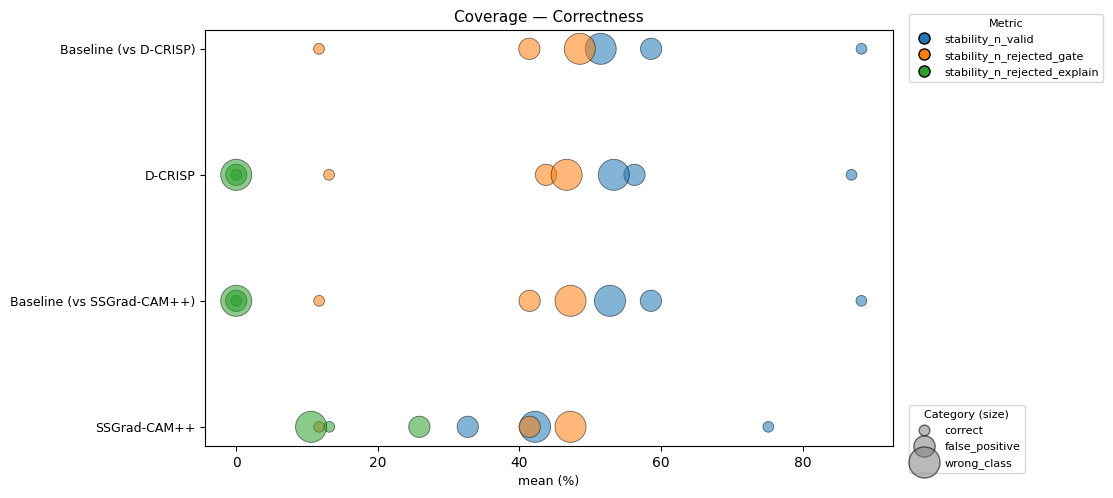

Saved -> results/final/figures/Coverage_Correctness.png


In [83]:
render_family_table(master, "Coverage", "Correctness")

### Análisis: Cobertura por corrección de la detección (correct N=6935, false_positive N=1055, wrong_class N=61; D-CRISP N=1323/208/6 respectivamente)

**0. Verificación de partición y advertencia de N**

D-CRISP tiene **N=6** en `wrong_class`, muestra puramente anecdótica, por lo que cualquier estadístico de D-CRISP en ese grupo debe tratarse con la máxima cautela.

**1. La cobertura de SSGrad-CAM++ colapsa con fuerza en los dos grupos "problemáticos". Tercera confirmación independiente (tras Tamaño y Distancia) de su menor fiabilidad computacional fuera de la condición estándar**

| `stability_n_valid` (media / mediana) | correct | false_positive | wrong_class |
|---|---|---|---|
| SSGrad-CAM++ | 75.2% / 100 | **32.7% / 15** | **42.2% / 20** |
| D-CRISP | 86.9% / 100 | 56.3% / 80 | 53.3% / 60 (N=6) |
| Baseline | ~88% / 100 | ~58.6% / 75-80 | ~52% / 45-60 |

SSGrad-CAM++ pasa de una cobertura razonable en `correct` (75.2%, ya por debajo del baseline) a un colapso severo en `false_positive` (32.7%) y `wrong_class` (42.2%) — una caída mucho más pronunciada que la de D-CRISP o cualquiera de los baselines, que se mantienen en un rango más moderado (52-59%) en esos mismos grupos. Es la tercera vez, tras Tamaño y Distancia, que se confirma (ahora desde un eje distinto, la corrección de la detección) que SSGrad-CAM++ es sistemáticamente el método con menor fiabilidad de cómputo en las condiciones más difíciles de la población.

**2. Descomposición: `false_positive` es "doblemente frágil" (gate + explain); `wrong_class` es frágil solo por `gate` — una distinción nueva y limpia entre ambos grupos problemáticos**

| SSGrad-CAM++ | correct | false_positive | wrong_class |
|---|---|---|---|
| `n_rejected_gate` | 11.7% | **41.4%** | **47.2%** |
| `n_rejected_explain` | 13.1% | **25.9%** | 10.6% |

El `gate` se dispara por igual en `false_positive` y `wrong_class` (41-47%, frente al 11.7% de `correct`), coherente con la idea, ya apuntada en Distancia, de que ambas son poblaciones de detecciones más frágiles/marginales frente a la perturbación, con independencia de si existe o no un objeto real detrás.

Es, de hecho, la misma fragilidad ya cuantificada en Fidelidad por Corrección (donde el propio baseline necesitaba menos píxeles para perder confianza y mostraba menor persistencia bajo perturbación en estos mismos dos grupos): aquí se manifiesta como una detección que directamente deja de superar el filtro de persistencia (`gate`) con mucha más frecuencia, la forma más directa posible de "fragilidad ante la perturbación".

El rechazo por fallo en `explain`, en cambio, se dispara SOLO en `false_positive`. Esta distinción es coherente y reveladora: el paso `explain` de SSGrad-CAM++ depende de encontrar una celda de anclaje/respuesta de activación asociada a un objeto real; en `false_positive` no existe tal objeto, por lo que ese cómputo falla con mayor frecuencia; en `wrong_class`, el objeto SÍ es real (solo la etiqueta es incorrecta), así que el cómputo del CAM tiene un ancla genuina y no muestra ninguna dificultad adicional. En conjunto: `false_positive` es una condición doblemente adversa para SSGrad-CAM++ (gate alto + explain alto), mientras que `wrong_class` lo es solo a través del `gate` (detección más frágil en general, pero con un objeto real que permite calcular la explicación sin problemas particulares).

**3. D-CRISP: declive más moderado, y confirmación de que su paso `explain` nunca falla, con independencia de la corrección de la detección**

En D-CRISP la caída de cobertura en `false_positive`/`wrong_class` (86.9%→56.3%/53.3%) está impulsada enteramente por el `gate`, igual que en el caso de `wrong_class` de SSGrad-CAM++, pero es proporcionalmente más moderada que la de SSGrad-CAM++.

**Síntesis parcial:** este CSV completa el cuadro de fragilidad de SSGrad-CAM++ ya perfilado en Localización, Fidelidad, Complejidad y Robustez por Corrección: no solo su calidad de explicación es indiferente a la corrección de la detección (como ya se vio en sparseness y max_sensitivity), sino que su fiabilidad *computacional* sí depende fuertemente de ella, y lo hace por dos mecanismos distinguibles: fallo de `gate` (compartido con todos los métodos, reflejo de la fragilidad intrínseca de la detección) y fallo de `explain` (específico de SSGrad-CAM++, y específico a su vez de la ausencia de un objeto real en `false_positive`).

### Síntesis del bloque Corrección (correct N=6935 [86.1%], false_positive N=1055 [13.1%], wrong_class N=61 [0.76%]; total 8051)

**Composición poblacional:** a diferencia de Tamaño y Distancia (donde cada grupo tenía un peso relativo comparable), aquí la población está dominada casi por completo por `correct` (86.1%). Cualquier conclusión de la tabla Global sobre "calidad media" de los métodos está, en la práctica, describiendo casi en exclusiva el comportamiento en detecciones correctas; los hallazgos de este bloque sobre `false_positive`/`wrong_class` son minoritarios en peso pero, como se ve a continuación, cualitativamente distintos y relevantes por derecho propio.

**1. Hallazgo central: `false_positive` y `wrong_class` no son una misma "condición difícil", son dos modos de fallo mecánicamente distintos**

| | `false_positive` (sin objeto real) | `wrong_class` (objeto real, etiqueta incorrecta) |
|---|---|---|
| D-CRISP — localización (`pointing_game`, `relevance_rank_accuracy`) | Colapsa (0.425; pierde el cruce con SSGC) | Se mantiene cerca de `correct` |
| D-CRISP — robustez absoluta (`max_sensitivity`) | Peor que en `correct` (81.7 vs 53.6) | Sin diferencia clara (N=4, no concluyente) |
| D-CRISP — complejidad (`sparseness`) | Supera al baseline (+20.1%, único caso en todo el proyecto) | Prácticamente igual al baseline (+0.4%) |
| SSGrad-CAM++ — cobertura, componente `gate` | Alto (41.4%) | Alto (47.2%) — **compartido** |
| SSGrad-CAM++ — cobertura, componente `explain` | Máximo de la tabla (25.9%) | Bajo, incluso menor que en `correct` (10.6%) |
| Ambos métodos — `rank_accuracy_at_min_subset` (recall) | Sin caída destacada | Cae con fuerza en ambos métodos |
| D-CRISP — `deletion_auc` (mediana, ratio frente a baseline) | Ventaja clara pero ya reducida (+29.3%, frente a +64.7% en `correct`) | Ventaja casi agotada (+4.8%, prácticamente empatado) — erosión progresiva a lo largo de los tres grupos, no un colapso puntual |

La tabla deja ver un patrón coherente, con un matiz importante entre familias de métricas: **`false_positive` es la condición que expone con más claridad la dependencia estructural de D-CRISP de tener un objeto real que correlacionar con el patrón de máscaras**  — en localización y en robustez absoluta, la degradación de D-CRISP es específica de `false_positive` y se recupera en `wrong_class`. En fidelidad (`deletion_auc`), en cambio, la ventaja de D-CRISP sobre el baseline se erosiona de forma progresiva a lo largo de los tres grupos, siendo ya notable en `false_positive` y casi total en `wrong_class`, un patrón relacionado pero de forma distinta, que no debe presentarse como si fuera exactamente el mismo fenómeno. SSGrad-CAM++, al depender del gradiente respecto a la caja detectada (real o no), no sufre esta degradación de calidad de ranking, pero sí ve fallar más a menudo el propio cómputo de su explicación (`explain`) en `false_positive`, presumiblemente porque no hay una respuesta de activación genuina en la que anclar la celda relevante.

**`wrong_class`, en cambio, no es un problema de "objeto inexistente" sino de "detección más frágil/marginal"**: el `gate` se dispara igual que en `false_positive`, pero el paso `explain` de SSGrad-CAM++ funciona con normalidad (hay un objeto real que anclar), y ambos métodos pierden recall de ranking fino, coherente con la hipótesis de que el CAM/ponderación calculados respecto a una clase incorrecta desplazan la atención hacia patrones asociados a esa clase equivocada en vez de al objeto real.

**2. Confirmaciones metodológicas transversales, con dos matices propios de este bloque**

- D-CRISP nunca tiene una población emparejada con su baseline, y en `wrong_class` su muestra cae a niveles extremos (N=4 en Robustez, N=6 en Cobertura), cualquier estadístico de D-CRISP en ese grupo es anecdótico.
- **Matiz propio de este bloque:** la corrección de la detección apenas mueve `sparseness` y `max_sensitivity` de SSGrad-CAM++. RIS/ROS/RRS sí se mueven de forma real (confirmado por valor bruto, no solo por ratio frente a baseline, descartando que sea un artefacto del denominador). Parte de este movimiento se explica por composición de tamaño: `correct` concentra una fracción de objetos medianos/grandes (18.1%) muy superior a la de `false_positive` (4.1%), y esos tamaños son justo los que degradan más la robustez relativa de SSGrad-CAM++ (Robustez por Tamaño). Pero la composición de tamaño de `wrong_class` es casi idéntica a la de `correct` (19.7% mediano/grande) y aun así muestra un ratio bastante mejor, así que la composición por tamaño no es una explicación completa — queda un residuo no explicado, compatible con cierta fragilidad genuina de la detección pero no verificado como tal. El efecto más dramático y menos ambiguo de este eje sobre SSGrad-CAM++ sigue siendo, con diferencia, su *fiabilidad computacional*. El eje que sí mueve con fuerza la calidad de un método (no solo su fiabilidad de cómputo) es la ausencia de objeto real (`false_positive`), y afecta específicamente a D-CRISP, no a SSGrad-CAM++.

**Implicación práctica para la memoria:** el bloque Corrección aporta un hallazgo que Tamaño y Distancia no podían mostrar por sí solos, una vulnerabilidad de D-CRISP genuinamente distinta (dependencia de que exista un objeto real) del mecanismo de resolución/tamaño ya establecido, y una distinción clara entre dos modos de fallo de SSGrad-CAM++ (fallo de cómputo por ausencia de anclaje vs. fragilidad general de la detección). Vemos que `false_positive`/`wrong_class` son detecciones intrínsecamente más frágiles ante cualquier perturbación, una propiedad que comparte el propio baseline aleatorio. Por ello, conviene presentar en la memoria el hallazgo de `false_positive` como una limitación metodológica de fondo (¿tiene sentido "explicar" con un método de perturbación aleatoria una detección que no corresponde a ningún objeto real?).

Por incertidumbre

Localización

Saved -> results/final/tables/Localization_Uncertainty.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
low,pointing_game,SSGrad-CAM++,2902,0.9986,1.0000,0.0371,+3663.6%
low,pointing_game,D-CRISP,2902,0.8253,1.0000,0.3798,+3010.4%
low,pointing_game,Baseline (noise),2902,0.0265,0.0000,0.1607,—
low,ebpg,SSGrad-CAM++,2902,0.9324,0.9987,0.1195,+2256.7%
low,ebpg,D-CRISP,2902,0.0584,0.0350,0.0631,+47.7%
low,ebpg,Baseline (noise),2902,0.0396,0.0176,0.0500,—
low,relevance_rank_accuracy,SSGrad-CAM++,2902,0.3243,0.2739,0.1937,+724.1%
low,relevance_rank_accuracy,D-CRISP,2902,0.5950,0.6831,0.2547,+1411.8%
low,relevance_rank_accuracy,Baseline (noise),2902,0.0394,0.0176,0.0500,—
low,rank_accuracy_at_min_subset,SSGrad-CAM++,2902,0.5955,0.5926,0.2369,+706.6%


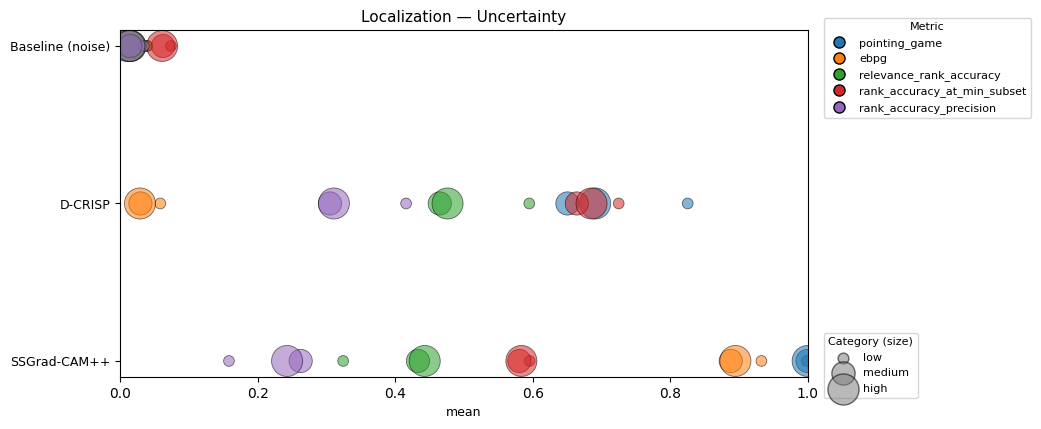

Saved -> results/final/figures/Localization_Uncertainty.png


In [84]:
render_family_table(master, "Localization", "Uncertainty")

### Análisis: Localización por incertidumbre (low N=2902, medium N=1951, high N=3198)

**0. Estructura de este desglose**

Tres grupos exhaustivos (2902+1951+3198=8051). El descenso monótono del propio `pointing_game` del baseline con la incertidumbre (0.0265 low → 0.0113 medium → 0.0103 high) sugiere que los objetos de mayor incertidumbre tienden a tener cajas más pequeñas o alejadas, es la señal indirecta habitual (el baseline no depende del heatmap, así que cualquier variación suya entre grupos refleja una diferencia real en el tamaño/posición de la caja, no en el método).

**1. `pointing_game`: SSGrad-CAM++ robusto de nuevo; D-CRISP muestra un patrón en U, no una caída monótona**

| | low | medium | high |
|---|---|---|---|
| SSGrad-CAM++ | 0.9986 | 0.9995 | 0.9997 |
| D-CRISP | 0.825 | **0.650** | 0.691 |
| Baseline | 0.0265 | 0.0113 | 0.0103 |

SSGrad-CAM++ se mantiene, una vez más, prácticamente perfecto en los tres niveles, confirmando su insensibilidad ya vista en Tamaño, Distancia y Corrección.

D-CRISP cae de 0.825 (low) a 0.650 (medium), pero luego se recupera parcialmente a 0.691 (high), un patrón en forma de U, no la caída monótona limpia observada en Distancia. La dirección general es coherente con la hipótesis de que mayor incertidumbre se asocia a cajas más pequeñas, pero el hecho de que "high" no sea el peor grupo (sino "medium") indica que la incertidumbre no es un sustituto perfecto de tamaño/distancia, hay algo en la composición del grupo "medium" que no encaja con una simple relación monótona.

**2. `ebpg`: D-CRISP sí decrece de forma monótona**

| | low | medium | high |
|---|---|---|---|
| SSGrad-CAM++ | 0.932 | 0.888 | 0.895 |
| D-CRISP | 0.0584 | 0.0295 | 0.0289 |
| Baseline | 0.0396 | 0.0162 | 0.0151 |

Aquí sí hay monotonía clara para D-CRISP (0.0584→0.0295→0.0289), con el baseline cayendo en paralelo, el patrón esperado del artefacto de energía difusa ya documentado, confirmado por cuarta vez de forma independiente (tras Global, Tamaño y Distancia).

**3. Ranking fino: D-CRISP mantiene el liderazgo en los tres niveles, pero la brecha se estrecha drásticamente**

| | low | medium | high |
|---|---|---|---|
| `relevance_rank_accuracy` SSGC | 0.324 | 0.433 | 0.443 |
| `relevance_rank_accuracy` D-CRISP | 0.595 | 0.465 | 0.476 |
| Diferencia (D-CRISP − SSGC) | +0.271 | +0.032 | +0.033 |
| `rank_accuracy_at_min_subset` SSGC | 0.595 | 0.581 | 0.583 |
| `rank_accuracy_at_min_subset` D-CRISP | 0.725 | 0.664 | 0.686 |
| Diferencia | +0.130 | +0.083 | +0.103 |
| `rank_accuracy_precision` SSGC | 0.158 | 0.263 | 0.243 |
| `rank_accuracy_precision` D-CRISP | 0.416 | 0.305 | 0.311 |
| Diferencia | +0.258 | +0.042 | +0.068 |

A diferencia de Distancia, donde SSGrad-CAM++ llegaba a superar a D-CRISP en `far`/`missing`, aquí D-CRISP conserva el liderazgo en los tres niveles de incertidumbre en las tres métricas. Sin embargo, la ventaja de D-CRISP se reduce de forma muy marcada al pasar de `low` a `medium`/`high` (por ejemplo, en `relevance_rank_accuracy` la diferencia cae de +0.271 a apenas +0.032-0.033, casi un orden de magnitud). Es una confirmación parcial del patrón central ya establecido (la ventaja de D-CRISP se erosiona en condiciones más difíciles) pero sin llegar a la inversión completa que sí se observaba en el eje distancia. Un matiz importante: la incertidumbre del modelo no es equivalente a la distancia/tamaño, aunque comparte la misma dirección de efecto.

Como ya ocurrió en Corrección con `wrong_class`, la subida de `rank_accuracy_precision` de SSGrad-CAM++ entre `low` (0.158) y `medium`/`high` (0.263/0.243) no debe interpretarse todavía como una mejora genuina de ranking: por la regla de interpretación conjunta ya establecida, esto podría deberse en parte a un `k` (`min_subset_k_pixels_exact`) menor en los grupos de mayor incertidumbre. Queda pendiente de confirmar.

**4. Patrón en U específico de D-CRISP, presente en 4 de las 5 métricas, explicado por la composición de `correctness` dentro de cada nivel de incertidumbre**

D-CRISP muestra el mismo patrón cualitativo (mejor en `low`, peor en `medium`, recuperación parcial en `high`) en `pointing_game`, `relevance_rank_accuracy`, `rank_accuracy_at_min_subset` y `rank_accuracy_precision`, solo `ebpg` es monótono. El cruce real `Correctness_Uncertainty` explica este patrón: la proporción de `false_positive` dentro de cada bin de incertidumbre no es monótona (12.7% (low), **19.1%** (medium), 9.8% (high)) sino que tiene su máximo precisamente en `medium`. Dado que `false_positive` es, con diferencia, la condición donde D-CRISP colapsa en localización (`pointing_game` 0.425 en `false_positive` frente a 0.776/0.705 en `correct`/`wrong_class`), un bin de incertidumbre con mayor concentración de falsos positivos arrastrará más la media de D-CRISP hacia abajo, con independencia de cómo se comporte en el resto de la población. `wrong_class` (donde D-CRISP se mantiene relativamente bien) se concentra al 65.6% en `high`, lo que ayuda a que `high` no colapse tanto como `medium` pese a tener menos objetos `correct` que `low`. La forma de U podría no reflejar, por tanto, una propiedad intrínseca de la incertidumbre del modelo sobre la localización de D-CRISP, sino un artefacto de que la composición de `correctness` (concretamente la tasa de falsos positivos) no varía de forma monótona con el nivel de incertidumbre.

**Síntesis parcial:** este primer CSV del bloque Incertidumbre confirma, de forma parcial, la misma dirección general ya vista en Tamaño, Distancia y Corrección (D-CRISP pierde ventaja de ranking fino en condiciones más difíciles; SSGrad-CAM++ es indiferente en `pointing_game`), pero introduce dos matices propios: la ventaja de D-CRISP se estrecha sin llegar a revertirse del todo, y aparece un patrón en U específico de D-CRISP explicado por la composición no monótona de `false_positive` dentro de los bins de incertidumbre (máximo en `medium`, no en `high`), no por una propiedad genuina de la incertidumbre del modelo.

Fidelidad

Saved -> results/final/tables/Fidelity_Uncertainty.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
low,deletion_auc,SSGrad-CAM++,2902,0.3959,0.4652,0.2103,-606.2%
low,deletion_auc,D-CRISP,2902,0.0701,0.0319,0.0915,-25.1%
low,deletion_auc,Baseline (noise),2902,0.0561,0.0483,0.0335,—
low,insertion_auc,SSGrad-CAM++,2902,0.7083,0.8161,0.2414,+27.5%
low,insertion_auc,D-CRISP,2902,0.7927,0.8952,0.2342,+42.7%
low,insertion_auc,Baseline (noise),2902,0.5557,0.5911,0.2898,—
low,minimal_subset,SSGrad-CAM++,2902,0.4796,0.5517,0.2406,-428.7%
low,minimal_subset,D-CRISP,2902,0.0999,0.0690,0.1100,-10.2%
low,minimal_subset,Baseline (noise),2902,0.0907,0.0690,0.0443,—
low,min_subset_k_pixels_exact,SSGrad-CAM++,2902,66952.6782,79147.0000,35551.0196,-532.6%


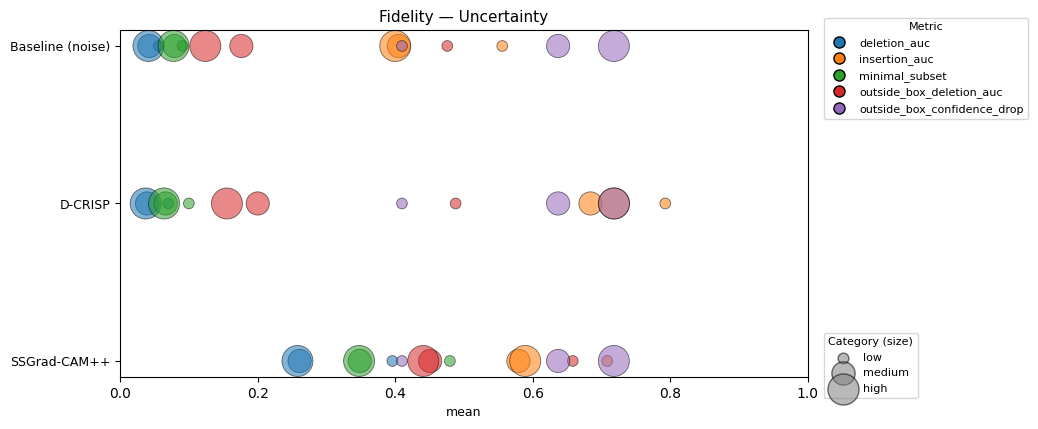

Saved -> results/final/figures/Fidelity_Uncertainty.png


In [85]:
render_family_table(master, "Fidelity", "Uncertainty")

### Análisis: Fidelidad por incertidumbre (low N=2902, medium N=1951, high N=3198)

**1. `min_subset_k_pixels_exact`: el `k` de SSGrad-CAM++ cae con la incertidumbre, pero de forma mucho más moderada que en `wrong_class`**

| `min_subset_k_pixels_exact` (mediana) | low | medium | high |
|---|---|---|---|
| SSGrad-CAM++ | 79 147 | 58 548 | 56 556 |

El `k` de SSGrad-CAM++ cae un ~26-29% de `low` a `medium`/`high` — una reducción real, pero muy inferior a la caída observada en `wrong_class` (Corrección).

**2. `deletion_auc` / `minimal_subset`: SSGrad-CAM++ es PEOR en `low` (no en `high`); D-CRISP pasa de perder a ganar al baseline — confirmado tanto por el ratio como por el valor bruto y la brecha absoluta**

| (valores brutos, media) | low | medium | high |
|---|---|---|---|
| `deletion_auc` SSGC | 0.396 | 0.261 | 0.258 |
| `deletion_auc` D-CRISP | 0.070 | 0.039 | 0.037 |
| `deletion_auc` Baseline | 0.056 | 0.043 | 0.041 |
| Brecha SSGC−baseline | 0.340 | 0.219 | 0.217 |
| Brecha D-CRISP−baseline | +0.014 (peor) | -0.003 (mejor) | -0.004 (mejor) |
| `improvement_vs_baseline_pct` SSGC | **-606.2%** | -513.6% | -525.2% |
| `improvement_vs_baseline_pct` D-CRISP | **-25.1%** | **+7.8%** | **+9.9%** |

El patrón se confirma con las tres lentes: el valor bruto de SSGrad-CAM++ es claramente peor (más alto) en `low` (0.396 frente a ~0.26 en medium/high, prácticamente iguales entre sí), su brecha absoluta frente al baseline se reduce a más de la mitad (0.340→0.217), y el porcentaje cuenta la misma historia. D-CRISP invierte de signo tanto en valor bruto (0.070 > baseline 0.056 en `low`; 0.039 < 0.043 en `medium`) como en brecha absoluta (+0.014→-0.003→-0.004). `minimal_subset` reproduce exactamente el mismo patrón en las tres lentes (SSGC bruto 0.480→0.349→0.348; brecha 0.389→0.269→0.270; D-CRISP brecha +0.009→-0.013→-0.014).

Dado que la incertidumbre `low` concentra una fracción sustancialmente mayor de objetos con cajas grandes (punto 1: mediana 8 065 px² frente a ~2 520 px²), aunque sin dejar de ser mayoritariamente pequeña por tamaño discreto (69.4% "small"), parte de esta diferencia es coherente con el patrón central ya establecido en Tamaño/Distancia: SSGrad-CAM++ empeora en la condición de objeto relativamente grande, y D-CRISP pierde su ventaja sobre el ruido en esa misma condición. Pero, como se muestra en el punto 5, esto no agota la explicación: hay un segundo mecanismo, independiente del tamaño, ligado directamente a la incertidumbre del modelo.

**3. `insertion_auc`: se mantiene robusto y su ventaja relativa crece con la incertidumbre — confirmado también por la brecha absoluta, no solo por el porcentaje**

| (valores brutos, media) | low | medium | high |
|---|---|---|---|
| SSGC | 0.708 | 0.579 | 0.589 |
| D-CRISP | 0.793 | 0.684 | 0.718 |
| Baseline | 0.556 | 0.405 | 0.400 |
| Brecha SSGC−baseline | 0.153 | 0.174 | 0.189 |
| Brecha D-CRISP−baseline | 0.237 | 0.279 | 0.318 |
| % SSGC / D-CRISP | +27.5%/+42.7% | +42.9%/+68.7% | +47.2%/+79.5% |

El baseline cae de forma notable de `low` a `medium`/`high` (0.556→0.400, -28%), así que conviene comprobar que el porcentaje creciente no es solo un efecto de ese descenso: la brecha absoluta también crece para ambos métodos (SSGC 0.153→0.189; D-CRISP 0.237→0.318), confirmando que el patrón es real y no un artefacto de la normalización. Igual que en Tamaño, Distancia y Corrección, la ventaja relativa sobre el ruido en la dirección insertion crece cuanto mayor es la incertidumbre, en vez de reducirse.

**4. `outside_box_confidence_drop`: crece de forma monótona con la incertidumbre**

| | low | medium | high |
|---|---|---|---|
| Valor | 0.410 | 0.637 | **0.718** |

A diferencia del desglose por Distancia (donde este valor no seguía un orden monótono limpio), aquí crece de forma perfectamente monótona con la incertidumbre (0.410→0.637→0.718). Esto es un indicio de que para detecciones con mayor incertidumbre el modelo se apoya en el contexto que rodea al objeto para su predicción.

**5. Fragilidad de la detección ligada a la incertidumbre**

El punto 2 atribuye parte de la mejora de `deletion_auc`/empeoramiento de `insertion_auc` con la incertidumbre al hecho de que `low` concentra cajas más grandes (punto 1). Para comprobar si esto agota la explicación, se cruza el baseline por objeto (sin heatmap, `results/final/random_baseline/eval_metrics.csv`) con `size_classify` y `uncertainty_classify` simultáneamente, fijando el tamaño y mirando solo el efecto de la incertidumbre dentro de cada estrato:

| `deletion_auc` baseline (media) | low | medium | high |
|---|---|---|---|
| dentro de `small` (N=2013/1780/2949) | 0.0556 | 0.0427 | 0.0418 |
| dentro de `medium` (N=633/137/195) | 0.0599 | 0.0419 | 0.0374 |
| dentro de `large` (N=256/34/54) | 0.0500 | 0.0351 | 0.0278 |

| `insertion_auc` baseline (media) | low | medium | high |
|---|---|---|---|
| dentro de `small` | 0.5042 | 0.3968 | 0.3981 |
| dentro de `medium` | 0.6775 | 0.5074 | 0.4407 |
| dentro de `large` | 0.6592 | 0.4422 | 0.3626 |

En las tres filas de tamaño, `deletion_auc` decrece de forma monótona con la incertidumbre y `insertion_auc` decrece también (con una meseta entre `medium` y `high` dentro de `small`, N grandes en ambos: 1780 y 2949). Como el baseline no usa ningún heatmap, esta variación no puede deberse a una explicación de mejor o peor calidad — y como el efecto persiste al fijar el tamaño, tampoco puede deberse (solo) a que los objetos de baja incertidumbre sean más grandes. Queda un mecanismo propio de la incertidumbre: una detección con mayor incertidumbre epistémica (`pixel_Ue_mean`) descansa sobre una señal de confianza menos redundante/estable, de modo que cualquier perturbación (dirigida o aleatoria) la hace colapsar antes al borrar píxeles (`deletion_auc` más bajo) y le cuesta más recuperar confianza al insertarlos (`insertion_auc` más bajo). Es el mismo patrón de "fragilidad de la detección" ya establecido en Fidelidad por Corrección para `false_positive`/`wrong_class`, aquí generalizado a un tercer eje (incertidumbre del modelo) y confirmado con un control explícito por tamaño que en Corrección no se había realizado.

Advertencia de N: los estratos `large` (34-256 objetos por celda) son bastante más ruidosos que `small`/`medium` (137-2949); la conclusión se apoya sobre todo en las filas `small` y `medium`, donde la monotonía es limpia y los tamaños de muestra son grandes en las tres columnas.

SSGrad-CAM++ y D-CRISP replican la misma dirección marginal en el punto 2 (bruto y brecha absoluta), coherente con que ambos heredan esta fragilidad de la detección subyacente además del efecto de tamaño ya conocido.

**Síntesis parcial:** este CSV aporta una tercera confirmación sólida, ahora desde un eje conceptualmente distinto (incertidumbre del modelo), del patrón central del proyecto: SSGrad-CAM++ y D-CRISP pierden fidelidad (dirección deletion) en la condición de objeto relativamente grande/confiado y la recuperan en la condición pequeño/incierto, mientras que la dirección insertion permanece robusta e incluso mejora relativamente (en ambos casos confirmado por valor bruto, brecha absoluta y porcentaje). Esta tabla revela además un segundo mecanismo, verificado controlando por tamaño real (punto 5): la incertidumbre del modelo se asocia, de forma independiente del tamaño de caja, con una fragilidad genuina de la detección subyacente (colapso más rápido al borrar, recuperación más lenta al insertar), reproducida por el propio baseline sin heatmap, el mismo fenómeno ya documentado en Fidelidad por Corrección para `false_positive`/`wrong_class`, ahora confirmado en un tercer eje y con un control de tamaño que refuerza su solidez.

Complejidad

Saved -> results/final/tables/Complexity_Uncertainty.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
low,sparseness,SSGrad-CAM++,2902,0.9960,0.9957,0.0040,+351.0%
low,sparseness,D-CRISP,2902,0.1561,0.0974,0.1406,-29.3%
low,sparseness,Baseline (noise),2902,0.2208,0.2208,0.0005,—
medium,sparseness,SSGrad-CAM++,1951,0.9975,0.9987,0.0027,+351.7%
medium,sparseness,D-CRISP,1951,0.2299,0.1676,0.1644,+4.1%
medium,sparseness,Baseline (noise),1951,0.2208,0.2208,0.0005,—
high,sparseness,SSGrad-CAM++,3198,0.9975,0.9987,0.0024,+351.7%
high,sparseness,D-CRISP,3198,0.2357,0.1839,0.1582,+6.7%
high,sparseness,Baseline (noise),3198,0.2208,0.2208,0.0005,—


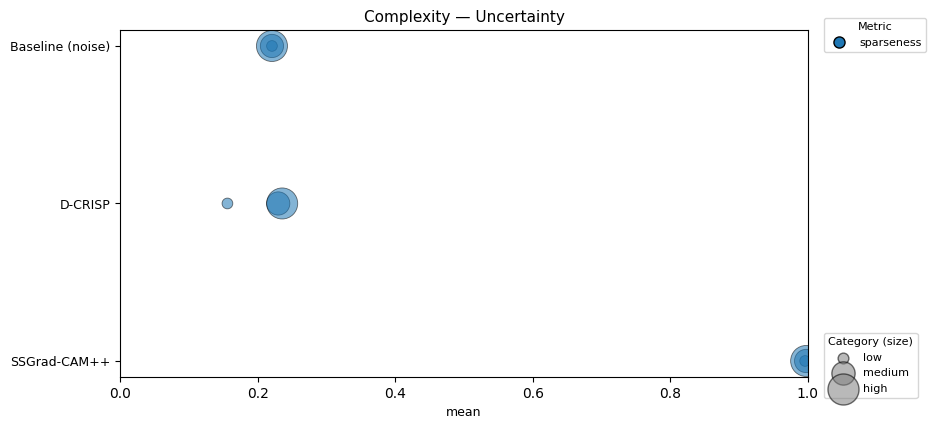

Saved -> results/final/figures/Complexity_Uncertainty.png


In [86]:
render_family_table(master, "Complexity", "Uncertainty")

### Análisis: Complejidad (sparseness) por incertidumbre (low N=2902, medium N=1951, high N=3198)

**1. Baseline invariante también respecto a la incertidumbre**

0.22083 (low) / 0.22081 (medium) / 0.22082 (high) quinta confirmación consecutiva (tras Global, Tamaño, Distancia y Correctness) de que el heatmap del explicador aleatorio no depende de ninguna propiedad del objeto ni de la confianza del modelo.

**2. SSGrad-CAM++: variación mínima**

| | low | medium | high |
|---|---|---|---|
| SSGrad-CAM++ | 0.9960 | 0.9975 | 0.9975 |

Aumenta ligeramente de `low` a `medium`/`high` (amplitud total de solo 0.0015).

**3. D-CRISP: por media parece "cruzar" al superar el baseline en `medium`/`high`, pero por mediana se queda siempre por debajo, solo que con la brecha cada vez más estrecha**

| | low | medium | high |
|---|---|---|---|
| D-CRISP (media) | 0.1561 | 0.2299 | 0.2357 |
| D-CRISP (mediana) | 0.0974 | 0.1676 | 0.1838 |
| vs. baseline, por media | **-29.3%** | +4.1% | +6.7% |
| vs. baseline, por mediana | **-55.9%** | **-24.1%** | **-16.7%** |

La mediana de D-CRISP es sustancialmente menor que su media en los tres grupos (ratio media/mediana: 1.60 en low, 1.37 en medium, 1.28 en high — el mismo patrón de cola derecha pesada y decreciente ya documentado en Distancia, donde el mismo ratio iba de 1.57 a 1.14 de near a far). Igual que se decidió para `stability_ris`/`stability_ros` y para sparseness por Tamaño, la mediana es aquí el estadístico más representativo del objeto típico. Y por mediana, la lectura cambia de forma cualitativa: D-CRISP nunca alcanza ni supera al baseline en ninguno de los tres grupos de incertidumbre — se queda sistemáticamente por debajo, pasando de una supresión severa en `low` (-55.9%) a una mucho más moderada en `high` (-16.7%). La versión "D-CRISP supera al ruido en objetos poco inciertos" que sí aparecía en Distancia (`far` +48.6% por media, y +29.9% por mediana — confirmado, con esa sí, en ambos estadísticos y sin cambio de signo) no se reproduce aquí: la incertidumbre acerca a D-CRISP al nivel del ruido, pero no llega a superarlo.

**Síntesis parcial:** el hallazgo más importante de este CSV: la tabla de `improvement_vs_baseline_pct` (basada en media) sugiere que D-CRISP supera al baseline en `medium`/`high`, pero la mediana muestra que D-CRISP se mantiene por debajo del baseline en los tres grupos, solo que cada vez más cerca.

Robustez

Saved -> results/final/tables/Robustness_Uncertainty.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
low,stability_max_sensitivity,SSGrad-CAM++,2521,9.4424,9.1163,7.6352,+93.9%
low,stability_max_sensitivity,Baseline (vs SSGrad-CAM++),2682,154.9678,154.9670,0.1664,—
low,stability_max_sensitivity,D-CRISP,499,58.7267,44.9443,38.8733,+62.1%
low,stability_max_sensitivity,Baseline (vs D-CRISP),2597,154.8180,154.8167,0.1863,—
low,stability_ris,SSGrad-CAM++,2521,0.0210,0.0160,0.0267,-773.5%
low,stability_ris,Baseline (vs SSGrad-CAM++),2682,0.0024,0.0007,0.0085,—
low,stability_ris,D-CRISP,499,1.1521,0.0000,23.1574,-53697.0%
low,stability_ris,Baseline (vs D-CRISP),2597,0.0021,0.0006,0.0073,—
low,stability_ros,SSGrad-CAM++,2521,13265023191.4817,204395811.2530,153383233674.0312,-427.1%
low,stability_ros,Baseline (vs SSGrad-CAM++),2682,2516491893.5416,53321204.7405,22904316779.1666,—


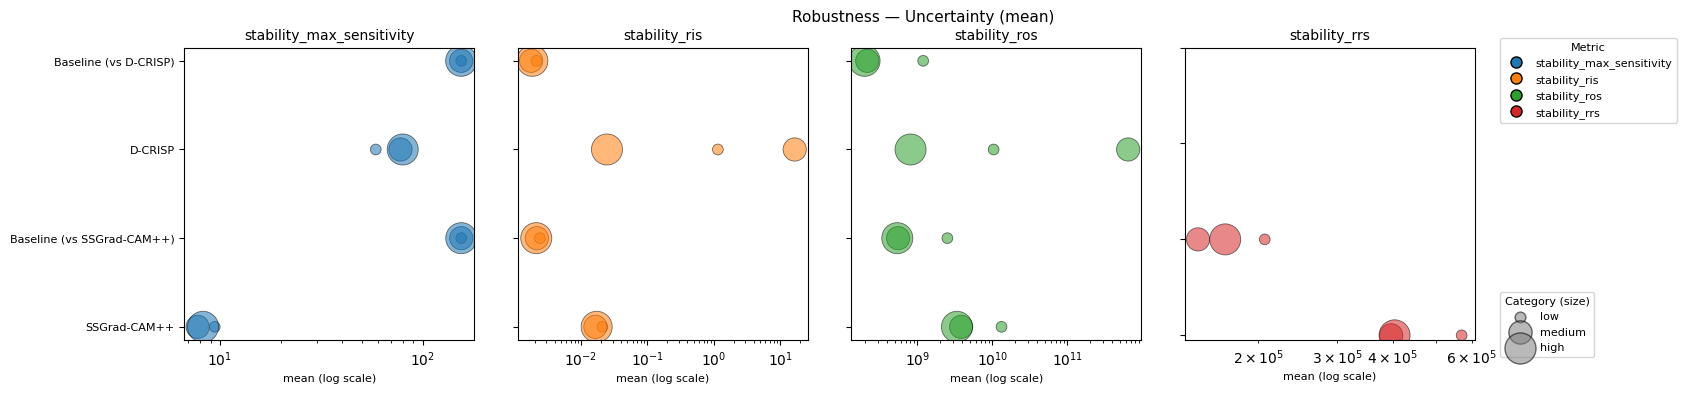

Saved -> results/final/figures/Robustness_Uncertainty_mean.png


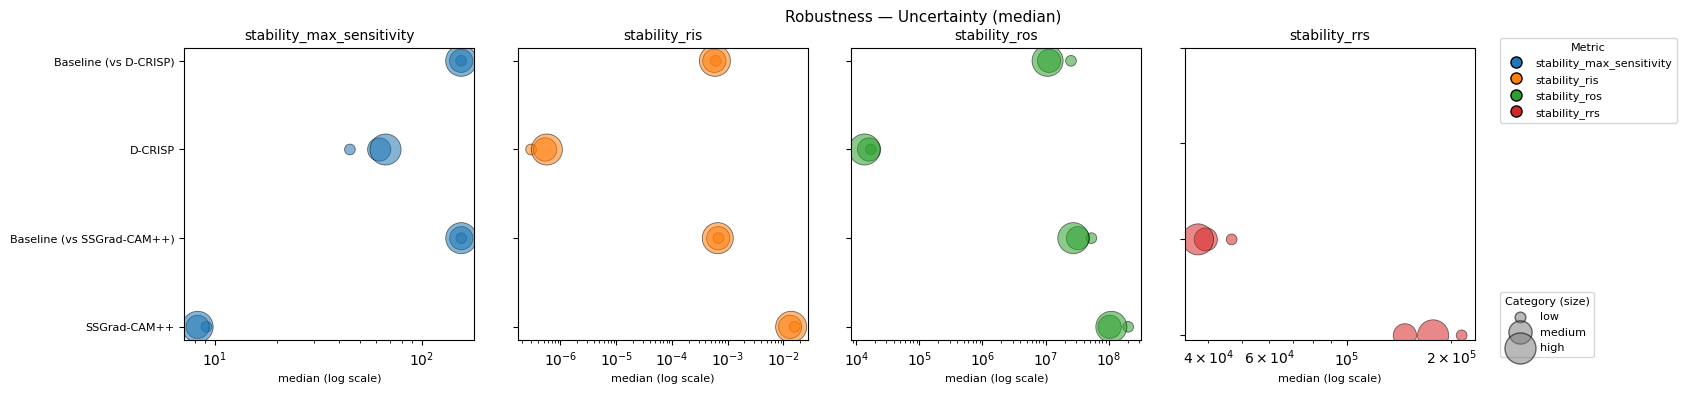

Saved -> results/final/figures/Robustness_Uncertainty_median.png


In [87]:
render_family_table(master, "Robustness", "Uncertainty")

### Análisis: Robustez por incertidumbre (low N≈2682, medium N≈1784, high N≈2979 — máximos por fila; D-CRISP con N mucho menor)

**1. `stability_max_sensitivity`: SSGrad-CAM++ prácticamente plano; D-CRISP empeora de forma monótona con la incertidumbre (confirma el patrón ya visto en Distancia)**

| (mediana) | low | medium | high |
|---|---|---|---|
| SSGrad-CAM++ | 9.12 | 8.27 | 8.27 |
| D-CRISP | 44.94 | 62.25 | **66.79** |

SSGrad-CAM++ se mantiene casi plano (8.27-9.12), con una ligerísima tendencia a peor en `low`.

D-CRISP, en cambio, empeora de forma monótona y clara con la incertidumbre (44.94→62.25→66.79). Esto reconfirma el patrón ya visto en Distancia (donde D-CRISP también empeoraba de forma monótona y limpia con la distancia: 46.22→53.17→90.39).

**2. RIS/ROS/RRS de SSGrad-CAM++ (vía mediana): reaparece un patrón en U**

Ratio mediana(SSGrad-CAM++)/mediana(su baseline):

| | low | medium | high |
|---|---|---|---|
| RIS | 23.4× | **19.5×** | 20.7× |
| ROS | 3.83× | **3.18×** | 4.01× |
| RRS | 4.59× | **3.74×** | 4.74× |

Las tres métricas muestran la misma forma de U que ya se detectó en cuatro de las cinco métricas de Localización por Incertidumbre y, en aquel caso, se estableció que era explicable por la composición de `correctness` dentro de cada bin de incertidumbre: `false_positive` tiene su pico de concentración en `medium` (19.1%, frente a 12.7% en `low` y 9.8% en `high`).

Aquí se puede comprobar la misma hipótesis de forma cuantitativa, porque Robustez por Corrección ya estableció los ratios de SSGrad-CAM++ por categoría de corrección: RIS 22.2× (`correct`), 13.3× (`false_positive`), 15.2× (`wrong_class`) — es decir, `false_positive` es la categoría con MEJOR ratio para SSGrad-CAM++. Ponderando estos ratios por la composición real de cada bin de incertidumbre se obtiene una predicción "solo por composición":

| RIS | low | medium | high |
|---|---|---|---|
| Observado | 23.4× | 19.5× | 20.7× |
| Predicho solo por composición de `correctness` | 21.1× | 20.5× | 21.2× |

La dirección coincide (el mínimo cae en `medium`, igual que lo observado), lo que confirma que parte del patrón en U es, en efecto, un eco del mismo mecanismo de composición que explica el de Localización: al concentrar más `false_positive` (categoría con mejor ratio para SSGrad-CAM++), `medium` se ve arrastrado hacia un ratio más bajo. Pero la magnitud del hueco predicho por composición (21.1×→20.5×, una caída de solo el 2.8%) es mucho menor que la observada (23.4×→19.5×, una caída del 17%) — el mismo patrón se repite en ROS y RRS. La composición de `correctness` explica, por tanto, la dirección del patrón en U pero no su magnitud completa; queda un residuo sustancial sin explicación mecanística verificada, que debe seguir señalándose como un hallazgo genuino y no resuelto de la variable incertidumbre, distinto del comportamiento limpio y monótono de Tamaño y Distancia.

**Síntesis parcial:** este CSV aporta dos cosas. Primero, una segunda confirmación (tras Distancia) de que D-CRISP se vuelve más inestable en términos absolutos en la condición de mayor incertidumbre/distancia, en dirección opuesta a SSGrad-CAM++. Segundo, una confirmación cruzada, desde una familia de métricas distinta, del patrón en U ya detectado en Localización, ahora con una explicación cuantificada pero solo parcial: la composición de `false_positive` (con pico en `medium`) explica la dirección del hueco mediante la ponderación por la composición real de correctness dentro de cada bin, pero no su magnitud completa, dejando un residuo genuino que sigue distinguiendo a Incertidumbre de la dinámica limpia y monótona de Tamaño y Distancia.

Cobertura de robustez

Saved -> results/final/tables/Coverage_Uncertainty.csv


group,metric,method,N,mean,median,std
low,stability_n_valid,SSGrad-CAM++,2902,75.1482,100.0000,39.0934
low,stability_n_valid,Baseline (vs SSGrad-CAM++),2902,84.4986,100.0000,32.4520
low,stability_n_valid,D-CRISP,568,82.8169,100.0000,34.8414
low,stability_n_valid,Baseline (vs D-CRISP),2902,84.5348,100.0000,33.1934
low,stability_n_rejected_gate,SSGrad-CAM++,2902,15.5014,0.0000,32.4520
low,stability_n_rejected_gate,Baseline (vs SSGrad-CAM++),2902,15.5014,0.0000,32.4520
low,stability_n_rejected_gate,D-CRISP,568,17.1831,0.0000,34.8414
low,stability_n_rejected_gate,Baseline (vs D-CRISP),2902,15.4652,0.0000,33.1934
low,stability_n_rejected_explain,SSGrad-CAM++,2902,9.3504,0.0000,21.9118
low,stability_n_rejected_explain,Baseline (vs SSGrad-CAM++),2902,0.0000,0.0000,0.0000


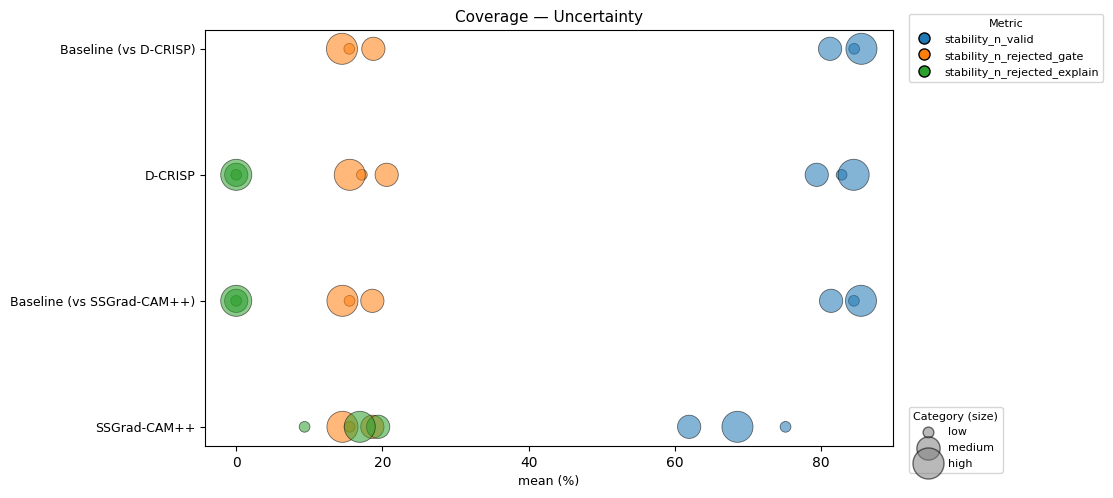

Saved -> results/final/figures/Coverage_Uncertainty.png


In [88]:
render_family_table(master, "Coverage", "Uncertainty")

### Análisis: Cobertura por incertidumbre (low N=2902, medium N=1951, high N=3198)

**1. `stability_n_valid`: la cobertura de SSGrad-CAM++ colapsa específicamente en `medium`, tercera aparición del patrón en U ya visto en Localización y Robustez**

| `stability_n_valid` (media / mediana) | low | medium | high |
|---|---|---|---|
| SSGrad-CAM++ | 75.1% / 100 | **62.0% / 85** | 68.6% / 90 |
| D-CRISP | 82.8% / 100 | 79.4% / 100 | 84.5% / 100 |
| Baseline | ~84.5% / 100 | ~81.3% / 100 | ~85.5% / 100 |

La cobertura de SSGrad-CAM++ no decrece de forma monótona con la incertidumbre: es peor en `medium` (61.96%) que en `low` o `high`. D-CRISP y ambos baselines muestran también una caída en `medium` (D-CRISP: 82.8%→79.4%→84.5%; baseline: ~84.5%→81.3%→85.5%), pero mucho más suave que la de SSGrad-CAM++ . Esto indica que parte del fenómeno es compartido por todos los métodos (una propiedad de la población) y parte es específica de SSGrad-CAM++.

**2. Descomposición: el `gate` (compartido) está casi completamente explicado por la composición de `correctness`; el `explain` (específico de SSGrad-CAM++) NO lo está**

| SSGrad-CAM++ | low | medium | high |
|---|---|---|---|
| `n_rejected_gate` | 15.5% | **18.6%** | 14.5% |
| `n_rejected_explain` | 9.4% | **19.4%** | 16.9% |

El `gate` alcanza su máximo en `medium`. Ya sabemos, de Cobertura por Corrección, que el `gate` depende fuertemente de la corrección de la detección (correct 11.7%, false_positive 41.4%, wrong_class 47.2%), y del análisis de solapamiento entre desgloses, que `false_positive` concentra su pico precisamente en `medium` (19.1%, frente a 12.7% en `low` y 9.8% en `high`). Ponderando las tasas de `gate` por corrección con la composición real de cada bin de incertidumbre se obtiene una predicción que reproduce el patrón observado casi con exactitud (15.58%/17.63%/15.07% predicho frente a 15.50%/18.62%/14.53% observado). Es decir: el pico de `gate` en `medium` **no es una propiedad intrínseca de la incertidumbre media en sí**, sino, en su práctica totalidad, un reflejo de que `medium` contiene más detecciones `false_positive`/`wrong_class` (las categorías con `gate` alto, ya establecidas en Corrección) que `low` o `high`.

El rechazo por fallo en `explain`, en cambio, es máximo también en `medium` (19.4%, frente a 9.4% en `low`), pero repitiendo el mismo ejercicio de ponderación por composición de `correctness` (usando las tasas de `explain` por corrección de Cobertura por Corrección: correct 13.1%, false_positive 25.9%, wrong_class 10.6%) la predicción resultante (14.7%/15.5%/14.3%) no reproduce al patrón observado (9.4%/19.4%/16.9%). La composición de `correctness` no explica el pico de `explain` en `medium`; a diferencia del `gate`, este componente sigue siendo un hallazgo genuino, específico de SSGrad-CAM++ y sin explicación mecanística verificada: algo en el cómputo de su celda-ancla/gradiente falla con más frecuencia en la franja de incertidumbre media, por una razón que no se ha determinado en este análisis.

**Síntesis parcial:** este CSV permite, por primera vez en el bloque de Incertidumbre, separar con precisión cuantitativa dos componentes que hasta ahora se discutían juntos bajo la etiqueta genérica de "patrón en U": el `gate` está explicado casi por completo por la composición de `correctness` (concretamente, la concentración de `false_positive` en `medium`, la misma causa ya usada para explicar parcialmente el patrón en U de Localización y Robustez); el `explain` (específico de SSGrad-CAM++) no lo está, y sigue siendo un hallazgo genuino y sin mecanismo conocido. La combinación de ambos es lo que produce el colapso de cobertura desproporcionadamente severo de SSGrad-CAM++ en `medium`. De cara a la síntesis conjunta del bloque, conviene ser precisos: no todos los "patrones en U" de este bloque comparten la misma causa ni el mismo grado de explicación: el de Localización (D-CRISP) y el de `gate` en Cobertura están bien explicados por la composición de correctness; el de RIS/ROS/RRS en Robustez y el de `explain` en Cobertura solo parcialmente.

### Síntesis del bloque Incertidumbre (low N=2902 [36.0%], medium N=1951 [24.2%], high N=3198 [39.7%]; total 8051)

Este bloque combina dos historias distintas: una réplica parcial del patrón central ya establecido en Tamaño/Distancia/Corrección, y un comportamiento no monótono específico del grupo `medium`.

**1. Réplica parcial del patrón central: `low` concentra objetos algo mayores Y detecciones intrínsecamente más estables**

`low` no es "el grupo de los objetos grandes": por tamaño discreto sigue siendo mayoritariamente pequeño (69.4% "small", frente a ~91-92% en `medium`/`high`), y solo concentra una fracción moderadamente mayor de medianos (21.8%) y grandes (8.8%). Pero el área de caja real sí confirma una diferencia genuina: mediana de 8 065 px² en `low` frente a ~2 520 px² en `medium`/`high`. Sobre esta base real de tamaño se superpone un segundo mecanismo: el baseline sin heatmap muestra que `deletion_auc` e `insertion_auc` decrecen con la incertidumbre **dentro de cada estrato de tamaño fijo** (p. ej. dentro de "small": `deletion_auc` 0.0556→0.0427→0.0418; `insertion_auc` 0.5042→0.3968→0.3981), es decir, una detección de mayor incertidumbre epistémica es intrínsecamente más frágil frente a cualquier perturbación, con independencia de su tamaño, el mismo fenómeno de "fragilidad de la detección" ya documentado en Fidelidad por Corrección para `false_positive`/`wrong_class`.

| Familia | Evidencia | Dirección |
|---|---|---|
| Fidelidad (deletion) | `deletion_auc`/`minimal_subset`: SSGC peor en `low` que en `medium`/`high`, confirmado por valor bruto y brecha absoluta; D-CRISP pasa de perder (-25.1%, `low`) a ganar (+7.8%/+9.9%, `medium`/`high`) | Tercera confirmación del mecanismo de tamaño + segunda confirmación independiente del mecanismo de fragilidad de la detección |
| Localización (ranking fino) | Ventaja de D-CRISP se estrecha de `low` a `medium`/`high` (p.ej. `relevance_rank_accuracy`: +0.271 → +0.032), pero **sin llegar a invertirse** como sí ocurría en Distancia | Confirma parcialmente |
| Fidelidad (insertion) | `insertion_auc`: ventaja relativa crece de `low` a `high` para ambos métodos, confirmado también por brecha absoluta | Confirma (cuarta disociación deletion/insertion consecutiva, tras Tamaño, Distancia, Corrección) |

**2. Patrón en U centrado en `medium`**

| Familia | Métrica(s) | Patrón | Grado de explicación por composición de `correctness` |
|---|---|---|---|
| Localización | `pointing_game`, `relevance_rank_accuracy`, `rank_accuracy_at_min_subset`, `rank_accuracy_precision` (D-CRISP) | Mejor en `low`, peor en `medium`, recuperación parcial en `high` | Mecanismo distinto: es D-CRISP colapsando específicamente en `false_positive` (`pointing_game` 0.425 vs 0.776/0.705 en correct/wrong_class), no una fragilidad genérica de `medium` |
| Robustez | `stability_ris`/`ros`/`rrs` (SSGrad-CAM++, vía mediana) | Mismo patrón en U | **Parcial**: la composición predice un mínimo en `medium` (p. ej. RIS predicho 21.1×/20.5×/21.2× frente a observado 23.4×/19.5×/20.7×), pero solo explica ~1/4 de la magnitud del hueco; queda un residuo genuino sin explicación mecanística |
| Cobertura | `stability_n_valid` (SSGrad-CAM++): 75.1%→**62.0%**→68.6% | Mismo patrón en U | Se descompone en dos causas de naturaleza opuesta: el `gate` (compartido con baseline y D-CRISP) está explicado casi por completo por la composición; el `explain` (específico de SSGrad-CAM++) no está explicado por esa misma composición y sigue siendo un hallazgo genuino sin mecanismo conocido |

La causa común identificada para la parte explicable del patrón es la misma en los tres casos: `false_positive` concentra su pico de frecuencia precisamente en `medium` (19.1%, frente a 12.7% en `low` y 9.8% en `high`, con `correct` en 80.3%/87.0%/88.9% y `wrong_class` residual en los tres grupos). Como `false_positive` es, en Corrección, la categoría con peor `gate` (41.4% frente a 11.7% en `correct`) para ambos métodos y baselines, y a la vez la categoría donde D-CRISP colapsa en localización, un bin que concentre más `false_positive` arrastra hacia abajo cualquier métrica sensible a esa categoría. Esto es lo que ocurre casi por completo en el `gate` de Cobertura, parcialmente en RIS/ROS/RRS de Robustez, y de forma indirecta en Localización. Que el grado de explicación varíe tanto entre familias es en sí mismo un resultado a destacar: no todas las manifestaciones del patrón en U comparten mecanismo, aunque todas coincidan en señalar a `medium` como la condición más anómala.

**Implicación práctica para la memoria:** el bloque Incertidumbre no es una simple réplica de Tamaño/Distancia bajo otro nombre: aporta evidencia de un segundo mecanismo de fragilidad,ligado directamente a la incertidumbre epistémica del modelo. Y el patrón en U de `medium` que tiene como hipótesis la concentración de `false_positive` en ese tercil. Aun así, esta hipótesis no termina de cubrir el fallo de cómputo (`explain`) específico de SSGrad-CAM++ en `medium`, y el residuo de robustez relativa (RIS/ROS/RRS).

Por clase de objeto

Localización

Saved -> results/final/tables/Localization_Class.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
car,pointing_game,SSGrad-CAM++,5855,0.9997,1.0000,0.0185,+6061.1%
car,pointing_game,D-CRISP,5855,0.7949,1.0000,0.4038,+4798.9%
car,pointing_game,Baseline (noise),5855,0.0162,0.0000,0.1264,—
car,ebpg,SSGrad-CAM++,5855,0.9096,0.9697,0.1221,+3645.0%
car,ebpg,D-CRISP,5855,0.0371,0.0177,0.0453,+52.6%
car,ebpg,Baseline (noise),5855,0.0243,0.0077,0.0376,—
car,relevance_rank_accuracy,SSGrad-CAM++,5855,0.3967,0.3652,0.2159,+1540.2%
car,relevance_rank_accuracy,D-CRISP,5855,0.5745,0.6564,0.2483,+2275.5%
car,relevance_rank_accuracy,Baseline (noise),5855,0.0242,0.0081,0.0375,—
car,rank_accuracy_at_min_subset,SSGrad-CAM++,5855,0.6579,0.6623,0.2464,+818.7%


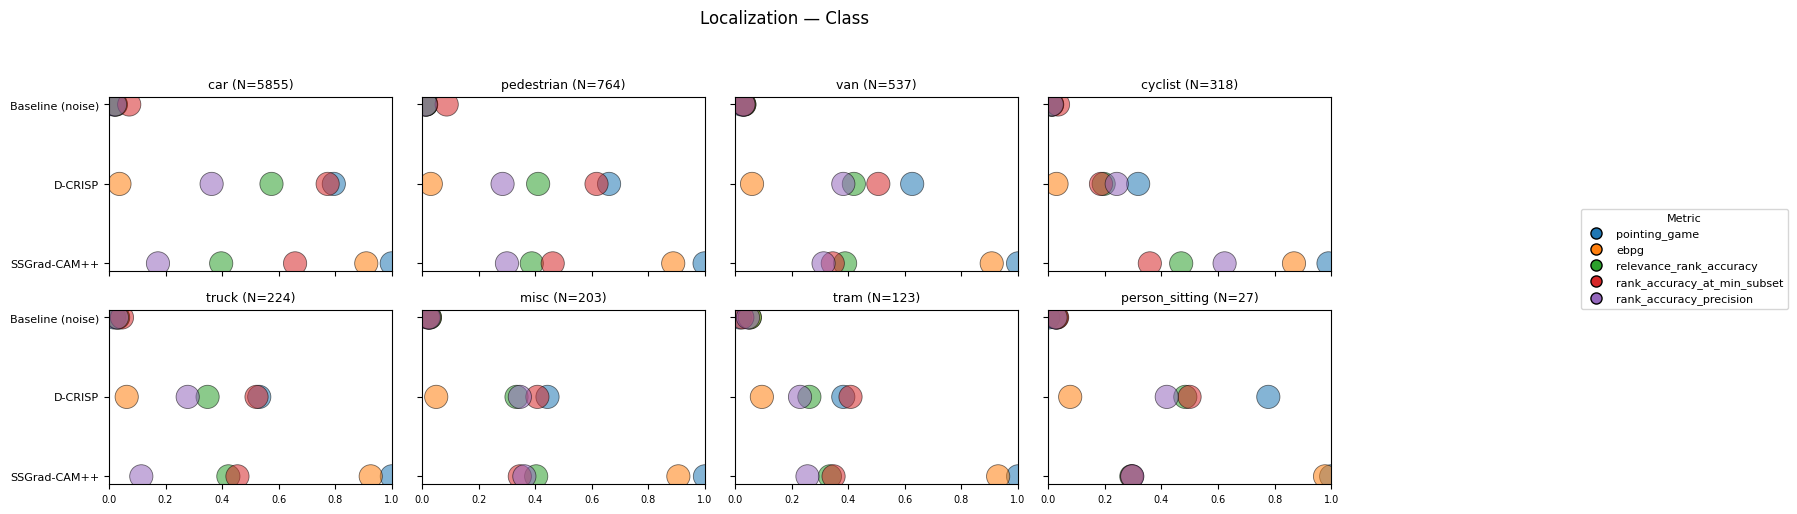

Saved -> results/final/figures/Localization_Class.png


In [89]:
render_family_table(master, "Localization", "Class")

### Análisis: Localización por clase (car N=5855 [72.7%], van N=537 [6.7%], pedestrian N=764 [9.5%], cyclist N=318 [3.9%], truck N=224 [2.8%], misc N=203 [2.5%], tram N=123 [1.5%], person_sitting N=27 [0.34%]; total 8051)

**0. Composición poblacional**

Ocho clases de KITTI, con una distribución muy desigual: `car` domina con el 72.7% de la población, y las cuatro clases más raras (`truck`, `misc`, `tram`, `person_sitting`) suman en conjunto menos del 7%. Cualquier estadístico sobre `person_sitting` (N=27) o `tram` (N=123) debe leerse con más cautela que el resto, de forma análoga a lo ya señalado para `wrong_class` en el bloque Corrección.

**1. `pointing_game`: SSGrad-CAM++ sigue siendo perfecto en todas las clases; D-CRISP muestra una variación muy amplia entre clases, parcialmente ligada a la frecuencia de la clase**

| Clase | N | SSGrad-CAM++ | D-CRISP |
|---|---|---|---|
| car | 5855 | 0.9997 | **0.795** |
| pedestrian | 764 | 0.9987 | 0.661 |
| van | 537 | 1.000 | 0.626 |
| truck | 224 | 1.000 | 0.531 |
| misc | 203 | 1.000 | 0.443 |
| tram | 123 | 1.000 | **0.382** |
| cyclist | 318 | 0.9906 | **0.318** |
| person_sitting | 27 | 1.000 | 0.778 |

SSGrad-CAM++ se mantiene en 0.99-1.00 en las ocho clases, quinta confirmación (tras Tamaño, Distancia, Corrección, Incertidumbre) de su total insensibilidad a la condición del objeto, ahora extendida a la clase semántica.

D-CRISP, en cambio, oscila entre 0.318 (`cyclist`) y 0.795 (`car`), el rango más amplio observado para esta métrica en todo el proyecto. Existe una correlación con la frecuencia de la clase (la clase mayoritaria, `car`, es la mejor; las clases minoritarias `tram` y `cyclist` están entre las peores). Sin embargo, la correlación no es perfecta: `cyclist` (N=318) es peor que `tram` (N=123, mucho más rara), y `person_sitting` (N=27, la clase más rara de todas) tiene un valor sorprendentemente alto (0.778, cercano al de `car`), aunque con N=27 esto podría deberse al azar. No se identifica aquí una única variable que explique limpiamente todo el patrón.

**2. `ebpg`: las diferencias entre clases reflejan el artefacto de tamaño de caja ya documentado**

D-CRISP: car=0.037, cyclist=0.029, misc=0.050, pedestrian=0.031, person_sitting=0.077, tram=0.094, truck=0.063, van=0.060 — aquí `tram` (previsiblemente una caja grande, al tratarse de un vehículo de gran tamaño) y, de forma menos esperable, `person_sitting` puntúan más alto que `car`, siendo el valor para `person_sitting` una posible causa de tener tan pocos objetos en la muestra.


**3. Ranking fino: el ganador entre métodos varía por clase, sin un patrón limpio ligado a tamaño o frecuencia. `cyclist` destaca como la clase con la mayor y más consistente desventaja de D-CRISP**

| Clase | `relevance_rank_accuracy` (SSGC vs D-CRISP) | `rank_accuracy_at_min_subset` | `rank_accuracy_precision` |
|---|---|---|---|
| car | 0.397 vs **0.575** | 0.658 vs **0.773** | 0.173 vs **0.363** |
| cyclist | **0.470** vs 0.196 | **0.359** vs 0.186 | **0.623** vs 0.242 |
| misc | **0.403** vs 0.334 | 0.345 vs **0.408** | **0.362** vs 0.346 |
| pedestrian | 0.388 vs **0.410** | 0.462 vs **0.617** | **0.300** vs 0.284 |
| person_sitting | 0.293 vs **0.484** | 0.296 vs **0.499** | 0.297 vs **0.419** |
| tram | **0.335** vs 0.262 | 0.348 vs **0.408** | **0.256** vs 0.229 |
| truck | **0.422** vs 0.349 | 0.454 vs **0.522** | 0.114 vs **0.278** |
| van | 0.389 vs **0.419** | 0.345 vs **0.506** | 0.312 vs **0.382** |

El método ganador (en negrita) cambia de clase en clase sin seguir el patrón limpio de tamaño/distancia/incertidumbre ya establecido: D-CRISP gana en `car`, `pedestrian`, `person_sitting` y `van` en las tres métricas (o casi), mientras SSGrad-CAM++ gana en `cyclist` de forma sistemática y con el margen más amplio de toda la tabla (`rank_accuracy_precision`: 0.623 vs 0.242, una diferencia de 0.381 — la mayor brecha a favor de SSGrad-CAM++ vista en cualquier desglose del proyecto). `misc` y `tram` también favorecen a SSGrad-CAM++ en `relevance_rank_accuracy` y en `rank_accuracy_precision`, pero D-CRISP los recupera en `rank_accuracy_at_min_subset`.

`cyclist` es, por tanto, el hallazgo más sólido de esta tabla: es la única clase donde SSGrad-CAM++ supera a D-CRISP de forma consistente en las tres métricas de ranking fino, con márgenes sustanciales. Dado que `cyclist` no es ni la clase más pequeña ni la más rara (hay clases con cajas más pequeñas y menos ejemplos que se comportan de forma distinta), esto sugiere una característica propia de la clase. Posiblemente su silueta compuesta y poco compacta (persona + bicicleta, con huecos y bordes irregulares) que podría dificultar específicamente el mecanismo de máscaras de D-CRISP de una forma que ni el tamaño ni la frecuencia por sí solos explican. Se ofrece como hipótesis razonable, no verificada.

**Advertencia pendiente:** la magnitud del `rank_accuracy_precision` de SSGrad-CAM++ en `cyclist` (0.623, el valor más alto de toda la tabla para este método) debería contrastarse con `min_subset_k_pixels_exact` en `Fidelity_Class.csv` antes de interpretarse como una mejora genuina de ranking, siguiendo la misma cautela metodológica ya aplicada en `wrong_class` (Corrección), los cíclistas, al ser objetos alargados y estrechos, podrían tener cajas más pequeñas en píxeles, lo cual mecánicamente favorecería la precisión.

**Síntesis parcial:** este primer CSV del bloque Clase introduce una variable claramente distinta a tamaño/distancia/corrección/incertidumbre, la semántica de la clase detectada, con dos hallazgos propios: la varianza de `pointing_game` de D-CRISP entre clases (parcialmente ligada a la frecuencia de la clase), y la anomalía de `cyclist` como la única clase donde SSGrad-CAM++ supera claramente a D-CRISP en ranking fino, de forma consistente en las tres métricas. Ninguno de los dos hallazgos se reduce limpiamente al patrón de tamaño/distancia ya establecido, lo que sugiere que la clase aporta información genuinamente nueva al análisis.

Fidelidad

Saved -> results/final/tables/Fidelity_Class.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
car,deletion_auc,SSGrad-CAM++,5855,0.3593,0.4246,0.2122,-584.8%
car,deletion_auc,D-CRISP,5855,0.0553,0.0161,0.0784,-5.4%
car,deletion_auc,Baseline (noise),5855,0.0525,0.0473,0.0301,—
car,insertion_auc,SSGrad-CAM++,5855,0.7083,0.7640,0.1924,+37.8%
car,insertion_auc,D-CRISP,5855,0.7987,0.8760,0.1860,+55.4%
car,insertion_auc,Baseline (noise),5855,0.5140,0.5035,0.2733,—
car,minimal_subset,SSGrad-CAM++,5855,0.4420,0.5517,0.2438,-402.2%
car,minimal_subset,D-CRISP,5855,0.0816,0.0345,0.0940,+7.2%
car,minimal_subset,Baseline (noise),5855,0.0880,0.0690,0.0402,—
car,min_subset_k_pixels_exact,SSGrad-CAM++,5855,61393.6386,76426.0000,36134.3594,-499.1%


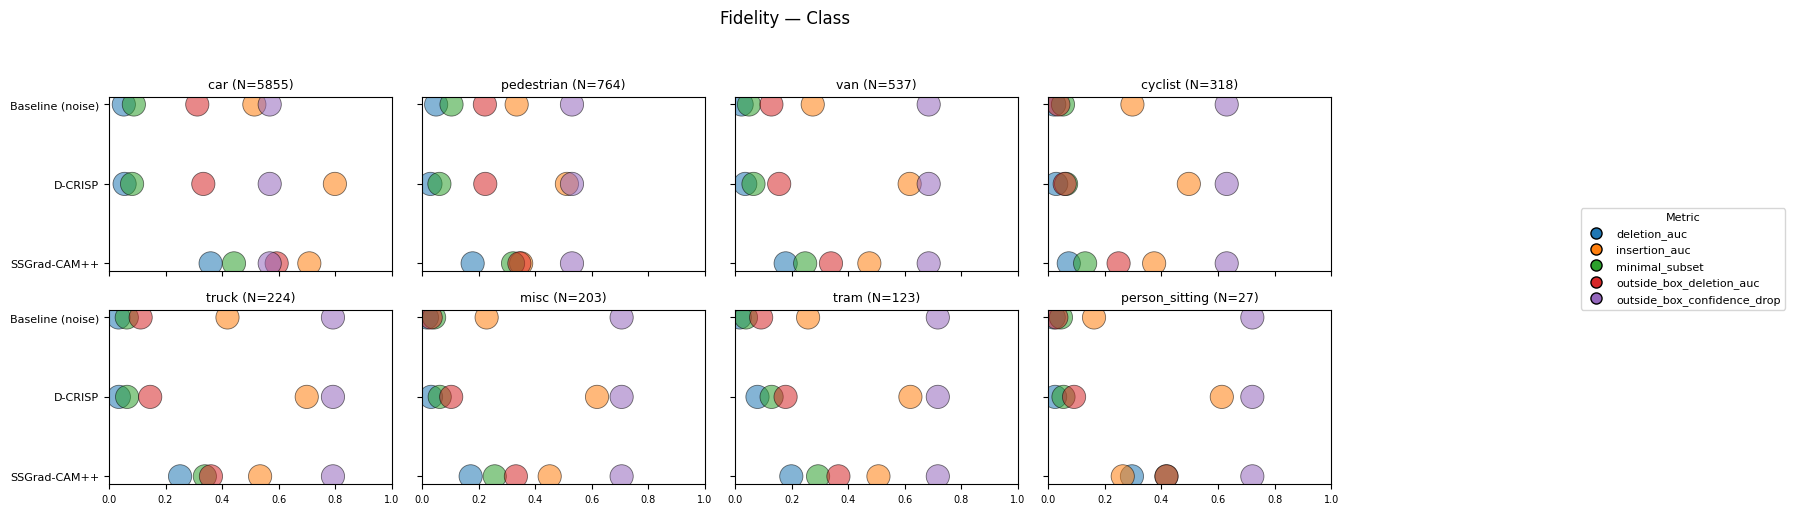

Saved -> results/final/figures/Fidelity_Class.png


In [90]:
render_family_table(master, "Fidelity", "Class")

### Análisis: Fidelidad por clase (car N=5855, van N=537, pedestrian N=764, cyclist N=318, truck N=224, misc N=203, tram N=123, person_sitting N=27)

**1. Hallazgo mayor: la desventaja de SSGrad-CAM++ en `cyclist` (`deletion_auc`, `minimal_subset`, `k`) es, en gran medida, un artefacto puro de media — la mediana muestra paridad con el baseline**

| `cyclist` | media | mediana |
|---|---|---|
| `deletion_auc` SSGrad-CAM++ | 0.0723 | **0.0135** |
| `deletion_auc` Baseline | 0.0208 | 0.0133 |
| `minimal_subset` SSGrad-CAM++ | 0.1301 | **0.0345** |
| `minimal_subset` Baseline | 0.0518 | 0.0345 |
| `min_subset_k_pixels_exact` SSGrad-CAM++ | 14 901 | **252** |
| `min_subset_k_pixels_exact` Baseline | 4 972 | 3 969 |

La tabla reporta para SSGrad-CAM++ en `cyclist` una desventaja aparentemente severa (`deletion_auc`: -247.3%; `minimal_subset`: -151.0%; `k`: -199.7%), pero estas cifras están basadas en la media. Al mirar la mediana, la historia cambia por completo: el `deletion_auc` típico de SSGrad-CAM++ (0.0135) es prácticamente IDÉNTICO al del baseline (0.0133); `minimal_subset` coincide EXACTAMENTE (0.0345 en ambos); y el `k` típico de SSGrad-CAM++ (252 píxeles) es incluso MENOR que el del baseline (3 969), es decir, para el objeto cyclist típico, SSGrad-CAM++ no es catastróficamente peor que el ruido, sino que está a la par o incluso ligeramente por delante.

 La razón de esta divergencia extrema (el ratio media/mediana de `k` para SSGrad-CAM++ en `cyclist` es ≈59×, frente a un rango de solo 0.73×-0.98× para esa misma métrica en el resto de clases) es que un pequeño número de objetos `cyclist` atípicos (posiblemente ciclistas grandes/cercanos, o casos con un patrón de atribución degenerado) requieren un número de píxeles enorme para tumbar la detección, arrastrando la media muy por encima de lo que describe al caso típico. Es la primera vez en todo el proyecto que se documenta este tipo de artefacto de media extrema para SSGrad-CAM++ (hasta ahora solo se había visto de esta magnitud en las métricas de robustez de D-CRISP, RIS/ROS).

**2. Explicación adicional: el suelo de discretización del paso de borrado (`step=5000`) probablemente satura `minimal_subset`/`k` para la mayoría de objetos `cyclist`**

El hecho de que `minimal_subset` en `cyclist` sea EXACTAMENTE 0.0345 para los tres métodos (baseline, D-CRISP y SSGrad-CAM++) en la mediana es una pista concreta: con el `step=5000` píxeles ya documentado, si la caja de un ciclista típico es lo bastante pequeña, el primer paso de borrado ya la cubre por completo, con independencia de en qué orden se borren los píxeles, de ahí que los tres métodos coincidan en el mismo valor mínimo medible. Esto significa que, para la mayoría de los objetos `cyclist`, esta familia de métricas no tiene resolución suficiente para distinguir la calidad de un método de otro; solo la minoría de ciclistas con cajas más grandes (que superan el primer paso) generan variación real entre métodos, y son precisamente esos casos atípicos los que dominan la media.

**3. D-CRISP: `pedestrian` es la ÚNICA clase donde supera claramente al ruido en fidelidad (`deletion_auc`)**

| `improvement_vs_baseline_pct` (deletion_auc, D-CRISP) | car | cyclist | misc | pedestrian | person_sitting | tram | truck | van |
|---|---|---|---|---|---|---|---|---|
| | -5.4% | -33.8% | -84.1% | **+40.6%** | -25.7% | **-387.0%** | -3.1% | -56.3% |

`pedestrian` es la única de las ocho clases donde D-CRISP bate claramente al baseline en `deletion_auc`, y esto se confirma con la mediana (D-CRISP: 0.0199 vs baseline: 0.0355. D-CRISP genuinamente mejor, no un artefacto de media). En las siete clases restantes, D-CRISP pierde frente al ruido, con magnitudes que van de leves (`car` -5.4%, `truck` -3.1%) a severas (`tram` -387.0%, `misc` -84.1%). El caso de `tram` sí se confirma como un efecto real (no solo de media): su mediana de D-CRISP (0.0437) es peor que la del baseline (0.0149)

Esto matiza de forma importante el hallazgo, ya establecido en Tamaño/Distancia/Incertidumbre, de que D-CRISP supera al ruido específicamente en objetos "pequeños": aquí se ve que, dentro de la población real de KITTI, esa ventaja no se reparte de forma uniforme entre todas las clases pequeñas, sino que se concentra sobre todo en `pedestrian`, mientras que otras clases de tamaño similar o menor (`cyclist`, `person_sitting`) no logran superar al ruido.

**4. `insertion_auc`: sólido en las ocho clases**

Ambos métodos superan al baseline en las ocho clases, sin inversiones de signo ni discrepancias dramáticas entre grupos. Reconfirma, por quinta vez (tras Tamaño, Distancia, Corrección, Incertidumbre), que la fragilidad de ambos métodos es específica de la dirección deletion.

**5. `outside_box_confidence_drop`: varía sustancialmente entre clases sin un orden claro ligado al tamaño. La clase aporta variación propia**

| car | cyclist | misc | pedestrian | person_sitting | tram | truck | van |
|---|---|---|---|---|---|---|---|
| 0.568 | 0.631 | 0.705 | **0.530** | 0.721 | 0.716 | **0.792** | 0.684 |

A diferencia de Tamaño/Incertidumbre (donde este valor se ordenaba de forma limpia por tamaño aparente), aquí `truck` tiene el valor MÁS ALTO de dependencia del contexto exterior (0.792), mientras que `pedestrian` tiene el más bajo (0.530). Este contraejemplo es particularmente sólido porque ya sabemos, por el análisis de solapamiento entre desgloses, que `truck`/`van` están sobrerrepresentados precisamente en la categoría de tamaño `large` (mientras que `pedestrian` es prácticamente inexistente en ella): si el tamaño de caja fuera la única variable relevante, `truck` debería mostrar uno de los valores MÁS BAJOS de `outside_box_confidence_drop` (como los objetos `large` en Tamaño (0.105)), no el más alto. La clase semántica introduce aquí una variación que no se reduce al tamaño de la caja, probablemente relacionada con el contexto típico de cada clase.

**Síntesis parcial:** el hallazgo más importante de este CSV es metodológico: la desventaja de SSGrad-CAM++ en `cyclist`, que en Localización ya generaba sospechas (el `rank_accuracy_precision` anómalamente alto), resulta ser en gran medida un artefacto de media causado por un suelo de discretización (`step=5000`) que satura la métrica para la mayoría de objetos pequeños de esta clase. Esto confirma, con una cifra concreta, esa sospecha: el `k` típico (mediana) de SSGrad-CAM++ en `cyclist` es de solo 252 píxeles, entre 100 y 300 veces menor que en cualquier otra clase (34 707-78 881 píxeles) — exactamente el tipo de `k` anormalmente pequeño que, según la regla de interpretación conjunta ya establecida, infla mecánicamente `rank_accuracy_precision` sin que exista necesariamente una mejora genuina de ranking detrás. Sustancialmente, se confirma también que la ventaja de fidelidad de D-CRISP sobre el ruido, lejos de ser una propiedad general de "objetos pequeños", está concentrada específicamente en la clase `pedestrian`. Y el contraejemplo de `truck` en `outside_box_confidence_drop` muestra que la dependencia del detector del contexto exterior no es reducible al tamaño de caja: la clase semántica aporta una variación propia que ni Tamaño ni Distancia ni Incertidumbre podían capturar.

Complejidad

Saved -> results/final/tables/Complexity_Class.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
car,sparseness,SSGrad-CAM++,5855,0.9971,0.9987,0.0031,+351.5%
car,sparseness,D-CRISP,5855,0.1534,0.1143,0.1081,-30.5%
car,sparseness,Baseline (noise),5855,0.2208,0.2208,0.0005,—
cyclist,sparseness,SSGrad-CAM++,318,0.9972,0.9987,0.0031,+351.6%
cyclist,sparseness,D-CRISP,318,0.4189,0.3952,0.1804,+89.7%
cyclist,sparseness,Baseline (noise),318,0.2208,0.2208,0.0005,—
misc,sparseness,SSGrad-CAM++,203,0.9961,0.9987,0.0050,+351.2%
misc,sparseness,D-CRISP,203,0.3725,0.3623,0.1832,+68.7%
misc,sparseness,Baseline (noise),203,0.2208,0.2208,0.0005,—
pedestrian,sparseness,SSGrad-CAM++,764,0.9972,0.9966,0.0015,+351.5%


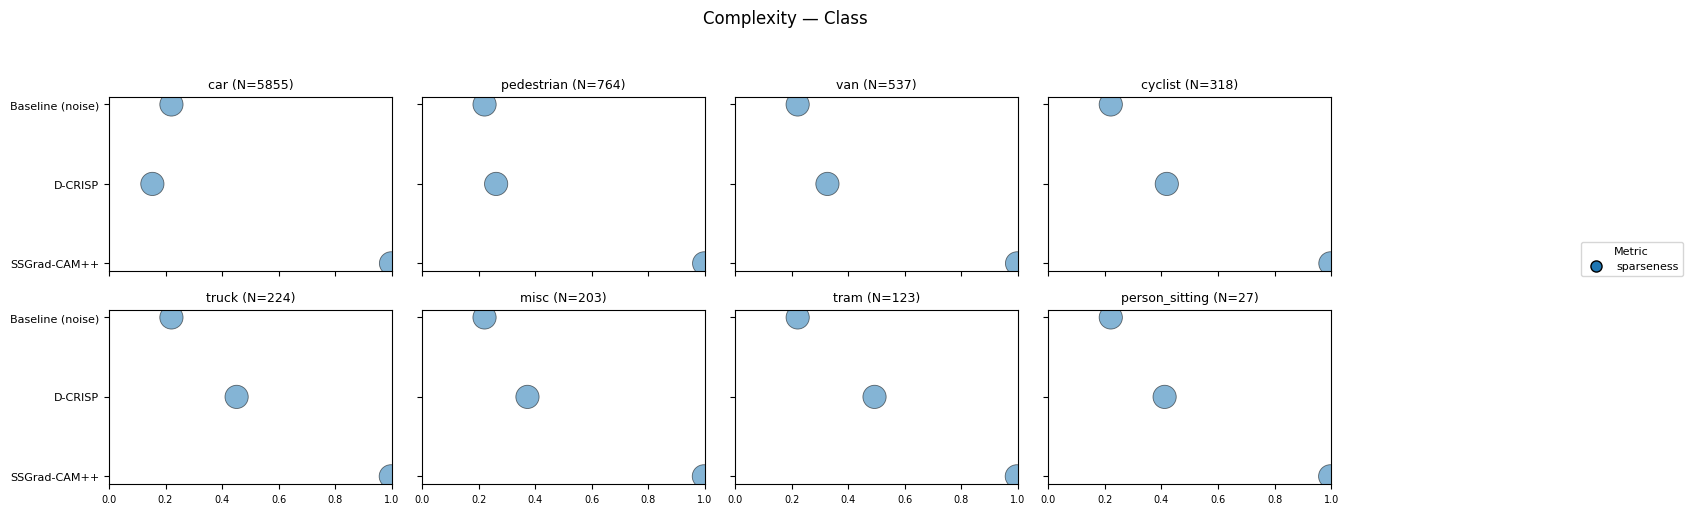

Saved -> results/final/figures/Complexity_Class.png


In [91]:
render_family_table(master, "Complexity", "Class")

### Análisis: Complejidad (sparseness) por clase (car N=5855, van N=537, pedestrian N=764, cyclist N=318, truck N=224, misc N=203, tram N=123, person_sitting N=27)

**1. SSGrad-CAM++: variación mínima entre clases**

Rango 0.9956 (`tram`) - 0.9972 (`cyclist`/`pedestrian`), amplitud de solo 0.0016.

**2. D-CRISP: `car` es la ÚNICA clase por debajo del baseline. Las siete clases restantes lo superan, con `tram` en el extremo**

| car | van | pedestrian | cyclist | truck | misc | person_sitting | tram |
|---|---|---|---|---|---|---|---|
| **-30.5%** | +47.7% | +18.5% | +89.7% | +104.4% | +68.7% | +86.2% | **+123.0%** |

`car` (con diferencia la clase más numerosa (72.7% de la población) y, según ya se vio en Localización, la que ofrece a D-CRISP su mejor `pointing_game` (0.795)) es la única de las ocho clases donde D-CRISP cae con claridad por debajo del baseline en concentración (-30.5% por media, -48.2% por mediana). Seis de las siete clases restantes muestran a D-CRISP claramente por encima del ruido, tanto por media como por mediana, con `tram` (+123.0%/+142.2%) y `truck` (+104.4%/+108.8%) en el extremo superior. `pedestrian`, en cambio, es un caso límite: por media parece superar ligeramente al baseline (+18.5%), pero por mediana está prácticamente empatada con él (-2.5%).

A primera vista, este patrón podría parecer una extensión de la hipótesis ya usada en Tamaño/Distancia/Incertidumbre (presupuesto fijo de máscaras repartido sobre un área mayor para objetos grandes, suavizando la atribución de D-CRISP por debajo del ruido), si se asume que `car` tiene, en promedio, cajas grandes. El cruce `Size_Class.csv` permite comprobarlo directamente en vez de asumirlo:

| Clase | % small | % medium | % large |
|---|---|---|---|
| pedestrian | 97% | 3% | 0.1% |
| cyclist | 91% | 8% | 2% |
| misc | 86% | 9% | 5% |
| `car` | 82% | 13% | **4%** |
| van | 82% | 11% | 7% |
| truck | 81% | 10% | 8% |
| person_sitting | 75% | 25% | 0% |
| `tram` | ~67% | ~21% | **~12%** |

El resultado es el opuesto de lo asumido: `car` NO es la clase con más objetos grandes, tiene una fracción `large` (4%) menor que `van` (7%), `truck` (8%) y, sobre todo, `tram` (~12%, la mayor de las ocho clases). La relación es una inversión casi total de la que predice la hipótesis de tamaño: `car`, con una de las fracciones `large` más bajas, es la ÚNICA clase suprimida (-48.2%); `tram`, con la fracción `large` más alta de todas, es la clase MENOS suprimida, de hecho la más alejada del baseline en sentido positivo (+142.2%). `truck` y `van`, ambas con más objetos grandes que `car`, tampoco muestran ninguna supresión (+108.8% y +43.7%). El tamaño de caja, lejos de explicar el patrón, apunta en la dirección contraria a la observada, por lo que queda descartado como factor relevante en este desglose. 

**Síntesis parcial:** el hallazgo principal de este CSV es que la supresión de sparseness de D-CRISP por debajo del ruido no depende del tamaño del objeto a nivel de clase — la composición real de tamaño por clase (`Size_Class.csv`) muestra una relación inversa a la esperada: `tram`, `truck` y `van` tienen más objetos grandes que `car` y, aun así, ninguna de las tres se suprime, mientras que `car` sí.

Robustez

Saved -> results/final/tables/Robustness_Class.csv


group,metric,method,N,mean,median,std,improvement_vs_baseline_pct
car,stability_max_sensitivity,SSGrad-CAM++,5290,8.3630,8.2702,6.4912,+94.6%
car,stability_max_sensitivity,Baseline (vs SSGrad-CAM++),5586,154.9758,154.9735,0.1610,—
car,stability_max_sensitivity,D-CRISP,1043,58.9568,49.0503,33.4167,+61.9%
car,stability_max_sensitivity,Baseline (vs D-CRISP),5462,154.8215,154.8214,0.1846,—
car,stability_ris,SSGrad-CAM++,5290,0.0181,0.0137,0.0222,-696.9%
car,stability_ris,Baseline (vs SSGrad-CAM++),5586,0.0023,0.0007,0.0081,—
car,stability_ris,D-CRISP,1043,0.0027,0.0000,0.0271,-36.6%
car,stability_ris,Baseline (vs D-CRISP),5462,0.0020,0.0006,0.0066,—
car,stability_ros,SSGrad-CAM++,5290,8595968696.8388,138997453.7853,118962630092.8298,-490.0%
car,stability_ros,Baseline (vs SSGrad-CAM++),5586,1457009505.0009,42831609.9582,16062907064.2647,—


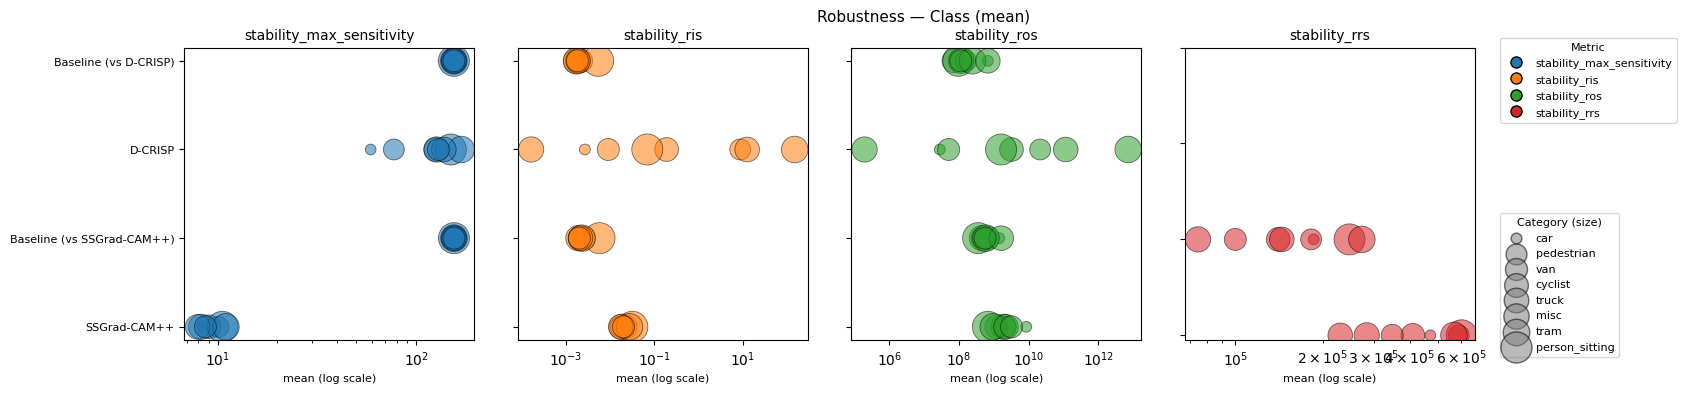

Saved -> results/final/figures/Robustness_Class_mean.png


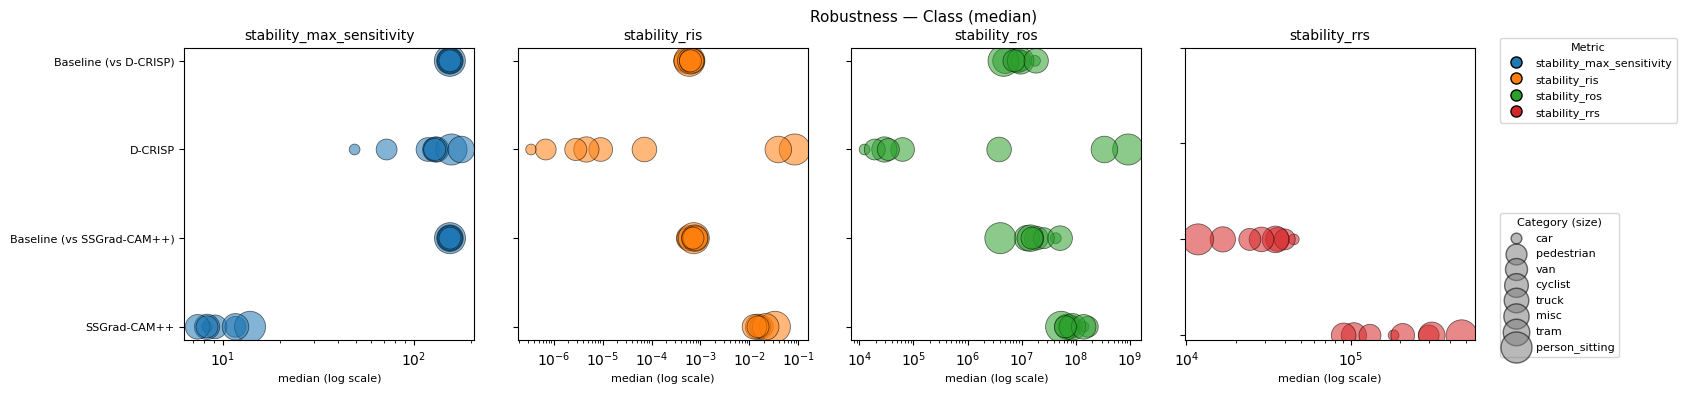

Saved -> results/final/figures/Robustness_Class_median.png


In [92]:
render_family_table(master, "Robustness", "Class")

### Análisis: Robustez por clase

**0. Cobertura:** D-CRISP solo tiene una N razonable en `car` (1043), `pedestrian` (126) y `van` (61); en `cyclist`, `truck`, `misc` y `tram` N=20-41, y en `person_sitting` cae a N=3 (anecdótico). SSGrad-CAM++ tiene N amplia en general (88-5290), salvo en `person_sitting` (N=16), también frágil.

**1. `stability_max_sensitivity`: D-CRISP se degrada con la rareza de la clase, hasta ser menos estable que el propio ruido en `tram`**

El baseline de esta métrica es prácticamente invariante a la clase (154.94-154.98 en las ocho clases), así que comparar clases mediante el % sobre el baseline no introduce distorsión aquí.

| Clase (D-CRISP, N) | car (1043) | pedestrian (126) | cyclist (38) | van (61) | truck (41) | misc (20) | person_sitting (3) | tram (29) |
|---|---|---|---|---|---|---|---|---|
| mediana | 49.1 | 72.2 | 118.8 | 128.8 | 129.3 | 131.5 | 157.9 | 177.6 |
| % del baseline | 31.7% | 46.6% | 76.8% | 83.2% | 83.5% | 85.0% | 102.0% | 114.7% |

D-CRISP es más estable en `car` (31.7% del nivel de ruido) que en cualquier otra clase, y la degradación crece con la rareza hasta `tram`, donde su mediana (177.6) SUPERA a la del propio baseline (154.8), la única condición de todo el proyecto donde esto ocurre para `max_sensitivity`. SSGrad-CAM++, en cambio, tiene una mediana uniformemente baja en las ocho clases (7.4-13.9, siempre muy por debajo del baseline). El efecto de clase aquí es casi exclusivamente un fenómeno de D-CRISP.

**2. `stability_ris`/`ros`/`rrs`: el ratio frente al baseline NO es comparable entre clases y los valores brutos no muestran un patrón de clase único**

A diferencia de `max_sensitivity`, el baseline de estas tres métricas sí varía sustancialmente entre clases. Comparar el ratio SSGrad-CAM++/baseline entre clases mezcla, por tanto, la fragilidad real del método con esta variación del propio ruido, y puede invertir la conclusión. Por eso se comparan directamente las medianas brutas de SSGrad-CAM++ (D-CRISP queda fuera: su N es insuficiente en 6 de las 8 clases):

| Mediana SSGrad-CAM++ | car | pedestrian | van | cyclist | truck | misc | tram | person_sitting (N=16) |
|---|---|---|---|---|---|---|---|---|
| RIS | 0.0137 | 0.0168 | 0.0150 | 0.0175 | **0.0126** | 0.0150 | 0.0214 | **0.0331** |
| ROS (millones) | 139.0 | **166.9** | 64.3 | 79.3 | 139.8 | 69.2 | 87.1 | **53.6** |
| RRS (miles) | 181.8 | 297.1 | 130.6 | 206.7 | **90.4** | 104.3 | 310.3 | **470.9** |

Las tres métricas discrepan entre sí sobre qué clase es más frágil: `person_sitting` es la peor en RIS y RRS, pero la MEJOR en ROS; `truck` es la mejor en RIS y RRS, pero la segunda peor en ROS (139.8M, solo por detrás de `pedestrian`). No hay, por tanto, una explicación consistente para la fragilidad relativa de SSGrad-CAM++ por clase en RIS/ROS/RRS a diferencia de `max_sensitivity`, donde el patrón sí era limpio y consistente.

**Síntesis parcial:** de las cuatro métricas de robustez, solo `max_sensitivity` ofrece un patrón de clase fiable y sin distorsión: la fiabilidad de D-CRISP decae con la rareza de la clase, hasta ser peor que el ruido puro en `tram`. Para RIS/ROS/RRS no emerge un patrón de clase único: cada métrica señala una clase distinta como la más frágil de SSGrad-CAM++. D-CRISP queda excluido de esta segunda comparación por cobertura insuficiente.

Cobertura de robustez

Saved -> results/final/tables/Coverage_Class.csv


group,metric,method,N,mean,median,std
car,stability_n_valid,SSGrad-CAM++,5855,74.4193,100.0000,36.9088
car,stability_n_valid,Baseline (vs SSGrad-CAM++),5855,88.7865,100.0000,27.5244
car,stability_n_valid,D-CRISP,1131,87.8691,100.0000,29.6523
car,stability_n_valid,Baseline (vs D-CRISP),5855,88.7242,100.0000,28.3734
car,stability_n_rejected_gate,SSGrad-CAM++,5855,11.2135,0.0000,27.5244
car,stability_n_rejected_gate,Baseline (vs SSGrad-CAM++),5855,11.2135,0.0000,27.5244
car,stability_n_rejected_gate,D-CRISP,1131,12.1309,0.0000,29.6523
car,stability_n_rejected_gate,Baseline (vs D-CRISP),5855,11.2758,0.0000,28.3734
car,stability_n_rejected_explain,SSGrad-CAM++,5855,14.3672,0.0000,25.9448
car,stability_n_rejected_explain,Baseline (vs SSGrad-CAM++),5855,0.0000,0.0000,0.0000


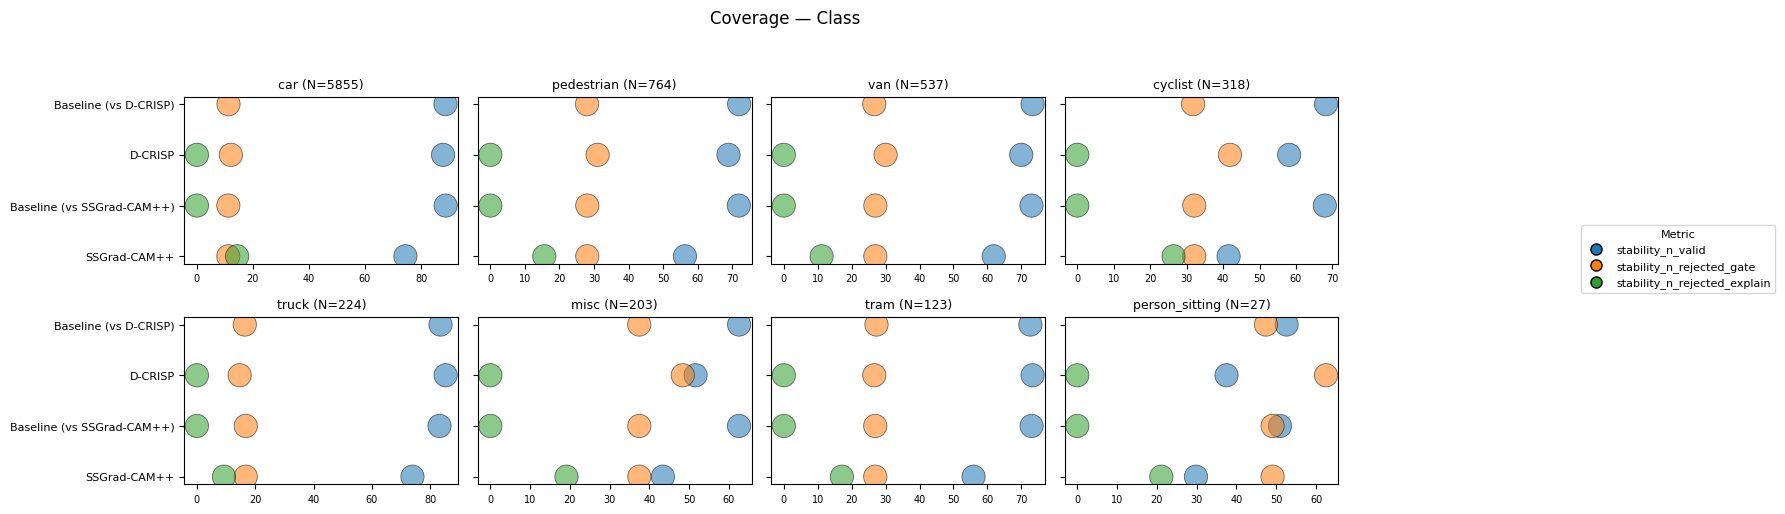

Saved -> results/final/figures/Coverage_Class.png


In [93]:
render_family_table(master, "Coverage", "Class")

### Análisis: Cobertura por clase (car N=5855, van N=537, pedestrian N=764, cyclist N=318, truck N=224, misc N=203, tram N=123, person_sitting N=27)

**1. La cobertura de SSGrad-CAM++ colapsa fuertemente en las clases raras — de 74.4% (`car`) a 29.8% (`person_sitting`), y D-CRISP muestra una caída de magnitud similar**

| `stability_n_valid` (media) | car | truck | van | tram | pedestrian | misc | cyclist | person_sitting |
|---|---|---|---|---|---|---|---|---|
| SSGrad-CAM++ | **74.4%** | 74.0% | 61.9% | 55.9% | 56.3% | 43.4% | 41.5% | **29.8%** |
| D-CRISP | 87.9% | 85.3% | 70.0% | 73.3% | 68.9% | 51.6% | 58.1% | 37.5% |
| Baseline | ~88.8% | ~83.4% | ~73.2% | ~72.9% | ~72.0% | ~62.5% | ~68.1% | ~51.8% |

Los tres métodos/baselines muestran cobertura decreciente al alejarse de `car` (la clase mayoritaria) hacia las clases más raras, con `person_sitting` como el peor caso en los tres. SSGrad-CAM++ es, de nuevo, el que sufre la caída más pronunciada en términos relativos, aunque el fenómeno es claramente compartido. Esto es otra confirmación de que la rareza de la clase está asociada a una mayor fragilidad de la detección en general, no solo a una debilidad específica de un método.

**2. Descomposición: el `gate` (compartido) correlaciona limpiamente con la rareza de la clase; el fallo en `explain` (específico de SSGrad-CAM++) correlaciona más con la forma/compacidad del objeto que con su frecuencia**

| SSGrad-CAM++ | car | truck | tram | van | pedestrian | misc | cyclist | person_sitting |
|---|---|---|---|---|---|---|---|---|
| `n_rejected_gate` | **11.2%** | 16.8% | 27.0% | 27.0% | 28.1% | 37.5% | 32.1% | **49.1%** |
| `n_rejected_explain` | 14.4% | **9.3%** | 17.1% | 11.1% | 15.6% | 19.1% | **26.4%** | 21.1% |

El `gate` (heatmap-independiente, confirmado con coincidencia exacta entre SSGrad-CAM++ y su baseline en las ocho clases) tiene sus dos extremos alineados con la frecuencia de la clase — `car` (la más común) el más bajo (11.2%), `person_sitting` (la más rara) el más alto (49.1%) —, pero el orden intermedio no se explica bien por la frecuencia sola: `truck` (N=224, 5ª clase más común) tiene el segundo `gate` más bajo (16.8%), y `tram` (N=123, 2ª clase más rara) el tercero (27.0%), muy por debajo de lo que su rareza predeciría; en el extremo contrario, `pedestrian` (N=764, 2ª clase MÁS común) tiene un `gate` (28.1%) peor que el de clases mucho más raras como `truck` o `tram`. Lo que sí separa limpiamente las ocho clases es el eje vehículo/no-vehículo: las cuatro clases de vehículo (`car`, `truck`, `van`, `tram`: 11.2%-27.0%) tienen, sin excepción, un `gate` menor que las cuatro no vehiculares (`pedestrian`, `cyclist`, `misc`, `person_sitting`: 28.1%-49.1%) — una separación perfecta entre ambos grupos. Esto sugiere que la fragilidad frente a la perturbación medida por el `gate` (compartida por todos los métodos, con independencia del método explicativo) está más ligada a la rigidez/regularidad geométrica del objeto que a la frecuencia de su clase.

El fallo en `explain`, en cambio, NO sigue el mismo orden de rareza: `cyclist` (N=318, no la clase más rara) tiene el fallo más alto (26.4%), superando incluso a `person_sitting` (21.1%, la clase más rara de todas), mientras que `truck` (N=224, también relativamente rara) tiene el fallo más bajo (9.3%). Esto sugiere que la fiabilidad del cómputo de `explain` de SSGrad-CAM++ depende más de la forma/compacidad del objeto que de la frecuencia de la clase: las clases de vehículo compacto (`car`, `truck`, `van`) tienden a tener fallos bajos, mientras que las de silueta más compleja o alargada (`cyclist`, `misc`, `person_sitting`) tienden a tener fallos más altos. `cyclist`, con la silueta más compuesta e irregular de las ocho clases (persona + bicicleta), encaja con esta hipótesis como el caso más extremo — coherente con lo detectado en Localización y Robustez. 

**Síntesis parcial:** este CSV separa con claridad dos causas distintas de fragilidad de cobertura por clase: una compartida por todos los métodos y ligada a la rareza/confianza de la clase (`gate`), y otra específica de SSGrad-CAM++ y más ligada a la forma del objeto que a su frecuencia (`explain`), con `cyclist` como el caso más severo, reforzando, desde un ángulo distinto, por qué esta clase se comporta de forma anómala en prácticamente todas las familias de métricas analizadas en este bloque.

### Síntesis del bloque Clase (car N=5855 [72.7%], pedestrian N=764 [9.5%], van N=537 [6.7%], cyclist N=318 [3.9%], truck N=224 [2.8%], misc N=203 [2.5%], tram N=123 [1.5%], person_sitting N=27 [0.34%]; total 8051)

Este último bloque introduce una variable de naturaleza distinta a las cuatro anteriores (tamaño, distancia, corrección, incertidumbre): la identidad semántica de la clase. Vemos que la clase se fragmenta en varias historias parcialmente independientes: una ligada a la frecuencia/representación de la clase, pero que cambia de SIGNO según la métrica de D-CRISP que se mire; otra ligada al eje vehículo/no-vehículo del `gate` de Cobertura, distinto de la frecuencia bruta; una tercera (RIS/ROS/RRS de Robustez) donde no emerge ningún patrón de clase fiable; y una anomalía casi por completo en `cyclist`.

**1. La influencia de la clase en D-CRISP es real y sistemática, pero no tiene una dirección única**

| Familia | Evidencia |
|---|---|
| Robustez | `max_sensitivity` D-CRISP: 31.7% del baseline en `car` (mejor del proyecto) frente a 114.7% en `tram` — única condición del proyecto donde D-CRISP es menos estable que el ruido. `car` es la MEJOR clase. |
| Cobertura | `stability_n_valid` D-CRISP: cae de 87.9% (`car`) a 37.5% (`person_sitting`). `car` es la MEJOR clase. El `gate` (heatmap-independiente) separa vehículos (`car`/`truck`/`van`/`tram`: 11.2%-27.0%) de no-vehículos (28.1%-49.1%), un eje distinto de la frecuencia bruta. |
| Complejidad | `sparseness` D-CRISP (mediana): `car` es la ÚNICA clase que cae por debajo del ruido (-48.2%); `tram` y `truck` son las que más lo superan (+142.2%/+108.8%); **`car` es aquí la peor clase, no la mejor.** |
| Localización | `pointing_game` D-CRISP: 0.795 (`car`), pero `person_sitting` (la clase más rara) alcanza 0.778, casi igual; `cyclist` (N=318, ni la más rara ni la más pequeña) es la peor de las ocho (0.318), peor que `tram` (0.382). No hay una variable única que explique el patrón (ya señalado en la celda de Localización). |

`car` es la clase mejor calibrada por el detector — esto se puede confirmar directamente con `Uncertainty_Class.csv`: reconstruyendo la composición por clase, `car` tiene solo 35.3% de sus detecciones en incertidumbre `high` (41.5% `low`), frente al 57.2% `high` de `tram` (18.9% `low`). Esta menor incertidumbre coincide con que `car` sea la mejor clase para D-CRISP en `max_sensitivity` y `stability_n_valid`. El mecanismo no es una "fiabilidad de la señal" genérica, sino algo verificable en la propia fórmula de D-CRISP (Ecs. 6-8 de Andres & Del Ser, 2025): una clase mejor calibrada como `car` conserva, tras la perturbación, más detecciones con IoU/coseno/confianza altos frente al objetivo, de modo que más de las N máscaras aportan una similitud no nula y el mapa bruto queda sostenido por una base amplia. Como en este proyecto el mapa final se renormaliza por su propio píxel máximo (no por N, como en el paper original), un mapa con base amplia de máscaras activas cambia poco entre evaluaciones, mientras que uno sostenido por muy pocas (como en `tram`) es mucho más sensible a qué pequeño subconjunto resulta activo en cada repetición. Pero esa misma estabilidad no explica que `car` sea, simultáneamente, la única clase donde D-CRISP pierde en sparseness: es posible que una confianza alta y estable a través de muchas máscaras distintas produzca un mapa de importancia más repartido en vez de más concentrado — pero esto es una hipótesis, no verificada, y se ofrece solo como posible explicación. La conclusión: la clase importa para D-CRISP, pero "`car` mejor, clases raras peor" no es la regla general (es cierto en 2 de las 4 familias citadas (Robustez, Cobertura-`n_valid`), el patrón se invierte en la tercera (Complejidad), y no aplica limpiamente en la cuarta (Localización)).

**2. La ventaja de fidelidad de D-CRISP sobre el ruido no se reparte uniformemente, está concentrada casi en exclusiva en `pedestrian`**

De las ocho clases, `pedestrian` es la única donde D-CRISP supera claramente al baseline en `deletion_auc`, mientras que en las siete restantes (incluida `car`) D-CRISP pierde frente al ruido, con `tram` como el peor caso. Esto matiza sustancialmente el relato construido en Tamaño/Distancia/Incertidumbre ("D-CRISP gana en objetos pequeños"): dentro de la población real de KITTI, esa ventaja de fidelidad no es un fenómeno general de "clases pequeñas" (`cyclist` y `person_sitting`, también pequeñas, no la logran), sino algo mucho más específico de `pedestrian` en particular.

Un segundo hallazgo de Fidelidad, no recogido en la síntesis original: `truck` tiene el `outside_box_confidence_drop` más alto de las ocho clases (0.792). En Tamaño esta métrica decrece con el tamaño (0.667 pequeño → 0.199 mediano → 0.105 grande); en Distancia, sin embargo, el patrón NO es monótono: `near` es el valor más bajo (0.382, coherente con near≈objeto grande), pero `medium` (0.790) y `far` (0.716) son ambos altos (ya señalado en la propia celda de Fidelidad por Distancia). `truck` está fuertemente sobrerrepresentado en `far` (51.1% de sus objetos, la fracción más alta de las ocho clases, según `Distance_Class.csv`) y muy poco en `near` (14.7%), por tanto, la distancia predice correctamente un valor alto para `truck`, no bajo. En el eje de tamaño, el 81% de los objetos `truck` son `small` según `Size_Class.csv` (solo 8% `large`). Con ambos ejes correctamente ponderados por la composición real de `truck`, queda un exceso moderado (~0.10-0.20) sobre lo que tamaño y distancia explican por separado, compatible con una pequeña contribución genuina de la clase semántica.

**3. `cyclist`: la anomalía más consistente del bloque, presente en tres de las cinco familias**

| Familia | Anomalía de `cyclist` |
|---|---|
| Localización | Única clase donde SSGrad-CAM++ supera a D-CRISP en las tres métricas de ranking fino, con el mayor margen del proyecto (`rank_accuracy_precision`: +0.381) |
| Fidelidad | El aparente colapso de SSGrad-CAM++ (-247% en `deletion_auc`) es, en gran parte, un artefacto de media: la mediana está a la par del baseline, y se identificó una causa concreta (el suelo de discretización `step=5000`, que satura `minimal_subset`/`k` en 0.0345/252px para los tres métodos) |
| Cobertura | Mayor tasa de fallo en `explain` de SSGrad-CAM++ de las ocho clases (26.4%), superando incluso a `person_sitting` pese a no ser la clase más rara |

Que `cyclist` aparezca como un caso atípico en tres familias distintas, y siempre en el mismo sentido (SSGrad-CAM++ se comporta mejor de lo esperado, D-CRISP peor de lo esperado, y el mecanismo de cómputo de SSGrad-CAM++ falla más), sugiere una característica genuina de esta clase —posiblemente su silueta compuesta e irregular (persona + bicicleta)— que ni el tamaño, ni la distancia, ni la frecuencia de la clase explican por sí solos. En Robustez, en cambio, `cyclist` no muestra ninguna anomalía una vez corregido el sesgo de normalización: se sitúa en el rango medio tanto en RIS como en ROS como en RRS. El hallazgo del suelo de discretización en Fidelidad es, además, la contribución metodológica más importante de todo este bloque: es la primera vez en el proyecto que se documenta un artefacto de media tan extremo (ratio ~59×) para SSGrad-CAM++ en vez de para D-CRISP, y debería incorporarse como advertencia general al reportar métricas de fidelidad para clases con cajas pequeñas.

**Implicación práctica para la memoria:** el bloque Clase aporta dos contribuciones importantes. Primero, la calibración/confianza de la clase en el detector (aproximada aquí con `Uncertainty_Class.csv`) afecta a D-CRISP de forma sistemática pero NO uniforme, y ahora con un mecanismo verificado en la fórmula (Ecs. 6-8: una clase mejor calibrada sostiene más máscaras con similitud no nula frente al objetivo, lo que estabiliza el mapa tras la renormalización por máximo propia de esta implementación): favorece a `car` en las métricas de estabilidad absoluta (`max_sensitivity`, `stability_n_valid`). Segundo, `cyclist` debería documentarse como un caso especial: no solo por su comportamiento anómalo en ranking fino y cómputo de SSGrad-CAM++, sino porque su análisis reveló un artefacto metodológico general (el suelo de discretización `step=5000`) que afecta la interpretabilidad de `deletion_auc`/`minimal_subset`/`k` para clases de caja pequeña.

## Conclusiones globales del benchmark (síntesis final)

Esta celda integra los hallazgos de las 6 síntesis de bloque (Global, Tamaño, Distancia, Corrección, Incertidumbre, Clase) en un relato único centrado en patrones globales o casi globales — dentro de un mismo método o compartidos por los dos —, en los casos donde ambos métodos se mueven en direcciones opuestas, y en los grupos de métricas donde uno de los dos destaca claramente sobre el otro. Los valores numéricos exactos de cada métrica y categoría están en las tablas correspondientes; esta celda no los repite salvo cuando son imprescindibles para sostener una afirmación.

### I. El patrón central: SSGrad-CAM++ pierde ranking fino, fidelidad y robustez relativa en la condición "objeto grande/cercano/confiado" — consistente en cuatro bloques, con salvedades en Robustez y sin extensión limpia a Clase

Es el patrón más sólido del benchmark: aparece a la vez en tres familias (localización de ranking fino, fidelidad en la dirección de borrado, y robustez relativa) y se confirma, en la misma dirección, en cuatro bloques de estratificación independientes:

- **Tamaño**: la ventaja de ranking fino de D-CRISP se hunde en objetos grandes, y la fidelidad de borrado y la robustez relativa de SSGrad-CAM++ empeoran con el tamaño. Con una salvedad importante: `stability_ros` y `stability_rrs`, en valor bruto, solo empeoran de pequeño a mediano y se estabilizan (o mejoran ligeramente) de mediano a grande.
- **Distancia**: bajo la correspondencia direccional grande/medio≈cercano y lejano≈pequeño (asimétrica: lejano implica pequeño casi siempre, pero pequeño no implica lejano), el mismo patrón se repite con limpieza.
- **Incertidumbre**: se reproduce con low≈objetos algo mayores y más confiados, con un componente adicional en U centrado en `medium`, solo parcialmente explicado por la sobrerrepresentación de falsos positivos en ese grupo.
- **Corrección**: `correct` (con más objetos medianos/grandes que `false_positive`) muestra la peor robustez relativa de SSGrad-CAM++; la composición de tamaño explica parte del efecto, pero `wrong_class`, con una composición de tamaño casi idéntica, tiene un ratio notablemente mejor, dejando un residuo sin explicar.

**El eje Clase no extiende lo anterior.** Solo la robustez absoluta de D-CRISP (no la relativa) sigue un patrón análogo, y está ligada a la representación/frecuencia de la clase, no a su tamaño físico (`car` la mejor; `tram` la única condición de todo el proyecto donde D-CRISP es menos estable que el ruido). En Complejidad el patrón se invierte, en Localización no hay una variable única, y en Robustez relativa cada métrica (RIS/ROS/RRS) señala una clase distinta como la más frágil. La clase es una variable adicional genuina, no reducible a tamaño, distancia, incertidumbre o corrección.

### II. Dos hipótesis mecanicistas — coherentes con el patrón, no demostradas

Los datos son compatibles con dos mecanismos de fragilidad distintos, uno por método. Se presentan como las explicaciones más plausibles encontradas, **no como hechos verificados**: ninguna de las dos se ha contrastado contra el código o una instrumentación interna del modelo, solo contra la coherencia de los patrones observados en las tablas, deben leerse como la interpretación más razonable disponible, no como una demostración causal.

- **SSGrad-CAM++** (hipótesis): una rejilla de activación de resolución fija que no escala con el tamaño del objeto explicaría por qué su localización gruesa (`pointing_game`) es inmune a cualquier estratificación mientras que su ranking fino y su robustez sí se degradan con el tamaño , una celda de anclaje fija representaría una fracción cada vez más burda de un objeto grande. Sería también coherente con el freno de `stability_ros`/`stability_rrs` entre `medium` y `large` (§I): una vez el objeto excede el tamaño de la celda, seguir creciendo no debería seguir degradando un heatmap ya interpolado al máximo.
- **D-CRISP** (hipótesis): un mecanismo dual ligado a su fórmula de ponderación (Ecs. 6-8 del paper de D-CRISP). Primero, su presupuesto de máscaras fijo (~1000) reduciría la densidad de muestreo por unidad de área en objetos grandes, coherente con la pérdida de ventaja de fidelidad con el tamaño/distancia/incertidumbre. Segundo: la implementación del proyecto renormaliza el mapa final por su propio píxel máximo (no por N, como en el paper original); cuando pocas de las N máscaras generan similitud no nula frente al objetivo (clases raras, objetos lejanos/pequeños, falsos positivos, baja confianza), el mapa bruto quedaría sostenido por muy poca evidencia, y esa renormalización podría amplificar en una inestabilidad desproporcionada cualquier cambio de qué máscaras resultan activas entre evaluaciones. Sería coherente con que D-CRISP sea más inestable en `tram` que en `car`, y con su colapso específico en `false_positive`.

**Ninguna hipótesis se sostiene siempre en la misma dirección dentro de su propio método**: en D-CRISP, la misma variable de calibración/confianza de la clase que favorecería a `car` en robustez absoluta coincide con que `car` sea la única clase donde D-CRISP falla en Complejidad — un residuo que ninguna de las dos hipótesis explica.

### III. Qué NO se degrada 

- `insertion_auc` nunca participa de la fragilidad: su ventaja relativa sobre el ruido CRECE en las condiciones más difíciles, en los cuatro bloques donde se comprobó.
- `pointing_game` de SSGrad-CAM++ es prácticamente inmune a cualquier estratificación (tamaño, distancia, corrección, incertidumbre, clase): nunca colapsa, ni siquiera cuando su ranking fino y su fidelidad sí lo hacen.
- **La sparseness de SSGrad-CAM++ es, sin excepción, muy alta y prácticamente invariante a la estratificación (mediana ≈0.999 Global, entre 0.98 y 0.999 en cualquier tamaño o clase)** — a diferencia de D-CRISP, evaluado sobre los mismos objetos y las mismas cajas, cuya sparseness es mucho más baja y sí varía con el tamaño y la clase (mediana ≈0.14 Global; entre 0.07 y 0.53 por clase, incluso por debajo del ruido puro en `car`). Esto combinado con su `pointing_game` casi perfecto, nos dice que SSGrad-CAM++ produce de forma consistente heatmaps que no solo señalan casi siempre la caja correcta, sino que lo hacen de forma compacta y muy concentrada, una ventaja real de interpretabilidad visual frente al mapa mucho más difuso de D-CRISP.
- La fiabilidad computacional de SSGrad-CAM++ (`stability_n_valid`) mejora con el tamaño, justo en la dirección opuesta a su calidad de ranking — dos ejes del mismo método que conviene no confundir.

### IV. Anomalías documentadas que no deben ocultarse

- **`cyclist`** es la anomalía más consistente del proyecto, presente en tres de las cinco familias del bloque Clase (Localización, Fidelidad, Cobertura): única clase donde SSGrad-CAM++ supera a D-CRISP en ranking fino, y origen del hallazgo metodológico más importante del bloque: el suelo de discretización del borrado (`step=5000`) satura `minimal_subset`/`k` para la mayoría de sus objetos (cajas pequeñas), haciendo que la aparente desventaja de SSGrad-CAM++ en `deletion_auc` sea en gran parte un artefacto de media (la mediana muestra paridad casi exacta con el baseline).
- **El patrón en U de la incertidumbre `medium`**, confirmado en Localización, Robustez y Cobertura, se explica solo parcialmente por la concentración de `false_positive` en ese grupo (explica casi por completo el efecto en `gate`, solo ~1/4 de la magnitud en RIS/ROS/RRS, y nada del efecto en `explain`, que queda sin mecanismo conocido).
- **`tram`**: la peor clase para D-CRISP en robustez absoluta (única condición del proyecto donde D-CRISP es menos estable que el ruido puro) y en fidelidad; y sede del artefacto de suelo `eps_min` más extremo del proyecto en `stability_ros` (mediana 338 272 377 frente a una media distorsionada por varios órdenes de magnitud, N=29). Pero, contrariamente a lo que esta lista sugeriría, `tram` es también la clase con mejor `gate` de Cobertura entre las no-`car` (eje vehículo, §I) y la que menos se suprime en Complejidad (§III) — no es "la peor clase" de forma universal, es la peor específicamente en la condición que más castiga el mecanismo hipotetizado en §II: al ser la clase más rara, muy pocas máscaras generarían similitud no nula frente al objetivo, y la renormalización por máximo del mapa amplificaría esa escasez de evidencia.
- **Las categorías `missing`/`false_positive`** de Distancia y Corrección no son un simple extremo del continuo de dificultad: muestran una fragilidad estructural propia en `gate` (muy superior a cualquier valor del eje real near-far), compartida por igual entre métodos y baseline — coherente con tratarse, en parte, de detecciones espurias o sin geometría 3D fiable.
- **`truck` en `outside_box_confidence_drop`**: tiene el valor más alto de las ocho clases. No es una anomalía sin explicar: `truck` está fuertemente sobrerrepresentado en `far`, y tanto `medium` como `far` tienen un `outside_box_confidence_drop` alto — solo `near` es bajo. Ponderando por la composición real de distancia y tamaño de `truck`, el valor esperado se acerca razonablemente al observado, dejando solo un exceso moderado sin explicar.

### V. Hallazgos de nivel-detector (no de método) — útiles como contexto, no como resultado del benchmark de XAI

- **`outside_box_confidence_drop`** decrece con el tamaño y crece con la incertidumbre de forma limpia; por Distancia, solo `near` tiene un valor bajo, mientras `medium` y `far` son ambos altos sin caída monótona adicional — el detector podría depender mucho del contexto para objetos medianos/lejanos y casi nada para los muy cercanos.

### VI. Advertencias metodológicas obligatorias para la memoria

1. **El ratio frente al baseline solo es comparable entre categorías de un desglose si el baseline de esa métrica es aproximadamente constante entre ellas — verificarlo siempre, nunca asumirlo.** `stability_max_sensitivity` y `stability_ris` tienen un baseline prácticamente invariante en todos los desgloses. `stability_ros` y `stability_rrs` no: su baseline varía varias veces entre tamaños y hasta un orden de magnitud entre clases, lo que puede hacer parecer monótona una tendencia que en valor bruto no lo es (Tamaño, §I) o invertir por completo qué categoría parece mejor o peor (Clase).
2. **RIS/ROS de D-CRISP**: nunca citar `improvement_vs_baseline_pct` (basado en media) sin la mediana correspondiente — el suelo numérico `eps_min=1e-6` produce divergencias de varios órdenes de magnitud en subgrupos con N bajo.
3. **`stability_rrs` no está definida para D-CRISP** (N=0 en todos los desgloses) — limitación de diseño, no un hueco de datos.
4. **`rank_accuracy_precision` nunca debe leerse aislada** — contrastar siempre con `rank_accuracy_at_min_subset` y `min_subset_k_pixels_exact`; el suelo de discretización del borrado puede saturarlas de forma artificial (caso `cyclist`, `wrong_class`).
5. **D-CRISP nunca tiene una población emparejada con su baseline** en ningún desglose — la comparación es siempre asimétrica y se agrava en subgrupos pequeños.
6. **Las métricas de robustez son cada una un máximo sobre `n_samples` muestras, y `n_samples` difiere por método** (D-CRISP=5, SSGrad-CAM++/baseline estándar=20, con una pasada `_n5` del baseline específica para comparar contra D-CRISP). Esto favorece sistemáticamente a SSGrad-CAM++ en cualquier comparación DIRECTA entre métodos de estas métricas.
7. **Las cinco variables de agrupación no son proxies fuertes entre sí**, salvo el caso tautológico Distancia–Corrección (artefacto de etiquetado). Al proponer una explicación de tipo "esto ocurre porque el grupo X tiene más objetos pequeños/lejanos", citar siempre el porcentaje concreto de la tabla de solapamiento correspondiente, nunca una fórmula genérica.
8. **Toda conclusión sobre cómo evoluciona una métrica a lo largo de las categorías de un desglose se basa únicamente en valores brutos, nunca en la tasa de mejora** — el baseline no es constante entre categorías, y comparar tasas de mejora puede comprimir, inflar o invertir el signo de una tendencia real.

### VII. Limitaciones de muestra a declarar explícitamente

D-CRISP cae a tamaños muestrales extremos en varios subgrupos: `large` en Tamaño (N=50 en Robustez), `wrong_class` en Corrección (N=4-6), `missing (other)` en Distancia (N=4-10), `person_sitting` en Clase (N=3 en Robustez, N=8 en Cobertura), `misc`/`tram` en Clase (N=20-29 en Robustez). Cualquier estadístico de D-CRISP en estos subgrupos —incluso la mediana en los casos más extremos— debe presentarse en la memoria con una advertencia explícita de baja fiabilidad, nunca como evidencia concluyente por sí sola.

### VIII. Balance entre métodos: superioridad general de D-CRISP, pero con una ventaja decisiva de SSGrad-CAM++ en localización gruesa

La tabla Global sitúa a D-CRISP por delante de SSGrad-CAM++ en localización de ranking fino y con una ventaja moderada en fidelidad. El análisis estratificado confirma que esta superioridad, aunque real, está concentrada de forma desigual (objetos pequeños/lejanos, clase `pedestrian`) y que la fragilidad de SSGrad-CAM++ es sistemática y predecible por tamaño/distancia (§I). En conjunto, sin ignorar las salvedades de Robustez y Clase, D-CRISP es el método globalmente más sólido de los dos en este benchmark.

Sin embargo, SSGrad-CAM++ tiene una ventaja que no debe subestimarse por no ser la superioridad general: es, con diferencia, el método más fiable en localización gruesa. Su `pointing_game` es prácticamente perfecto e inmune a cualquier condición (tamaño, distancia, corrección, incertidumbre, clase), y esa localización correcta va acompañada de una sparseness casi máxima y estable en toda condición (§III). No solo señala la región correcta, sino que lo hace de forma compacta y concentrada. La combinación hace que el heatmap de SSGrad-CAM++ sea visualmente muy fácil de interpretar: allí donde se enciende, es casi con certeza la región relevante, y esa región está bien delimitada. D-CRISP no ofrece esta misma garantía: su ranking fino es mejor en promedio, pero su mapa es mucho más difuso y su calidad se degrada de forma predecible en las condiciones adversas de §I.

Los dos métodos destacan, por tanto, en ejes distintos y en buena medida complementarios: D-CRISP aporta mejor fidelidad causal y mejor ranking fino dentro de la caja (más informativo sobre qué píxeles concretos sostienen la decisión), mientras que SSGrad-CAM++ aporta una garantía casi universal de "mirar en el lugar correcto" con una representación visual compacta y fácil de comunicar, incluso cuando su ranking interno es menos fino. Para la memoria, se recomienda presentar esto no como un empate ni como una victoria unilateral de D-CRISP, sino como un compromiso: D-CRISP es preferible cuando importa la fidelidad causal fina y las condiciones son objetos pequeños/lejanos y clases bien representadas; SSGrad-CAM++ es preferible cuando lo prioritario es una localización gruesa fiable y una explicación visualmente clara e inmediata, independientemente de la condición del objeto.